# Lección 11.1 · Cuantificación de transcritos: Salmon, EM sobre isoformas y TPM

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-11-rnaseq/11.1_cuantificacion_salmon.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 11 — Transcriptómica (RNA-seq)** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lección 6.1–6.2 (FASTQ y calidad), Módulo 7 (mapeo de lecturas), probabilidad básica (verosimilitud, distribución multinomial) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Diseñar** un experimento de RNA-seq defendible: réplicas biológicas frente a técnicas, lotes balanceados,
   selección poli(A) o depleción de ARNr, bibliotecas con hebra y profundidad, usando como caso real el experimento
   *airway* de Himes *et al.* (2014) con dexametasona.
2. **Explicar** cómo un alineador con empalmes (STAR) parte una lectura que atraviesa un intrón, implementando a mano
   la búsqueda del **prefijo mapeable más largo** con un arreglo de sufijos.
3. **Formular** la cuantificación de isoformas como un problema de máxima verosimilitud: longitud efectiva
   $\tilde\ell_t$, fracciones $\alpha_t$ (fragmentos) y $\tau_t$ (moléculas), **clases de equivalencia**.
4. **Implementar** el algoritmo **EM** desde cero y **reproducir cifra por cifra** el ejemplo del libro «EM paso a
   paso con tres isoformas»; **demostrar** con la desigualdad de Jensen que la verosimilitud nunca baja.
5. **Ejecutar Salmon en vivo** sobre lecturas reales de músculo liso de vía aérea (SRR1039508 sin tratar y
   SRR1039509 con dexametasona) y **medir** por qué un índice parcial necesita **señuelos** (*decoys*).
6. **Distinguir** con precisión NumReads, RPKM y TPM, **reproducir** el ejemplo «El mismo gen, dos unidades, dos
   historias» y **agregar** de transcrito a gen como `tximport` (conteos estimados + longitud media).

## 🗺️ Mapa de la clase

1. El problema: ¿cuánto ARN de cada isoforma hay en una célula tratada con un corticoide?
2. Del ARN a las lecturas: diseño y bibliotecas (el experimento *airway*)
3. Alinear lecturas que atraviesan intrones: el prefijo mapeable más largo de STAR
4. El problema de las isoformas y las clases de equivalencia
5. Un modelo generativo de fragmentos: longitud efectiva, $\alpha$ y $\tau$
6. El algoritmo EM: el ejemplo del libro paso a paso (🎬 animación, 🔍 interactivo) y por qué funciona (🎬 animación)
7. Pseudoalineamiento: $k$-mers, intersecciones y clases de equivalencia con isoformas reales
8. Salmon en vivo, con y sin señuelos (🔍 interactivo)
9. Unidades: RPKM, TPM y conteos (🔍 interactivo)
10. Del transcrito al gen: `tximport` y la comparación con recount3
11. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Cuantificación de transcritos» del capítulo 11 del
> libro *Bioinformática Práctica*. Usamos sus símbolos ($\ell_t$, $\tilde\ell_t$, $P_F$, $\mu_F$, $\tau_t$,
> $\alpha_t$, $y_{jt}$, $C$, $n_C$, $\hat n_{Ct}^{(k)}$, $c_t$, $N$) y reproducimos con código, cifra por cifra, sus
> ejemplos resueltos («EM paso a paso con tres isoformas» y «El mismo gen, dos unidades, dos historias»). El notebook
> se puede seguir sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, gzip, json, math, time, shutil, subprocess, tarfile, collections, itertools
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.sparse as sp
from matplotlib.patches import FancyBboxPatch, Rectangle

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio de GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        try:
            urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
        except Exception as err:
            raise RuntimeError(f"No se pudo obtener {name}: {err}")
    return name

# Salmon: en Colab se descarga el binario oficial para Linux desde GitHub (3.5 MB); en local debe estar en el PATH
SALMON_VERSION = "2.8.0"
SALMON_URL = (f"https://github.com/COMBINE-lab/salmon/releases/download/v{SALMON_VERSION}/"
              "salmon-cli-x86_64-unknown-linux-gnu.tar.xz")
SALMON = shutil.which("salmon")
if SALMON is None and IN_COLAB:
    urllib.request.urlretrieve(SALMON_URL, "salmon.tar.xz")
    with tarfile.open("salmon.tar.xz", "r:xz") as tar:
        tar.extractall("salmon_bin")
    SALMON = os.path.abspath("salmon_bin/salmon-cli-x86_64-unknown-linux-gnu/salmon")
    os.chmod(SALMON, 0o755)
if SALMON is None:
    print("⚠️ No se encontró salmon: instálelo (p. ej. conda install -c bioconda salmon) o ejecute en Colab.")
else:
    print(subprocess.run([SALMON, "--version"], capture_output=True, text=True).stdout.strip(), "→", SALMON)

rng = np.random.default_rng(111)          # semilla fija: todos obtenemos los mismos números
WORK = "salmon_11_1"                      # carpeta de trabajo de esta lección
os.makedirs(WORK, exist_ok=True)
print("Listo para la Lección 11.1")

Entorno listo ✔  |  Colab: False
salmon 2.8.0 → salmon
Listo para la Lección 11.1


## 1. El problema: ¿cuánto ARN de cada isoforma hay en una célula tratada con un corticoide?

El **asma** grave se trata con **glucocorticoides** (budesonida, fluticasona, dexametasona en el laboratorio) y con
**agonistas β2** (albuterol). Los glucocorticoides no actúan como un interruptor que abre los bronquios: entran en la
célula, se unen al **receptor de glucocorticoides** (gen *NR3C1*), el complejo viaja al núcleo y **cambia qué genes se
transcriben**. Para entender por qué funcionan (y por qué a veces no), Himes *et al.* (2014) cultivaron células de
**músculo liso de vía aérea** de cuatro donantes, las trataron durante 18 horas con dexametasona, albuterol, ambos o
nada, y secuenciaron su ARN. Ese experimento, conocido como ***airway***, es el hilo de todo el Módulo 11: hoy
cuantificamos, en la Lección 11.2 normalizamos, en la 11.3 buscamos genes diferencialmente expresados y en la 11.4
los traducimos a biología.

La pregunta de hoy es la primera y la más básica: **a partir de millones de lecturas de 63 bases, ¿cuántas moléculas
de ARN de cada transcrito había en el tubo?** Parece un simple conteo, pero tiene tres trampas:

1. **Las lecturas son ambiguas.** Un mismo gen produce varias **isoformas** que comparten exones; una lectura que cae
   en un exón compartido pudo salir de cualquiera de ellas.
2. **Los transcritos largos producen más lecturas.** Una molécula de 4 kb se rompe en más fragmentos que una de 1 kb;
   contar lecturas no es contar moléculas.
3. **Lo que no está en la referencia se cuela.** Si buscamos sólo un subconjunto de transcritos, las lecturas de
   genes parecidos (parálogos, pseudogenes) se asignan a lo que sí está.

Imagine que una trituradora convierte en tiras de papel la biblioteca de una escuela y le piden estimar cuántos
ejemplares había de cada libro. Muchas tiras son inconfundibles: contienen una frase que sólo aparece en un libro. Pero
había tres ediciones de *Cien años de soledad*, que comparten casi todo el texto y difieren en el prólogo o en un
capítulo añadido. Una tira del capítulo tercero pudo salir de cualquiera de las tres. Descartarla desperdicia
información; asignarla al azar mete ruido. Lo sensato es **repartirla en proporción** a lo que ya sabemos: si abundan
las tiras exclusivas del prólogo de la segunda edición, es probable que la tira ambigua también venga de ella. Y como
ese reparto cambia nuestra estimación de cuántos ejemplares hay de cada edición, conviene **repetir el razonamiento
hasta que deje de cambiar**. Ese ir y venir entre «repartir» y «volver a contar» es exactamente el **algoritmo EM**
con el que Salmon, kallisto y RSEM cuantifican isoformas, y lo programaremos desde cero.

> 🤔 **Antes de seguir, prediga.** Un gen tiene dos isoformas con **el mismo número de moléculas** en la célula; una
> mide 1 kb y la otra 3 kb. Si secuenciamos fragmentos al azar, ¿qué fracción de los fragmentos de ese gen vendrá de
> la isoforma larga? (Respuesta al final de la sección 5.)

In [2]:
samples = pd.read_csv(course_file("airway_SRP033351_samples.tsv"), sep="\t")
samples["pairs_M"] = samples.spots / 1e6
samples["read_len"] = (samples.bases / samples.spots / 2).round(1)      # lecturas pareadas: bases / pares / 2
print(samples[["run", "cell", "treatment", "pairs_M", "read_len"]].to_string(index=False))
print(f"\nTotal: {samples.spots.sum()/1e6:.0f} millones de pares; longitud de lectura típica ≈ "
      f"{samples.read_len.median():.0f} nt")

       run    cell               treatment   pairs_M  read_len
SRR1039508  N61311               Untreated 22.935521      63.0
SRR1039509  N61311           Dexamethasone 21.155707      63.0
SRR1039510  N61311               Albuterol 22.852619      63.0
SRR1039511  N61311 Albuterol_Dexamethasone 21.938637      63.0
SRR1039512 N052611               Untreated 28.136282      63.0
SRR1039513 N052611           Dexamethasone 43.356464      43.7
SRR1039514 N052611               Albuterol 40.021727      63.0
SRR1039515 N052611 Albuterol_Dexamethasone 29.454748      57.3
SRR1039516 N080611               Untreated 30.043024      60.1
SRR1039517 N080611           Dexamethasone 34.298260      63.0
SRR1039518 N080611               Albuterol 30.441200      63.0
SRR1039519 N080611 Albuterol_Dexamethasone 31.533740      53.6
SRR1039520 N061011               Untreated 34.575286      50.9
SRR1039521 N061011           Dexamethasone 41.152075      49.5
SRR1039522 N061011               Albuterol 28.406812   

## 2. Del ARN a las lecturas: diseño y bibliotecas

Un experimento de RNA-seq empieza mucho antes del secuenciador, y **las decisiones del laboratorio limitan lo que la
estadística podrá rescatar después** (Conesa *et al.*, 2016). Veamos las cinco principales con el experimento
*airway* delante.

**Réplicas biológicas.** Una *réplica biológica* es una unidad experimental independiente (otro paciente, otro
ratón, otro cultivo sembrado por separado); una *réplica técnica* es la misma muestra secuenciada dos veces. Las
técnicas sólo miden el ruido del muestreo de lecturas, que es pequeño frente a la variación entre individuos. En
*airway* las réplicas son **cuatro líneas celulares de donantes distintos** (N61311, N052611, N080611, N061011): la
conclusión «la dexametasona induce *FKBP5*» se refiere a la población de donantes, y sólo con varios donantes podemos
estimar cuánto varían. Tres réplicas por condición es el mínimo con el que funcionan los métodos del módulo.

**Lotes y aleatorización.** Si todas las muestras control se procesan un lunes y todas las tratadas un martes, el
efecto del día queda **confundido** con el del tratamiento y ningún método puede separarlos. En *airway* cada donante
aporta sus cuatro condiciones: el diseño es **pareado** (bloques por línea celular) y el modelo de la Lección 11.3 será
`~ cell + dex`.

**Selección del ARN.** Más del 80 % del ARN total es ribosómico. O bien se **seleccionan** los ARNm por su cola
poli(A) con oligo-dT (bibliotecas limpias de ARN mensajero maduro), o bien se **depleciona** el ARNr con sondas (se
conservan ARN no poliadenilados, histonas y pre-ARNm; útil con muestras degradadas). En *airway* veremos que ~94 % de
los fragmentos cae en transcritos maduros anotados, lo esperable en una biblioteca enriquecida en ARNm.

**Biblioteca.** El ARN se fragmenta, se retrotranscribe a ADNc y se ligan adaptadores. Los protocolos **con hebra**
(*stranded*) permiten saber si la lectura viene del transcrito sentido o antisentido; las lecturas **pareadas** mejoran
la asignación a isoformas porque el fragmento completo abarca más uniones exón-exón. *Airway* es pareado y **sin
hebra**: Salmon lo detectará solo (tipo de biblioteca `IU`) en la sección 8.

**Profundidad.** Entre 20 y 40 millones de fragmentos por muestra bastan para expresión diferencial a nivel de gen en
genomas del tamaño del humano; isoformas o transcritos raros exigen más. Veamos cuánto tiene *airway*.

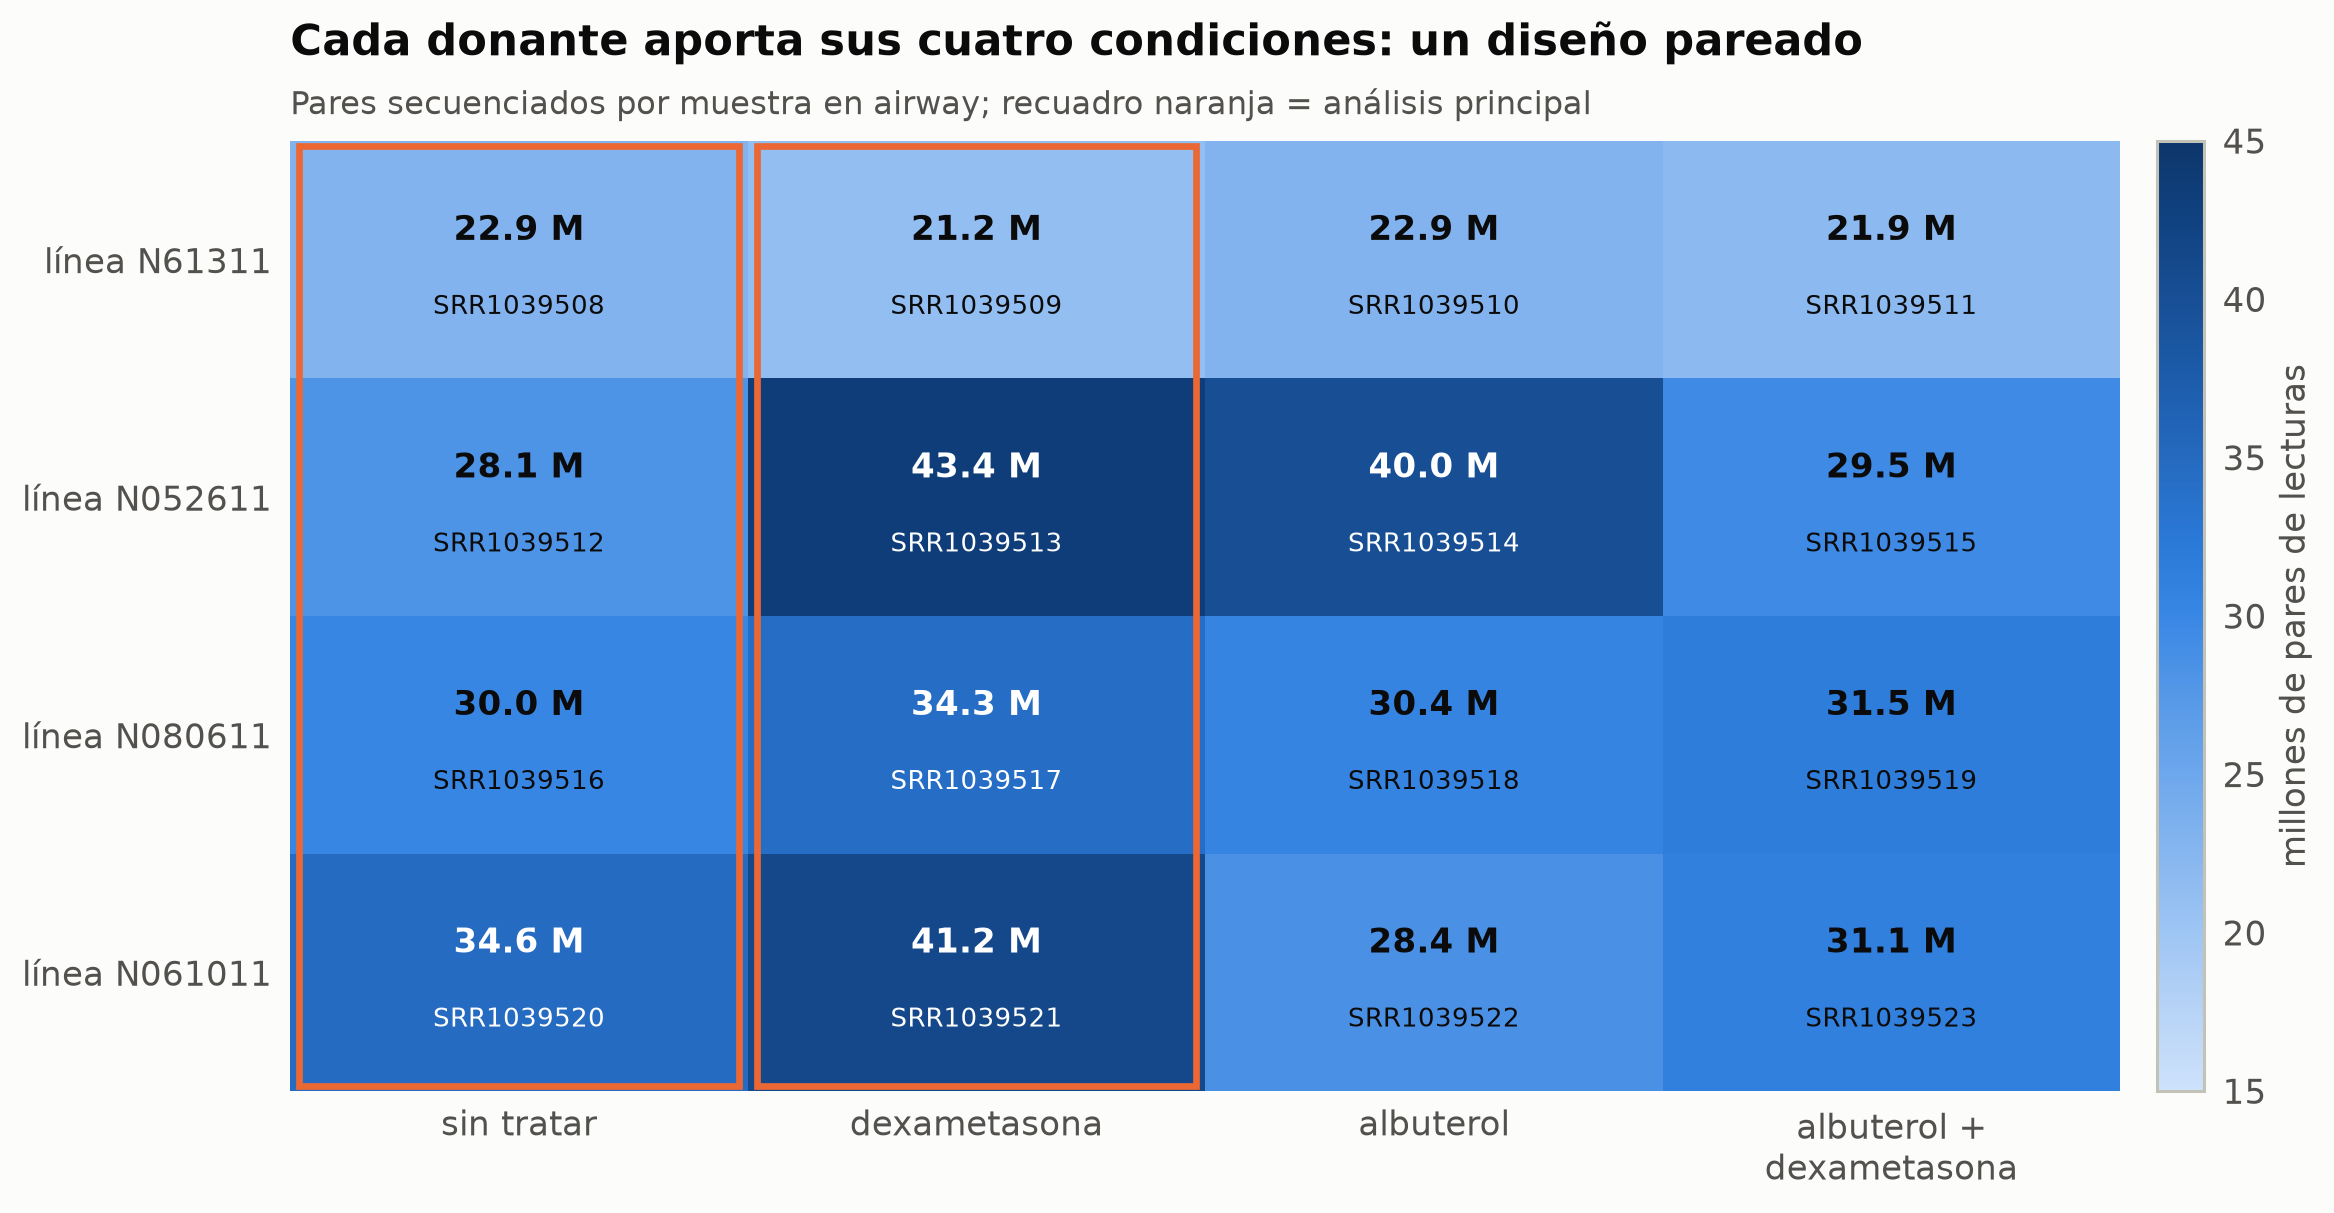

In [3]:
cells = ["N61311", "N052611", "N080611", "N061011"]
treats = ["Untreated", "Dexamethasone", "Albuterol", "Albuterol_Dexamethasone"]
treat_es = ["sin tratar", "dexametasona", "albuterol", "albuterol +\ndexametasona"]
M = samples.pivot(index="cell", columns="treatment", values="pairs_M").loc[cells, treats]

fig, ax = plt.subplots(figsize=(10.5, 5.4))
im = ax.imshow(M.values, cmap=ec.CMAP_SEQ, vmin=15, vmax=45, aspect="auto")
for i, c in enumerate(cells):
    for j, t in enumerate(treats):
        run = samples.query("cell == @c and treatment == @t").run.iloc[0]
        v = M.values[i, j]
        col = "white" if v > 32 else ec.INK
        ax.text(j, i - 0.12, f"{v:.1f} M", ha="center", va="center", fontsize=11, fontweight="bold", color=col)
        ax.text(j, i + 0.2, run, ha="center", va="center", fontsize=8.5, color=col)
for j in (0, 1):                                      # diseño principal del módulo: sin tratar vs dexametasona
    ax.add_patch(Rectangle((j - 0.48, -0.48), 0.96, 3.96, fill=False, lw=2.2, ec=ec.ORANGE))
ax.set_xticks(range(4), treat_es)
ax.set_yticks(range(4), [f"línea {c}" for c in cells])
ax.tick_params(length=0)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("millones de pares de lecturas")
ec.title(ax, "Cada donante aporta sus cuatro condiciones: un diseño pareado",
         "Pares secuenciados por muestra en airway; recuadro naranja = análisis principal")
plt.show()

> 🔎 **Qué observamos.** Dieciséis bibliotecas de 21 a 43 millones de pares, dentro del rango recomendado. Cada fila
> es un donante con sus cuatro tratamientos: si una línea celular expresa más un gen «de nacimiento», esa diferencia se
> cancela al comparar dentro de la fila. El recuadro marca las ocho muestras (sin tratar frente a dexametasona) que
> usaremos en el módulo; en la Lección 11.2 descubriremos por qué dejamos fuera las del albuterol.

### ¿Más réplicas o más profundidad?

Hagamos la cuenta que justifica la regla «réplicas antes que profundidad». Anticipando la Lección 11.2, el conteo de
un gen en una muestra tiene media $\mu$ y varianza $\mu + \phi\mu^2$: el primer término es el **ruido de muestreo**
(Poisson) y el segundo la **variación biológica** entre donantes, con dispersión $\phi$. El error estándar del
logaritmo del cambio entre dos grupos de $n$ réplicas es, aproximadamente,

$$
\operatorname{EE}\big(\log_2 \widehat{\mathrm{FC}}\big) \;\approx\; \frac{1}{\ln 2}\sqrt{\frac{2}{n}\left(\frac{1}{\mu}+\phi\right)},
\qquad \mu = p\cdot D .
$$

| Símbolo | Significado |
|---|---|
| $n$ | réplicas biológicas por grupo |
| $\mu$ | conteo esperado del gen en una muestra |
| $p$ | fracción de los fragmentos que produce el gen |
| $D$ | profundidad: fragmentos secuenciados por muestra |
| $\phi$ | dispersión biológica (varianza extra entre individuos; típicamente 0,01–0,1 en líneas celulares) |

Subir $D$ sólo reduce el término $1/\mu$; subir $n$ divide **los dos** términos. Cuando $\mu$ ya es grande, el error
queda dominado por $\phi$ y **ninguna profundidad lo baja**.

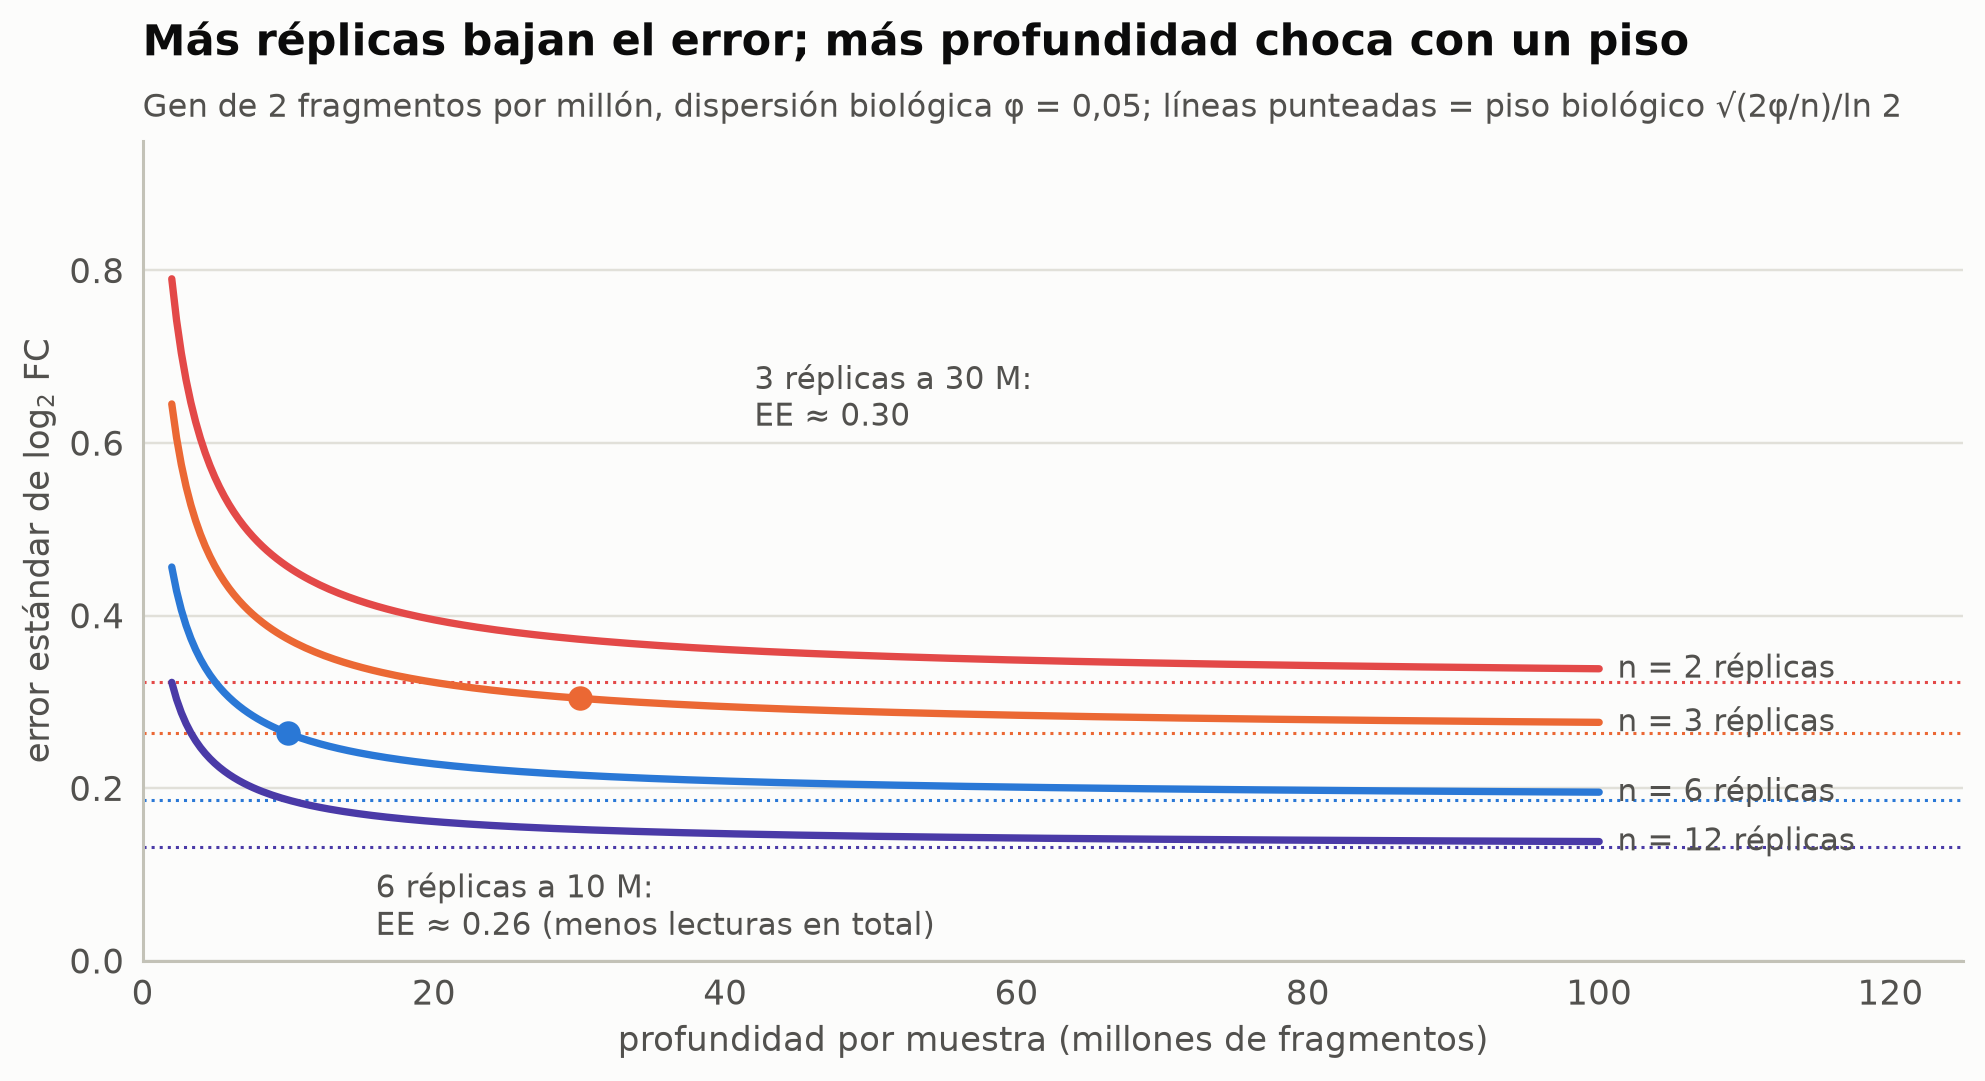

3 réplicas × 30 M = 90 M lecturas por grupo → EE = 0.304
6 réplicas × 10 M = 60 M lecturas por grupo → EE = 0.263


In [4]:
D = np.linspace(2e6, 100e6, 300)                      # profundidad (fragmentos por muestra)
p_gene, phi = 2e-6, 0.05                              # gen modesto: 2 fragmentos por millón; dispersión típica
def se_lfc(n, depth):
    mu = p_gene * depth
    return np.sqrt(2 / n * (1 / mu + phi)) / np.log(2)

fig, ax = plt.subplots(figsize=(9.2, 4.8))
for n, col in zip([2, 3, 6, 12], [ec.RED, ec.ORANGE, ec.BLUE, ec.VIOLET]):
    ax.plot(D / 1e6, se_lfc(n, D), color=col, lw=2.4)
    ax.axhline(np.sqrt(2 / n * phi) / np.log(2), color=col, lw=1, ls=":")
    ec.label_end(ax, 100, se_lfc(n, 100e6), f"n = {n} réplicas", color=ec.INK_2)
ax.plot([30], [se_lfc(3, 30e6)], "o", color=ec.ORANGE)
ax.annotate("3 réplicas a 30 M:\nEE ≈ %.2f" % se_lfc(3, 30e6), (30, se_lfc(3, 30e6)), xytext=(42, 0.62),
            arrowprops=dict(arrowstyle="->", color=ec.INK_2), fontsize=10, color=ec.INK_2)
ax.plot([10], [se_lfc(6, 10e6)], "o", color=ec.BLUE)
ax.annotate("6 réplicas a 10 M:\nEE ≈ %.2f (menos lecturas en total)" % se_lfc(6, 10e6), (10, se_lfc(6, 10e6)),
            xytext=(16, 0.03), arrowprops=dict(arrowstyle="->", color=ec.INK_2), fontsize=10, color=ec.INK_2)
ax.set_xlim(0, 125); ax.set_ylim(0, 0.95)
ax.set_xlabel("profundidad por muestra (millones de fragmentos)")
ax.set_ylabel("error estándar de log$_2$ FC")
ec.title(ax, "Más réplicas bajan el error; más profundidad choca con un piso",
         "Gen de 2 fragmentos por millón, dispersión biológica φ = 0,05; líneas punteadas = piso biológico √(2φ/n)/ln 2")
plt.show()
print(f"3 réplicas × 30 M = 90 M lecturas por grupo → EE = {se_lfc(3, 30e6):.3f}")
print(f"6 réplicas × 10 M = 60 M lecturas por grupo → EE = {se_lfc(6, 10e6):.3f}")

> 🔎 **Qué observamos.** Con tres réplicas, pasar de 30 a 100 millones de fragmentos apenas mueve el error: la curva ya
> está pegada a su piso biológico. Seis réplicas a 10 millones (un tercio menos de lecturas en total) dan un error
> **menor** que tres réplicas a 30 millones. Por eso los diseñadores de experimentos gastan el presupuesto en donantes,
> no en profundidad.

> ✅ **Compruebe su comprensión.** Un colega propone secuenciar **una** muestra tratada y **una** control a 200
> millones de lecturas cada una «para compensar». ¿Qué término de la fórmula no puede estimar con ese diseño?
> *(Respuesta: la dispersión $\phi$. Con una sola réplica por grupo no hay forma de medir cuánto varían los
> individuos, así que no hay prueba estadística honesta posible.)*

La figura siguiente resume el camino que seguiremos: las decisiones del laboratorio (gris), las dos rutas de
cuantificación (genoma en azul, transcriptoma en naranja) y la matriz de conteos que alimenta las Lecciones 11.2–11.4.

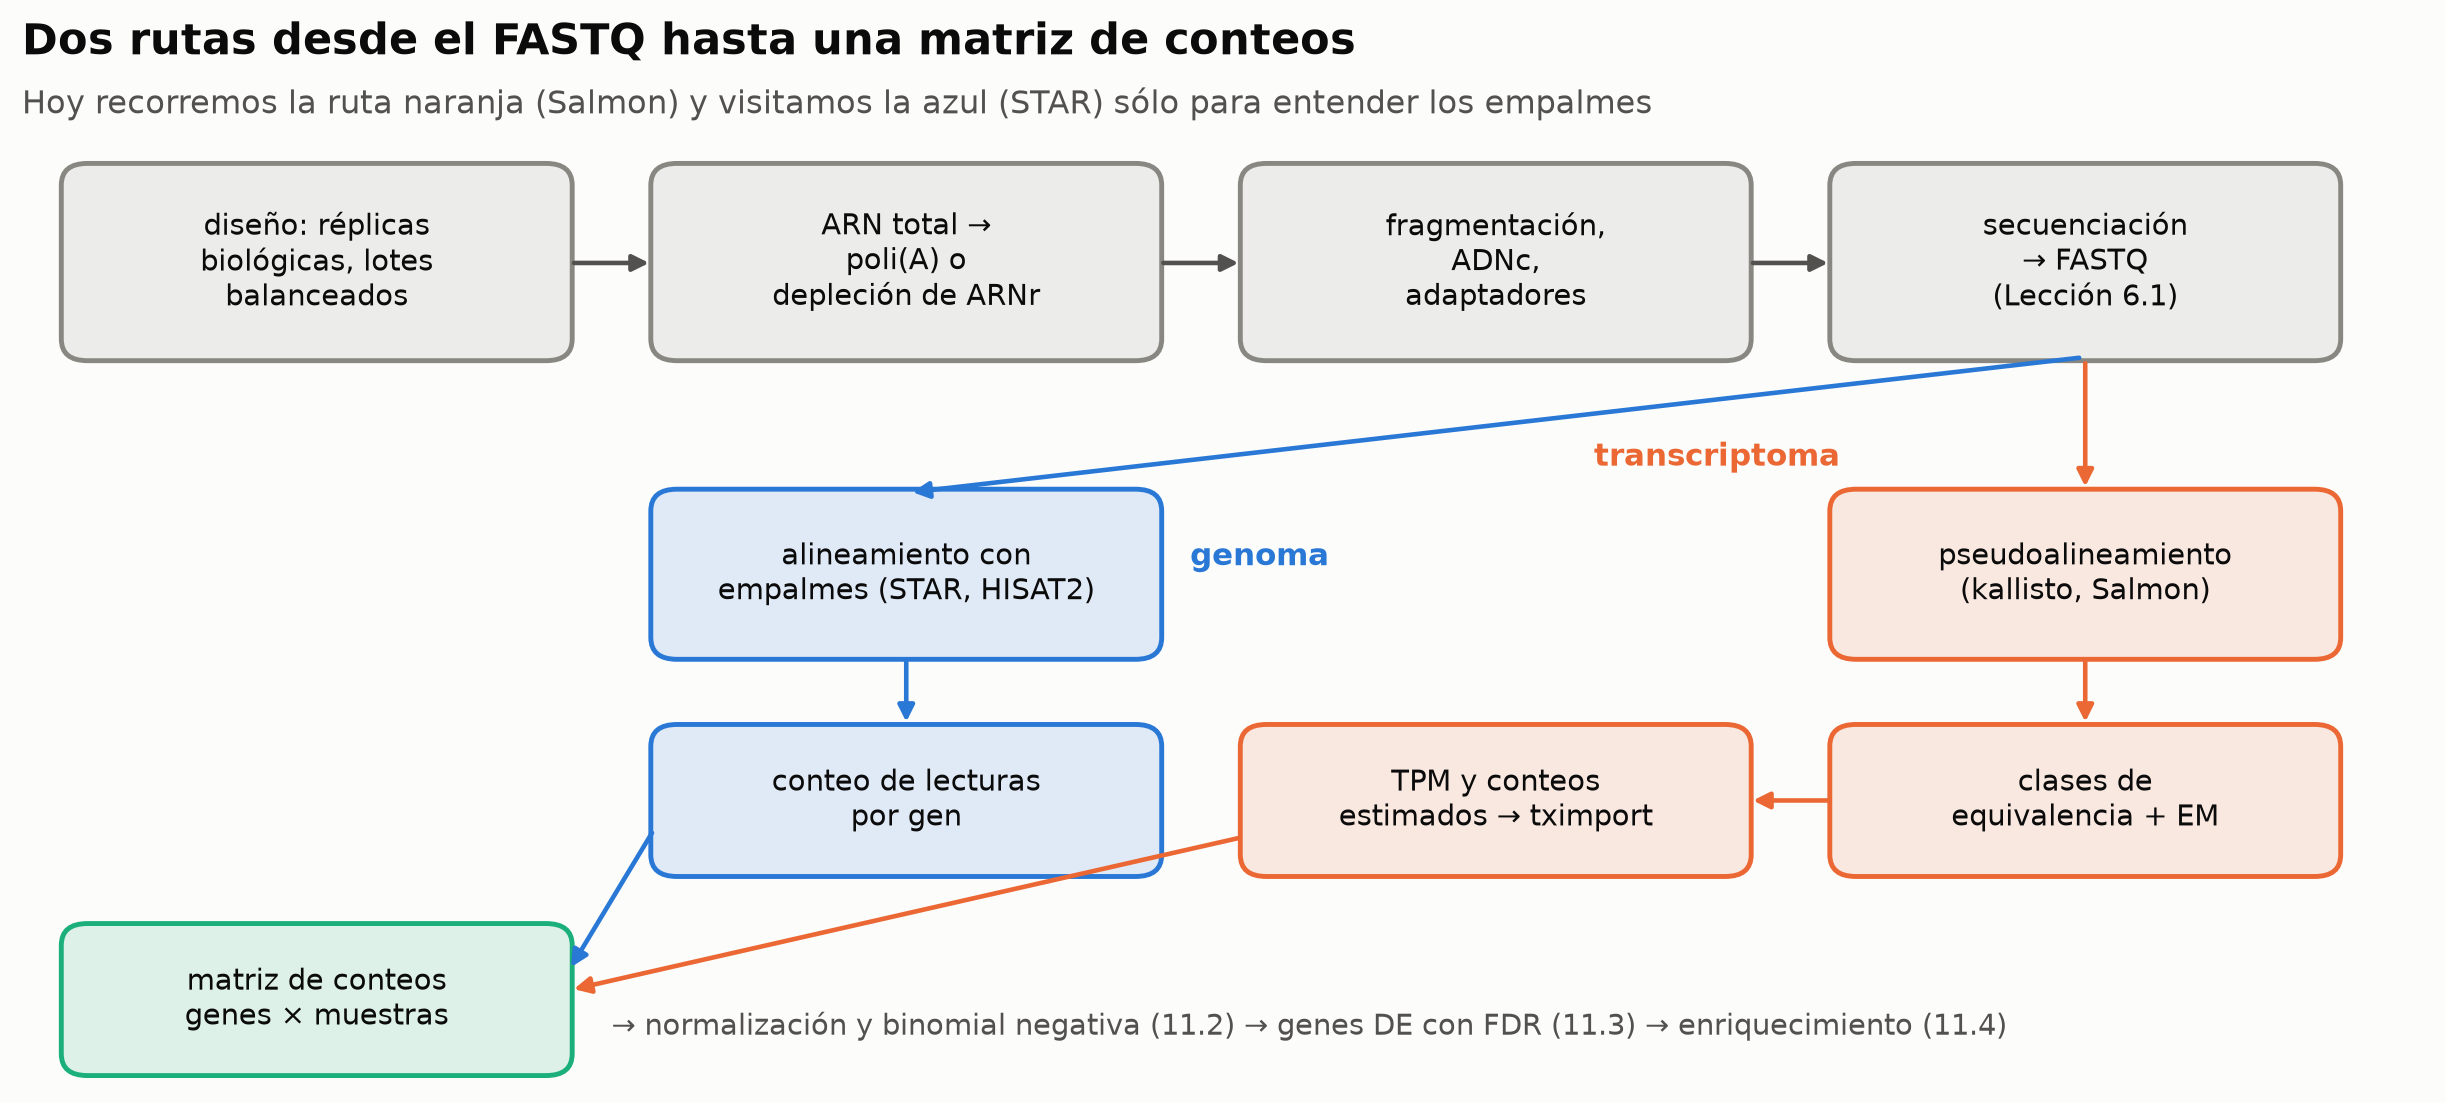

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.9))
ax.set_xlim(0, 11); ax.set_ylim(0, 5.2); ax.axis("off")
def box(x, y, w, h, txt, col, fc=None):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.12",
                                fc=fc or col + "22", ec=col, lw=1.6))
    ax.text(x + w / 2, y + h / 2, txt, ha="center", va="center", fontsize=9.5, color=ec.INK)
def arrow(x0, y0, x1, y1, col=ec.INK_2):
    ax.annotate("", (x1, y1), (x0, y0), arrowprops=dict(arrowstyle="-|>", color=col, lw=1.5))
G = ec.MUTED
top = [("diseño: réplicas\nbiológicas, lotes\nbalanceados", 0.2), ("ARN total →\npoli(A) o\ndepleción de ARNr", 2.9),
       ("fragmentación,\nADNc,\nadaptadores", 5.6), ("secuenciación\n→ FASTQ\n(Lección 6.1)", 8.3)]
for txt, x in top:
    box(x, 4.0, 2.3, 1.05, txt, G)
for x in (2.5, 5.2, 7.9):
    arrow(x, 4.52, x + 0.4, 4.52)
box(2.9, 2.35, 2.3, 0.9, "alineamiento con\nempalmes (STAR, HISAT2)", ec.BLUE)
box(2.9, 1.15, 2.3, 0.8, "conteo de lecturas\npor gen", ec.BLUE)
box(8.3, 2.35, 2.3, 0.9, "pseudoalineamiento\n(kallisto, Salmon)", ec.ORANGE)
box(8.3, 1.15, 2.3, 0.8, "clases de\nequivalencia + EM", ec.ORANGE)
box(5.6, 1.15, 2.3, 0.8, "TPM y conteos\nestimados → tximport", ec.ORANGE)
arrow(9.45, 4.0, 9.45, 3.25, ec.ORANGE); arrow(9.45, 4.0, 4.05, 3.25, ec.BLUE)
arrow(4.05, 2.35, 4.05, 1.95, ec.BLUE); arrow(9.45, 2.35, 9.45, 1.95, ec.ORANGE); arrow(8.3, 1.55, 7.9, 1.55, ec.ORANGE)
box(0.2, 0.05, 2.3, 0.8, "matriz de conteos\ngenes × muestras", ec.AQUA)
arrow(2.9, 1.4, 2.5, 0.6, ec.BLUE); arrow(5.6, 1.35, 2.5, 0.5, ec.ORANGE)
ax.text(5.35, 2.85, "genoma", color=ec.BLUE, fontsize=10, fontweight="bold")
ax.text(7.2, 3.4, "transcriptoma", color=ec.ORANGE, fontsize=10, fontweight="bold")
ax.text(2.7, 0.3, "→ normalización y binomial negativa (11.2) → genes DE con FDR (11.3) → enriquecimiento (11.4)",
        fontsize=9.5, color=ec.INK_2, va="center")
ec.title(ax, "Dos rutas desde el FASTQ hasta una matriz de conteos",
         "Hoy recorremos la ruta naranja (Salmon) y visitamos la azul (STAR) sólo para entender los empalmes")
plt.show()

## 3. Alinear lecturas que atraviesan intrones

En eucariotas el ARNm maduro es una concatenación de exones: los intrones, a veces de decenas de kilobases, ya fueron
eliminados. Una lectura de 63 bases tomada cerca de una unión exón-exón queda, **en el genoma**, partida en dos trozos
separados por el intrón. Los alineadores de ADN del Módulo 7 (BWA-MEM, minimap2 en modo corto) no admiten ese salto
largo: hacen falta alineadores **con empalmes** (*spliced aligners*).

Dobin *et al.* (2013) diseñaron **STAR** alrededor de una idea sencilla: buscar, desde el inicio de la lectura, el
**prefijo mapeable más largo** (*maximal mappable prefix*, MMP) que coincide exactamente con el genoma, usando un
**arreglo de sufijos** sin comprimir. Si la lectura cruza una unión, el prefijo se detiene justo en el borde del exón;
la búsqueda se reinicia con el resto de la lectura y encuentra el siguiente exón más adelante. Las semillas se
«cosen» después con un alineamiento local que permite un hueco largo (el intrón), favoreciendo los motivos canónicos
`GT…AG` en sus bordes. El precio es memoria (~30 GB para el genoma humano); la recompensa, una velocidad que los
autores cifraron en más de cincuenta veces la de los alineadores de su tiempo. HISAT2 (Kim *et al.*, 2019) toma el
camino opuesto: un índice FM sobre un **grafo** del genoma con variantes, jerárquico, que cabe en un portátil.

Programemos el MMP en un «genoma» de juguete de 900 pb con un gen de dos exones separados por un intrón canónico.

Formalmente, para una lectura $r$ y un genoma $G$, el MMP que empieza en la posición $i$ de la lectura es

$$
\mathrm{MMP}(i) = \max\big\{\,L \;:\; r[i\,..\,i+L) \text{ aparece en } G\,\big\},
$$

y STAR repite la búsqueda desde $i + \mathrm{MMP}(i)$ hasta cubrir la lectura.

| Símbolo | Significado |
|---|---|
| $r[i\,..\,i+L)$ | subcadena de la lectura que empieza en $i$ y mide $L$ bases |
| $\mathrm{MMP}(i)$ | longitud del prefijo mapeable más largo desde $i$ |
| arreglo de sufijos | posiciones de $G$ ordenadas alfabéticamente por el sufijo que empieza en ellas; permite búsqueda binaria |

In [6]:
def random_dna(n):
    return "".join(rng.choice(list("ACGT"), n))

# Genoma de juguete: [intergénico][exón 1][intrón GT...AG][exón 2][intergénico]
exon1, exon2 = random_dna(120), random_dna(130)
intron = "GT" + random_dna(396) + "AG"
genome = random_dna(100) + exon1 + intron + exon2 + random_dna(152)
e1_start = 100; e1_end = e1_start + len(exon1)
e2_start = e1_end + len(intron); e2_end = e2_start + len(exon2)
mrna = exon1 + exon2                                  # el ARNm maduro: el intrón fue eliminado
read = mrna[len(exon1) - 30: len(exon1) + 33]         # lectura de 63 nt: 30 del exón 1 + 33 del exón 2

# Arreglo de sufijos (versión didáctica: ordenar las posiciones por su sufijo)
SA = sorted(range(len(genome)), key=lambda i: genome[i:])
suffixes = [genome[i:] for i in SA]

def mmp(query):
    """Prefijo mapeable más largo de `query` en el genoma: (longitud, posiciones en el genoma)."""
    import bisect
    best, hits = 0, []
    lo, hi = 0, len(suffixes)
    for L in range(1, len(query) + 1):                 # alargamos el prefijo mientras siga apareciendo
        pref = query[:L]
        lo = bisect.bisect_left(suffixes, pref, lo, hi)
        hi = bisect.bisect_right(suffixes, pref + "~", lo, hi)
        if lo >= hi:
            break
        best, hits = L, sorted(SA[lo:hi])
    return best, hits

seeds, i = [], 0
while i < len(read):
    L, hits = mmp(read[i:])
    seeds.append((i, L, hits))
    print(f"semilla desde la base {i:2d} de la lectura: MMP = {L:2d} nt → genoma {hits}")
    i += L
(i1, L1, h1), (i2, L2, h2) = seeds[0], seeds[1]
overshoot = (h1[0] + L1) - e1_end
print(f"\nBorde real del exón 1 en {e1_end}; la primera semilla termina en {h1[0] + L1} "
      f"({'justo en el borde' if overshoot == 0 else f'{overshoot:+d} nt: la coincidencia continuó por azar en el intrón'})")

semilla desde la base  0 de la lectura: MMP = 31 nt → genoma [190]
semilla desde la base 31 de la lectura: MMP = 32 nt → genoma [621]

Borde real del exón 1 en 220; la primera semilla termina en 221 (+1 nt: la coincidencia continuó por azar en el intrón)


La primera semilla cubre el final del exón 1 y se detiene en el borde (o una o dos bases después: si la primera base
del intrón coincide por azar con la del exón 2, la coincidencia exacta «se estira»; STAR corrige ese corrimiento al
coser, desplazando la unión hasta encontrar el motivo `GT…AG`). La segunda semilla aparece cientos de bases más
adelante: **el hueco entre ambas es el intrón**. Cosamos las semillas y comprobemos el motivo canónico, deslizando la
unión si hace falta.

In [7]:
def stitch(read, seeds):
    """Une dos semillas: prueba todos los puntos de corte y prefiere el que deja un intrón GT...AG."""
    (i1, L1, h1), (i2, L2, h2) = seeds[0], seeds[1]
    g1, g2 = h1[0], h2[0] - i2                          # dónde caería la base 0 de la lectura en cada exón
    best = None
    for cut in range(1, len(read)):                     # la lectura es read[:cut] en el exón 1 y read[cut:] en el 2
        ok1 = genome[g1:g1 + cut] == read[:cut]
        ok2 = genome[g2 + cut:g2 + len(read)] == read[cut:]
        if ok1 and ok2:
            intr = genome[g1 + cut:g2 + cut]
            canon = intr.startswith("GT") and intr.endswith("AG")
            if best is None or canon:
                best = (cut, g1 + cut, g2 + cut, canon)
    return best

cut, istart, iend, canon = stitch(read, seeds)
print(f"Corte en la base {cut} de la lectura → intrón [{istart}, {iend}) de {iend - istart} pb; "
      f"motivo {genome[istart:istart+2]}…{genome[iend-2:iend]} {'(canónico ✔)' if canon else ''}")
print(f"Intrón verdadero: [{e1_end}, {e2_start}) → {'coincide ✔' if (istart, iend) == (e1_end, e2_start) else 'NO coincide'}")

Corte en la base 30 de la lectura → intrón [220, 620) de 400 pb; motivo GT…AG (canónico ✔)
Intrón verdadero: [220, 620) → coincide ✔


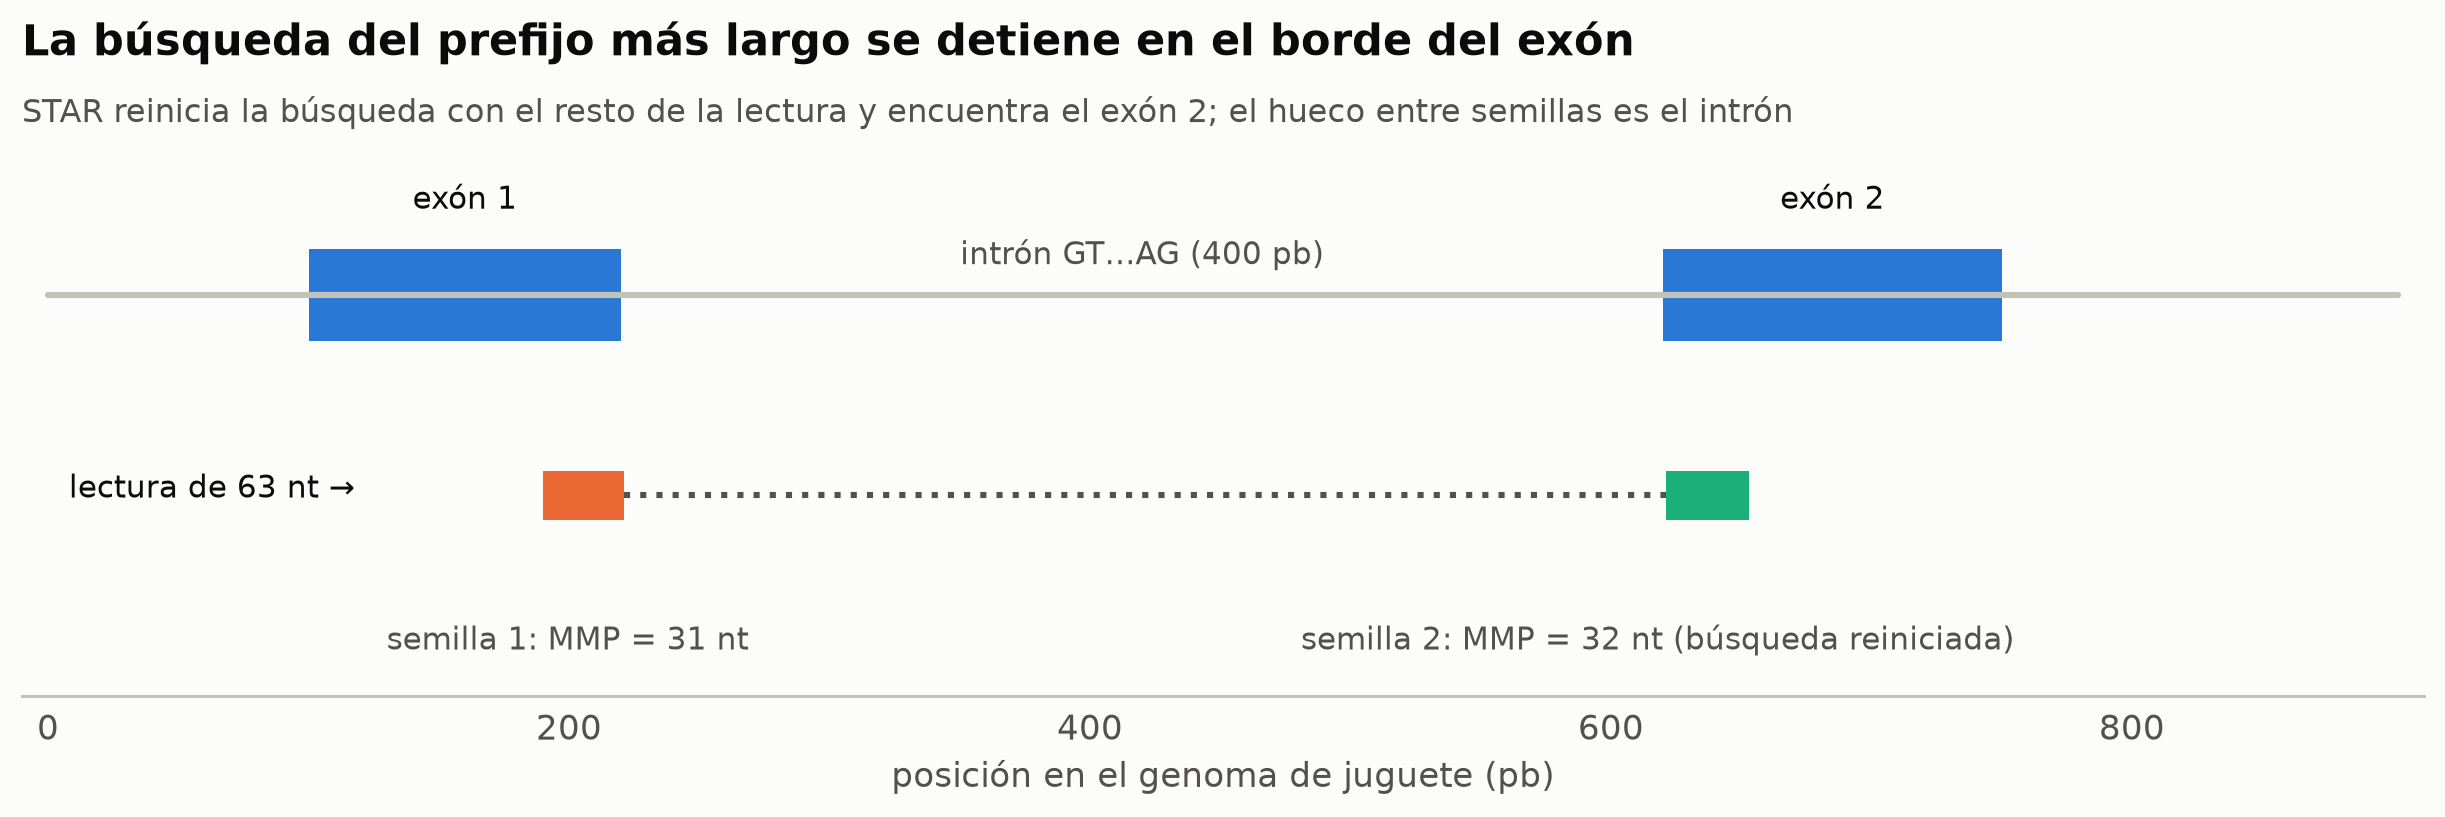

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot([0, len(genome)], [1, 1], color=ec.BASELINE, lw=2)
for (a, b), lab in [((e1_start, e1_end), "exón 1"), ((e2_start, e2_end), "exón 2")]:
    ax.add_patch(Rectangle((a, 0.85), b - a, 0.3, fc=ec.BLUE, ec="none"))
    ax.text((a + b) / 2, 1.28, lab, ha="center", fontsize=10, color=ec.INK)
ax.text((e1_end + e2_start) / 2, 1.1, f"intrón {genome[e1_end:e1_end+2]}…{genome[e2_start-2:e2_start]} "
        f"({e2_start - e1_end} pb)", ha="center", fontsize=10, color=ec.INK_2)
# la lectura en el genoma: dos bloques unidos por una línea punteada
y = 0.35
ax.add_patch(Rectangle((h1[0], y - 0.08), L1, 0.16, fc=ec.ORANGE, ec="none"))
ax.add_patch(Rectangle((h2[0], y - 0.08), L2, 0.16, fc=ec.AQUA, ec="none"))
ax.plot([h1[0] + L1, h2[0]], [y, y], ls=":", color=ec.INK_2)
ax.annotate(f"semilla 1: MMP = {L1} nt", (h1[0] + L1 / 2, y - 0.1), xytext=(h1[0] - 60, -0.15),
            fontsize=10, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax.annotate(f"semilla 2: MMP = {L2} nt (búsqueda reiniciada)", (h2[0] + L2 / 2, y - 0.1), xytext=(h2[0] - 140, -0.15),
            fontsize=10, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax.text(8, y + 0.02, "lectura de 63 nt →", fontsize=10, va="center", color=ec.INK)
ax.set_xlim(-10, len(genome) + 10); ax.set_ylim(-0.3, 1.5)
ax.set_yticks([]); ax.set_xlabel("posición en el genoma de juguete (pb)")
for s in ("left", "top", "right"):
    ax.spines[s].set_visible(False)
ec.title(ax, "La búsqueda del prefijo más largo se detiene en el borde del exón",
         "STAR reinicia la búsqueda con el resto de la lectura y encuentra el exón 2; el hueco entre semillas es el intrón")
plt.show()

> 🔎 **Qué observamos.** Sin conocer la anotación, dos búsquedas exactas bastaron para descubrir el intrón y sus
> bordes. Eso permite a STAR encontrar **uniones nuevas**. Después, en la ruta azul, las lecturas alineadas se
> **cuentan** por gen sumando las que caen en la unión de sus exones: sencillo y robusto, pero renuncia a distinguir
> isoformas y resuelve de forma arbitraria las lecturas de exones compartidos por genes solapados. Para las isoformas
> necesitamos otra cosa.

## 4. El problema de las isoformas

El **empalme alternativo** hace que un mismo gen produzca varios transcritos (**isoformas**) que comparten exones. El
gen de juguete del libro tiene cuatro exones y tres isoformas:

| Isoforma | Exones | Longitud $\ell_t$ | Qué la distingue |
|---|---|---|---|
| T1 | `E1`–`E2`–`E4` | 1500 pb | la unión `E1`–`E2` y la `E2`–`E4` |
| T2 | `E1`–`E4` | 1000 pb | omite el segundo exón: unión `E1`–`E4` |
| T3 | `E2`–`E3`–`E4` | 2000 pb | promotor alternativo; el exón `E3` sólo está en ella |

Una lectura que atraviesa la unión `E1`–`E2` sólo puede venir de T1; una que cae dentro de `E4` es compatible con las
tres. Cada lectura se etiqueta con **el conjunto de isoformas con las que es compatible**; a ese conjunto lo llamaremos
su **clase de equivalencia**. Dibujemos el gen y simulemos lecturas para ver qué clases aparecen.

In [9]:
# Coordenadas genómicas de los exones del gen de juguete (las de la figura del libro: 1 cm = 500 pb)
EXONS = {"E1": (0, 500), "E2": (1100, 1600), "E3": (2300, 3300), "E4": (4200, 4700)}
TX = {"T1": ["E1", "E2", "E4"], "T2": ["E1", "E4"], "T3": ["E2", "E3", "E4"]}
TX_NAMES = list(TX)
ell = np.array([sum(EXONS[e][1] - EXONS[e][0] for e in TX[t]) for t in TX_NAMES], float)
print("longitudes ℓ =", dict(zip(TX_NAMES, ell.astype(int))))

def exons_touched(t, start, length):
    """Exones (en orden) que toca un fragmento que empieza en `start` (coordenada del transcrito t)."""
    out, pos = [], 0
    for e in TX[t]:
        a, b = EXONS[e]; L = b - a
        if start < pos + L and start + length > pos:
            out.append(e)
        pos += L
    return out

def compatible(path):
    """Conjunto de isoformas en las que los exones tocados aparecen como bloque contiguo y en el mismo orden."""
    comp = []
    for t, ex in TX.items():
        k = len(path)
        if any(ex[i:i + k] == path for i in range(len(ex) - k + 1)):
            comp.append(t)
    return tuple(comp)

TAU_SIM = np.array([0.383, 0.440, 0.177])             # fracciones molares «verdaderas» para la simulación
MU_F, SD_F, N_SIM = 200, 25, 1200
def simulate_fragments(tau, n):
    leff = ell - MU_F + 1
    alpha = tau * leff / (tau * leff).sum()           # un transcrito largo ofrece más posiciones de inicio
    frags = []
    for _ in range(n):
        ti = rng.choice(3, p=alpha)
        L = int(np.clip(rng.normal(MU_F, SD_F), 100, 300))
        s = int(rng.integers(0, int(ell[ti]) - L + 1))
        comp = compatible(exons_touched(TX_NAMES[ti], s, L))
        frags.append((TX_NAMES[ti], s, L, "{" + ",".join(comp) + "}"))
    return pd.DataFrame(frags, columns=["origin", "start", "length", "eqclass"])

def class_members(label):
    """'{T1,T2}' → (0, 1): índices de las isoformas de una clase."""
    return tuple(TX_NAMES.index(t) for t in label.strip("{}").split(","))

sim = simulate_fragments(TAU_SIM, N_SIM)
eq_sim = sim.groupby("eqclass").size().rename("n_C")
print(f"{N_SIM} fragmentos simulados → {len(eq_sim)} clases de equivalencia:")
print(eq_sim.to_string())
print("\nOrigen verdadero de los fragmentos de cada clase (sólo lo sabe el simulador):")
print(pd.crosstab(sim.eqclass, sim.origin).to_string())

longitudes ℓ = {'T1': np.int64(1500), 'T2': np.int64(1000), 'T3': np.int64(2000)}
1200 fragmentos simulados → 6 clases de equivalencia:
eqclass
{T1,T2,T3}    299
{T1,T2}       243
{T1,T3}       149
{T1}          184
{T2}          104
{T3}          221

Origen verdadero de los fragmentos de cada clase (sólo lo sabe el simulador):


origin       T1   T2   T3
eqclass                  
{T1,T2,T3}  126  121   52
{T1,T2}     113  130    0
{T1,T3}     106    0   43
{T1}        184    0    0
{T2}          0  104    0
{T3}          0    0  221


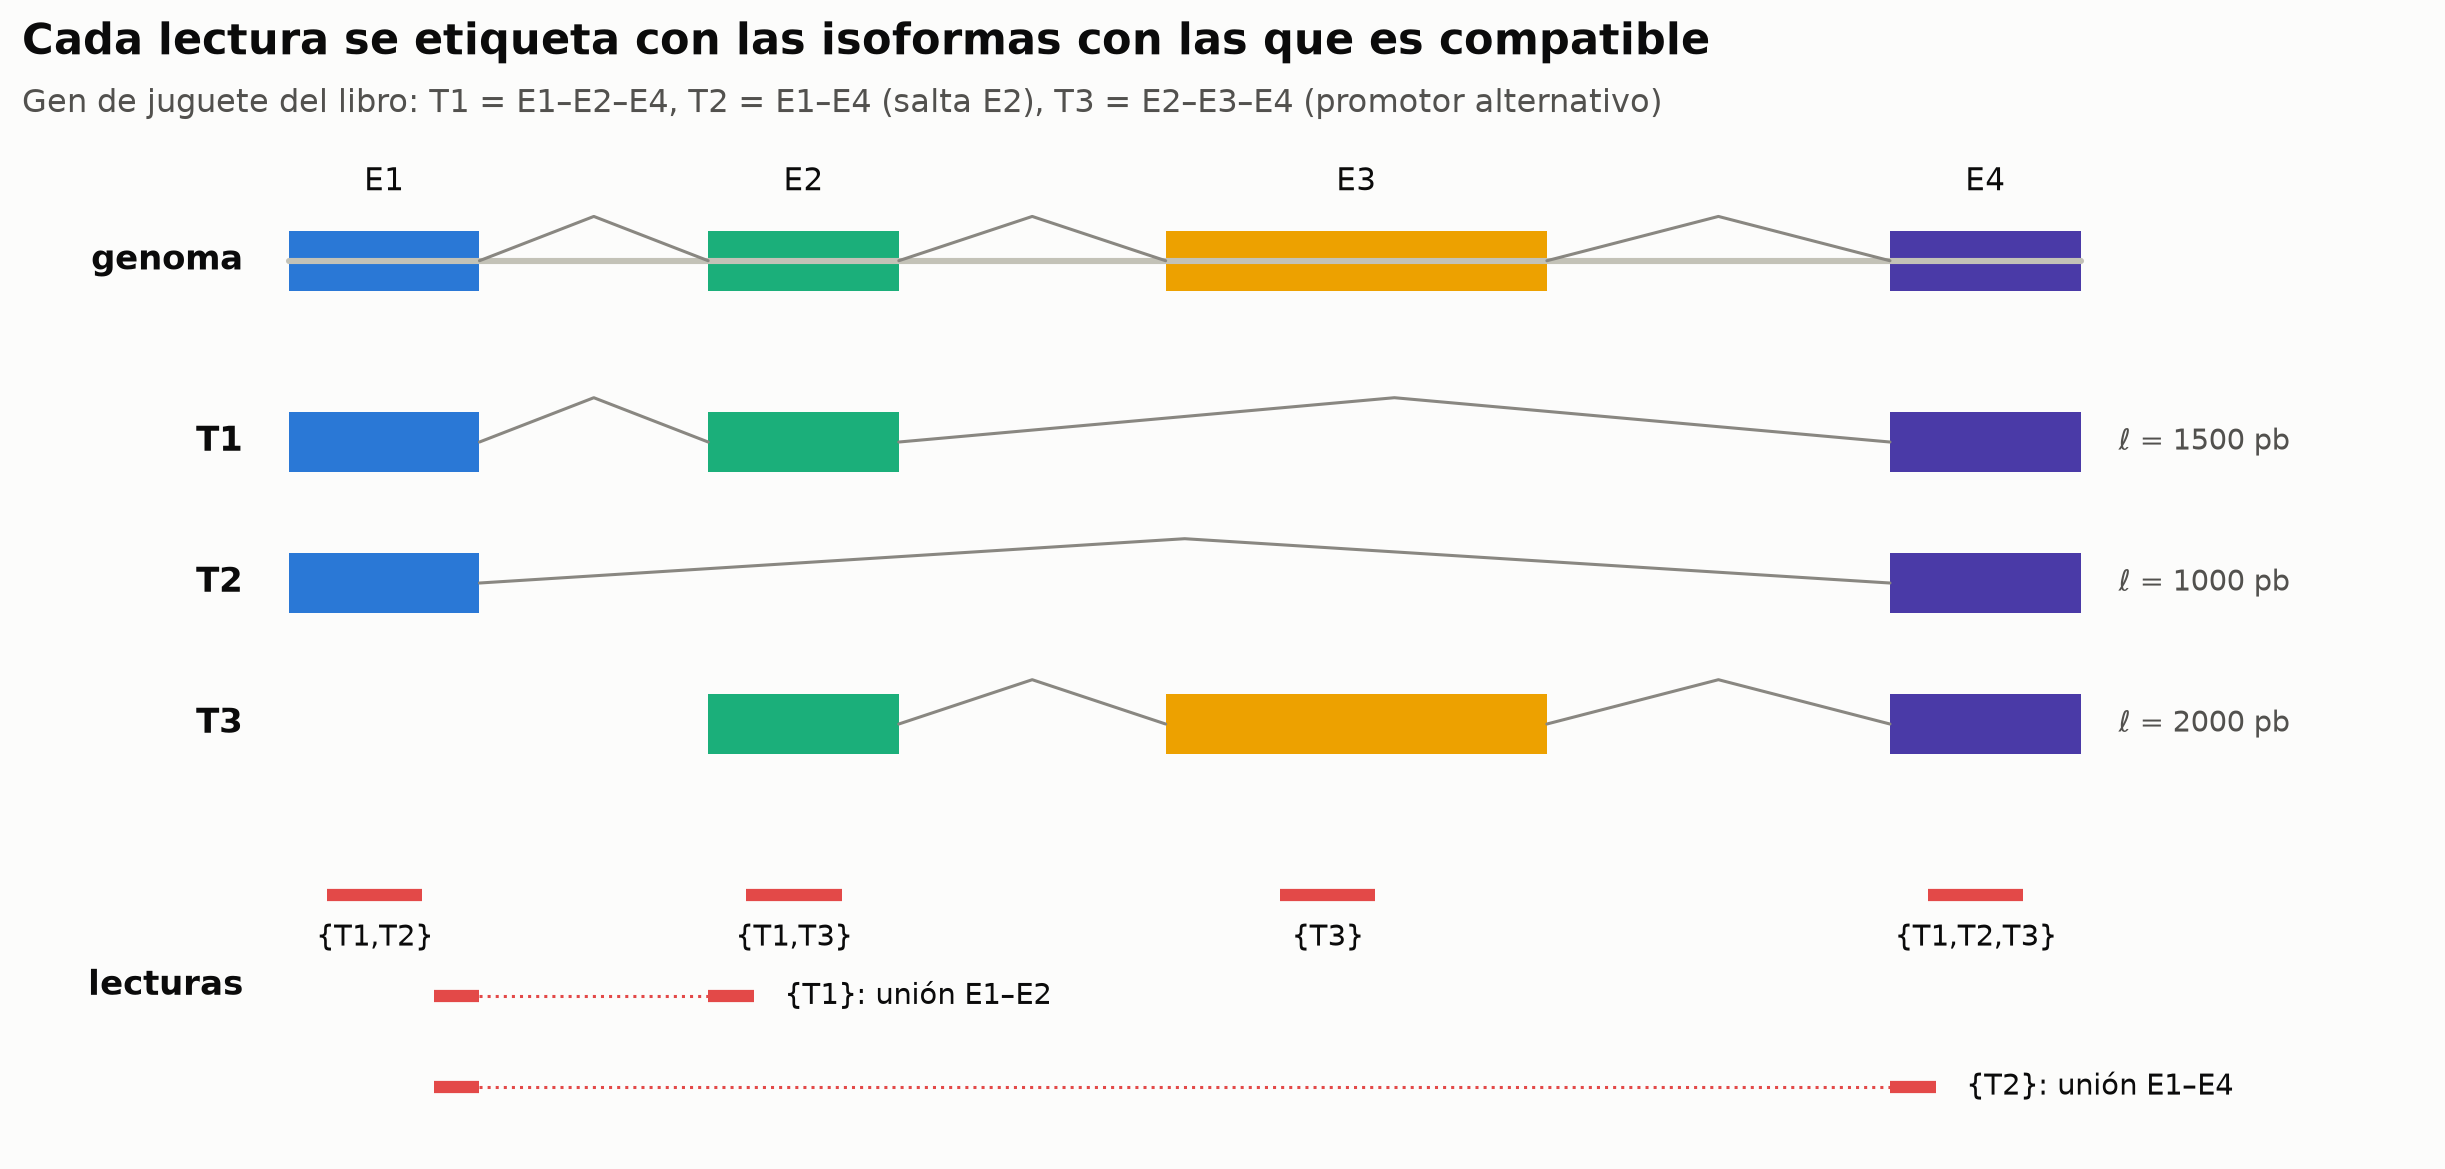

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.2))
ex_col = {"E1": ec.BLUE, "E2": ec.AQUA, "E3": ec.YELLOW, "E4": ec.VIOLET}
def draw_track(y, exs, label, note):
    ax.text(-120, y, label, ha="right", va="center", fontsize=11, fontweight="bold", color=ec.INK)
    ax.text(4800, y, note, ha="left", va="center", fontsize=9.5, color=ec.INK_2)
    for a, b in zip(exs[:-1], exs[1:]):                  # conectores de empalme (el intrón que se salta)
        x0, x1 = EXONS[a][1], EXONS[b][0]
        ax.plot([x0, (x0 + x1) / 2, x1], [y, y + 0.22, y], color=ec.MUTED, lw=1)
    for e in exs:
        a, b = EXONS[e]
        ax.add_patch(Rectangle((a, y - 0.15), b - a, 0.3, fc=ex_col[e], ec="none"))
ax.plot([0, 4700], [4.2, 4.2], color=ec.BASELINE, lw=2)
draw_track(4.2, list(EXONS), "genoma", "")
for e, (a, b) in EXONS.items():
    ax.text((a + b) / 2, 4.55, e, ha="center", fontsize=10, color=ec.INK)
for y, t in zip([3.3, 2.6, 1.9], TX_NAMES):
    draw_track(y, TX[t], t, f"ℓ = {int(ell[TX_NAMES.index(t)])} pb")
# lecturas de ejemplo (en coordenadas del genoma) etiquetadas con su clase
examples = [((100, 350), None, "{T1,T2}"), ((1200, 1450), None, "{T1,T3}"), ((2600, 2850), None, "{T3}"),
            ((4300, 4550), None, "{T1,T2,T3}"), ((380, 500), (1100, 1220), "{T1}: unión E1–E2"),
            ((380, 500), (4200, 4320), "{T2}: unión E1–E4")]
for k, (seg1, seg2, lab) in enumerate(examples):
    y = 1.05 if k < 4 else (0.55 if k == 4 else 0.1)
    ax.plot(seg1, [y, y], color=ec.RED, lw=4, solid_capstyle="butt")
    if seg2:
        ax.plot([seg1[1], seg2[0]], [y, y], color=ec.RED, lw=1, ls=":")
        ax.plot(seg2, [y, y], color=ec.RED, lw=4, solid_capstyle="butt")
        ax.text(seg2[1] + 80, y, lab, va="center", fontsize=9.5, color=ec.INK)
    else:
        ax.text(np.mean(seg1), y - 0.25, lab, ha="center", fontsize=9.5, color=ec.INK)
ax.text(-120, 0.6, "lecturas", ha="right", va="center", fontsize=11, fontweight="bold", color=ec.INK)
ax.set_xlim(-700, 5600); ax.set_ylim(-0.2, 4.8); ax.axis("off")
ec.title(ax, "Cada lectura se etiqueta con las isoformas con las que es compatible",
         "Gen de juguete del libro: T1 = E1–E2–E4, T2 = E1–E4 (salta E2), T3 = E2–E3–E4 (promotor alternativo)")
plt.show()

> 🔎 **Qué observamos.** Los 1200 fragmentos simulados caen en **seis clases** (las mismas seis que usa el libro), y
> sólo tres de ellas (`{T1}`, `{T2}`, `{T3}`) son inequívocas. La tabla cruzada muestra el problema: la clase
> `{T1, T2, T3}` mezcla fragmentos de las tres isoformas en proporciones que **no vemos**. Tenemos que repartirlos con
> un criterio, y para eso necesitamos un modelo de cómo se generan los fragmentos.

> ✅ **Compruebe su comprensión.** ¿Por qué no existe la clase `{T2, T3}`? *(Respuesta: T2 y T3 sólo comparten el
> exón `E4`, y cualquier lectura contenida en `E4` también es compatible con T1, que lo contiene. Para que una lectura
> fuera compatible con T2 y T3 pero no con T1 tendría que tocar una secuencia que T1 no tenga, y no la hay.)*

## 5. Un modelo generativo de fragmentos

Para repartir con criterio necesitamos contar **cómo nacen** los fragmentos. El modelo de RSEM (Li y Dewey, 2011), que
heredan kallisto y Salmon, es este: hay $T$ transcritos; el transcrito $t$ mide $\ell_t$ y está presente en una
**fracción molar** $\tau_t$ (fracción de *moléculas*, $\sum_t \tau_t = 1$). Un fragmento se genera eligiendo primero un
transcrito y después una posición de inicio uniforme a lo largo de él. Como un transcrito largo ofrece más posiciones
de inicio, la probabilidad de que un fragmento venga de $t$ no es $\tau_t$ sino $\alpha_t \propto \tau_t\tilde\ell_t$.

### Longitud efectiva

Si la longitud de los fragmentos sigue una distribución $P_F$, el número esperado de posiciones de inicio válidas en
el transcrito $t$ es (ecuación 11.1 del libro)

$$
\tilde\ell_t=\sum_{l=1}^{\ell_t} P_F(l)\,(\ell_t-l+1)\;\approx\;\ell_t-\mu_F+1 ,
$$

donde la aproximación vale cuando $\ell_t$ es mucho mayor que los fragmentos.

| Símbolo | Significado |
|---|---|
| $\ell_t$ | longitud del transcrito $t$ (en nucleótidos) |
| $\tilde\ell_t$ | longitud efectiva: número esperado de posiciones donde puede empezar un fragmento completo |
| $P_F(l)$ | probabilidad de que un fragmento mida $l$ nucleótidos (se estima de los pares de lecturas) |
| $\mu_F$ | longitud media de los fragmentos |

**Ejemplo a mano.** Un transcrito de 300 nt con fragmentos de 250 nt: $\tilde\ell \approx 300 - 250 + 1 = 51$. Tiene
**seis veces menos** posiciones de inicio de las que su longitud sugiere. En cambio, uno de 3000 nt tiene
$\tilde\ell \approx 2751$, el 92 % de su longitud. Comprobémoslo con la suma exacta.

In [11]:
from scipy import stats

def effective_length(ell_t, mu, sd):
    """Longitud efectiva exacta (ec. 11.1): suma sobre la distribución P_F (normal discretizada y truncada en ℓ)."""
    l = np.arange(1, int(ell_t) + 1)
    pf = stats.norm.pdf(np.arange(1, 1001), mu, sd); pf /= pf.sum()     # P_F(l) para l = 1..1000
    pf_l = pf[:len(l)] if len(l) <= 1000 else np.r_[pf, np.zeros(len(l) - 1000)]
    return float((pf_l * (ell_t - l + 1)).sum())

for L_t, mu in [(300, 250), (3000, 250), (1500, 200), (1000, 200), (2000, 200)]:
    exact = effective_length(L_t, mu, 25)
    print(f"ℓ = {L_t:5d}, μ_F = {mu}: exacta = {exact:7.1f}   aproximada ℓ-μ_F+1 = {L_t - mu + 1:5d}   "
          f"ℓ̃/ℓ = {exact / L_t:.2f}")

ℓ =   300, μ_F = 250: exacta =    51.2   aproximada ℓ-μ_F+1 =    51   ℓ̃/ℓ = 0.17
ℓ =  3000, μ_F = 250: exacta =  2751.0   aproximada ℓ-μ_F+1 =  2751   ℓ̃/ℓ = 0.92
ℓ =  1500, μ_F = 200: exacta =  1301.0   aproximada ℓ-μ_F+1 =  1301   ℓ̃/ℓ = 0.87
ℓ =  1000, μ_F = 200: exacta =   801.0   aproximada ℓ-μ_F+1 =   801   ℓ̃/ℓ = 0.80
ℓ =  2000, μ_F = 200: exacta =  1801.0   aproximada ℓ-μ_F+1 =  1801   ℓ̃/ℓ = 0.90


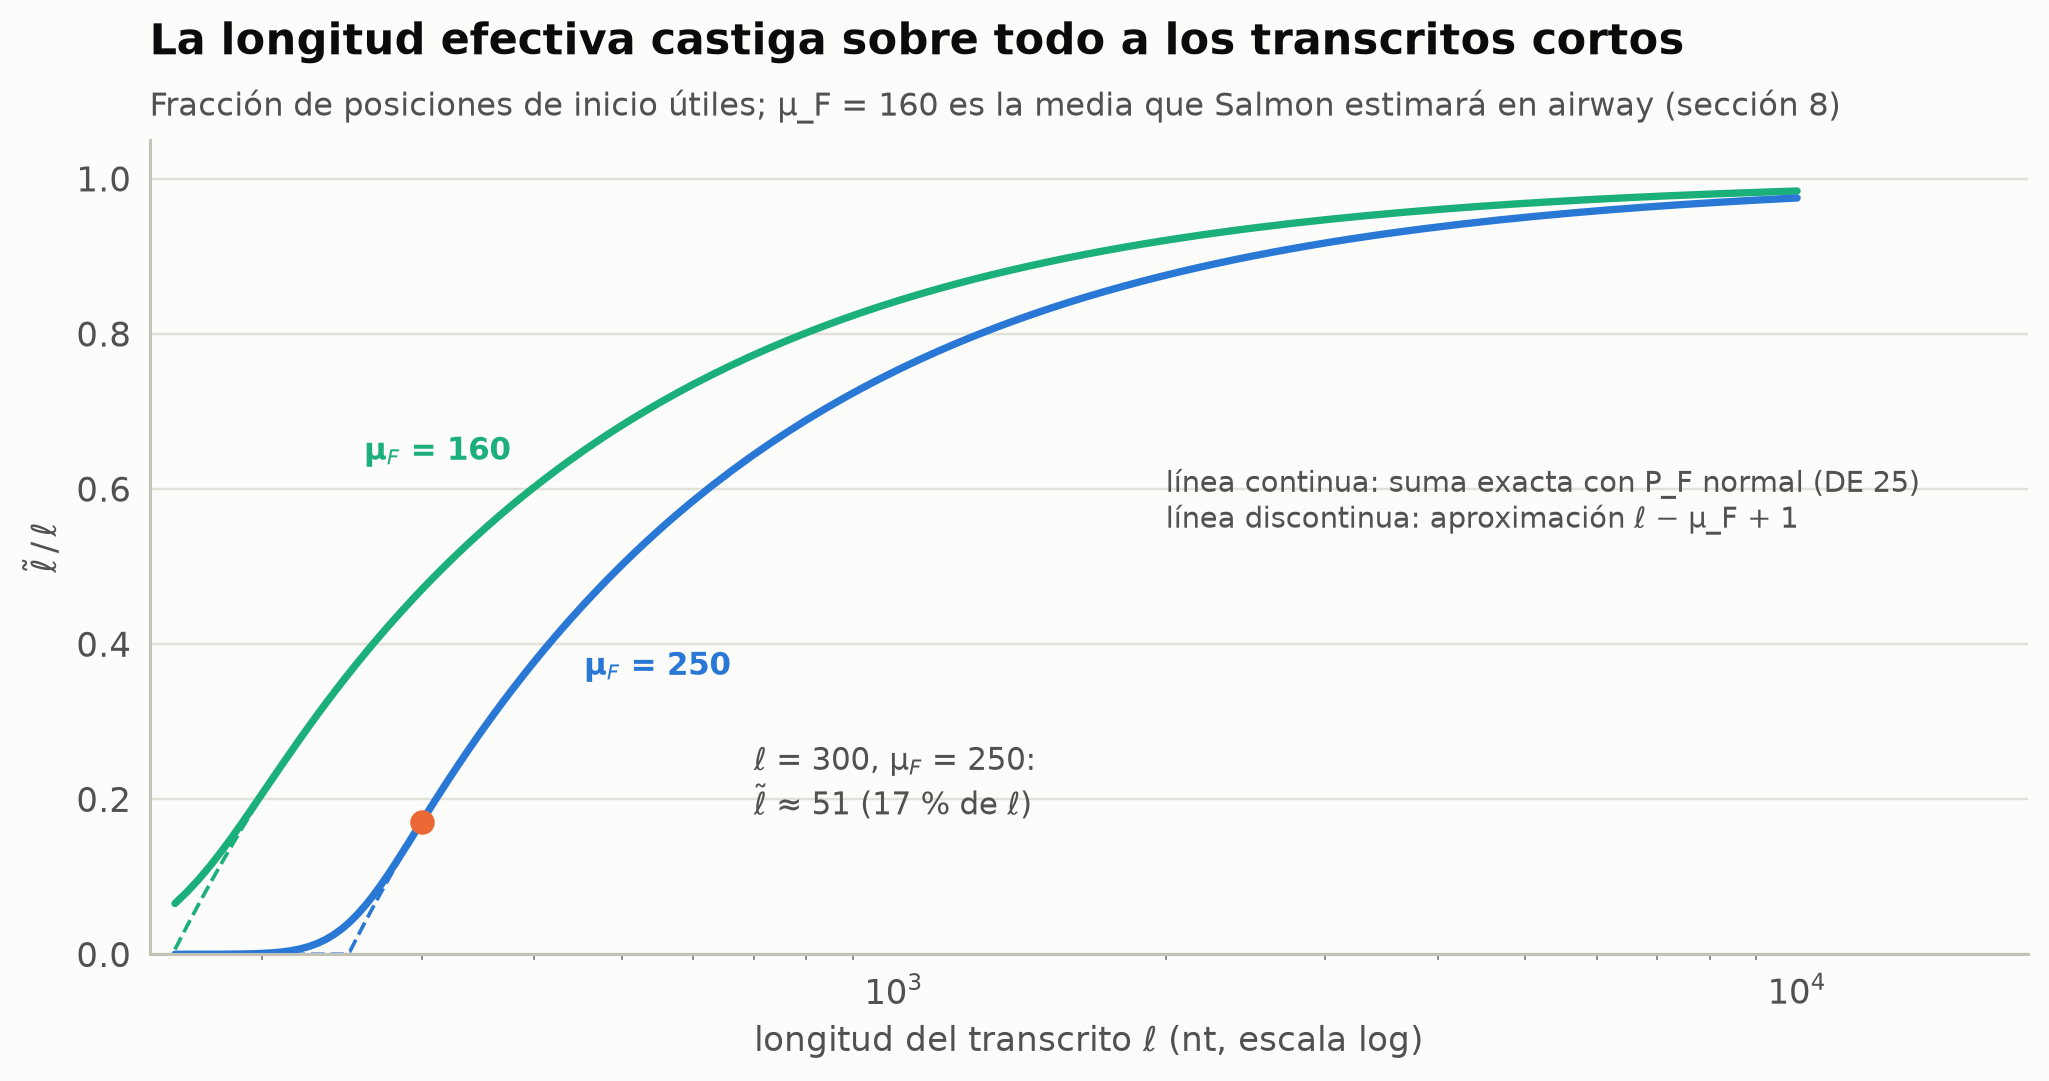

In [12]:
lens = np.unique(np.r_[np.arange(160, 600, 5), np.geomspace(600, 10000, 60).astype(int)])
fig, ax = plt.subplots(figsize=(9.2, 4.8))
for mu, col in [(160, ec.AQUA), (250, ec.BLUE)]:
    ex = np.array([effective_length(L, mu, 25) for L in lens])
    ax.plot(lens, ex / lens, color=col, lw=2.4)
    ax.plot(lens, np.clip(lens - mu + 1, 0, None) / lens, color=col, lw=1.2, ls="--")
    i4 = np.searchsorted(lens, 420)
    ax.annotate(f"μ$_F$ = {mu}", (lens[i4], ex[i4] / lens[i4]), xytext=(-62 if mu == 160 else 10, 4 if mu == 160 else -12),
                textcoords="offset points", fontsize=10, color=col, fontweight="bold")
ax.plot([300], [51 / 300], "o", color=ec.ORANGE, zorder=5)
ax.annotate("ℓ = 300, μ$_F$ = 250:\n$\\tilde\\ell$ ≈ 51 (17 % de ℓ)", (300, 51 / 300), xytext=(700, 0.18),
            arrowprops=dict(arrowstyle="->", color=ec.INK_2), fontsize=10, color=ec.INK_2)
ax.set_xscale("log"); ax.set_ylim(0, 1.05); ax.set_xlim(150, 18000)
ax.set_xlabel("longitud del transcrito ℓ (nt, escala log)")
ax.set_ylabel(r"$\tilde\ell\,/\,\ell$")
ax.text(2000, 0.55, "línea continua: suma exacta con P_F normal (DE 25)\nlínea discontinua: aproximación ℓ − μ_F + 1",
        fontsize=9.5, color=ec.INK_2)
ec.title(ax, "La longitud efectiva castiga sobre todo a los transcritos cortos",
         "Fracción de posiciones de inicio útiles; μ_F = 160 es la media que Salmon estimará en airway (sección 8)")
plt.show()

> 🔎 **Qué observamos.** Por encima de ~2 kb la corrección es casi irrelevante (ℓ̃/ℓ > 0,9); por debajo de 500 nt es
> enorme, y la aproximación lineal falla justo cuando $\ell_t$ se acerca a $\mu_F$ (la suma exacta nunca llega a cero
> porque siempre hay algún fragmento corto que cabe).

### Dos fracciones distintas: $\alpha$ y $\tau$

Con la longitud efectiva, la relación entre la fracción de **fragmentos** y la de **moléculas** es (ecuación 11.2)

$$
\alpha_t=\frac{\tau_t\,\tilde\ell_t}{\sum_u \tau_u\,\tilde\ell_u},\qquad
\tau_t=\frac{\alpha_t/\tilde\ell_t}{\sum_u \alpha_u/\tilde\ell_u}.
$$

| Símbolo | Significado |
|---|---|
| $\tau_t$ | fracción de **moléculas** de ARN que son del transcrito $t$ (la cantidad biológica de interés) |
| $\alpha_t$ | fracción de **fragmentos** secuenciados que proceden de $t$ (lo que las lecturas miden directamente) |
| $u$ | índice mudo que recorre todos los transcritos |

**Respuesta a la predicción de la sección 1.** Dos isoformas con el mismo número de moléculas, de 1 y 3 kb: sin
corrección, $\alpha_\text{larga} = 3/(1+3) = 0{,}75$. Con fragmentos de 200 nt, $\tilde\ell = (801,\,2801)$ y
$\alpha_\text{larga} = 2801/3602 = 0{,}78$. Tres de cada cuatro lecturas vienen de la larga aunque las moléculas
estén 50/50.

In [13]:
def alpha_from_tau(tau, leff):
    x = tau * leff
    return x / x.sum()

def tau_from_alpha(alpha, leff):
    x = alpha / leff
    return x / x.sum()

leff_2 = np.array([801.0, 2801.0])
a2 = alpha_from_tau(np.array([0.5, 0.5]), leff_2)
print(f"τ = (0,5; 0,5) con ℓ̃ = {leff_2} → α = ({a2[0]:.3f}; {a2[1]:.3f})")
print(f"ida y vuelta: τ recuperado = {tau_from_alpha(a2, leff_2)}")

τ = (0,5; 0,5) con ℓ̃ = [ 801. 2801.] → α = (0.222; 0.778)
ida y vuelta: τ recuperado = [0.5 0.5]


### La verosimilitud y el truco de las clases de equivalencia

Sea $y_{jt}\in\{0,1\}$ la indicadora de que el fragmento $j$ es compatible con $t$. Ignorando sesgos y errores de
secuenciación, la probabilidad de observar el fragmento $j$ es la de elegir un transcrito compatible y una de sus
$\tilde\ell_t$ posiciones (ecuación 11.3):

$$
\mathcal L(\alpha)=\prod_{j=1}^{N}\;\sum_{t=1}^{T} y_{jt}\,\frac{\alpha_t}{\tilde\ell_t}
\;=\;\prod_{C}\Big(\sum_{t\in C}\frac{\alpha_t}{\tilde\ell_t}\Big)^{n_C}.
$$

| Símbolo | Significado |
|---|---|
| $N$ | número total de fragmentos |
| $y_{jt}$ | 1 si el fragmento $j$ es compatible con el transcrito $t$; 0 si no |
| $C$ | clase de equivalencia: conjunto de transcritos con el que es compatible un grupo de fragmentos |
| $n_C$ | número de fragmentos de la clase $C$ |

La segunda igualdad es la observación que hace rápidos a los cuantificadores modernos: dos fragmentos compatibles con
el mismo conjunto aportan **el mismo factor**, así que basta guardar las clases y sus conteos. Nuestros 1200
fragmentos simulados se resumen en 6 números; en la sección 8 veremos que ~95 000 pares reales se resumen en unas
2000 clases, y en un transcriptoma completo, 30 millones de lecturas caben en unos cientos de miles de clases.

In [14]:
def loglik(alpha, classes, leff):
    """log L(α) = Σ_C n_C · log Σ_{t∈C} α_t/ℓ̃_t   (ecuación 11.3 en su forma por clases)."""
    return sum(n * np.log((alpha[list(C)] / leff[list(C)]).sum()) for C, n in classes)

# Las clases simuladas en el formato (tupla de índices, conteo)
classes_sim = [(class_members(C), int(n)) for C, n in eq_sim.items()]
leff_toy = ell - MU_F + 1                                      # (1301, 801, 1801)
alpha_true = alpha_from_tau(TAU_SIM, leff_toy)
print("clases:", classes_sim)
print(f"log L en la α verdadera       = {loglik(alpha_true, classes_sim, leff_toy):.2f}")
print(f"log L en la α uniforme        = {loglik(np.ones(3) / 3, classes_sim, leff_toy):.2f}")
print(f"log L fragmento a fragmento   = "
      f"{sum(np.log((alpha_true[list(class_members(C))] / leff_toy[list(class_members(C))]).sum()) for C in sim.eqclass):.2f}"
      "  (idéntico: las clases no pierden información)")

clases: [((0, 1, 2), 299), ((0, 1), 243), ((0, 2), 149), ((0,), 184), ((1,), 104), ((2,), 221)]
log L en la α verdadera       = -9255.58
log L en la α uniforme        = -9268.20
log L fragmento a fragmento   = -9255.58  (idéntico: las clases no pierden información)


## 6. El algoritmo EM

Maximizar $\mathcal L(\alpha)$ directamente es incómodo: el logaritmo de una suma no se separa. Pero si supiéramos de
qué transcrito vino cada fragmento (una variable **latente** $z_j$), la estimación sería trivial: $\hat\alpha_t$ sería
la fracción de fragmentos con $z_j = t$. El algoritmo *Expectation-Maximization* (Dempster, Laird y Rubin, 1977)
convierte esa intuición en un método: alterna entre **adivinar de forma probabilística** los $z_j$ (paso E) y
**reestimar** $\alpha$ como si esa adivinanza fuera cierta (paso M). Es exactamente el «repartir las tiras ambiguas y
volver a contar» de la sección 1.

**Teorema (EM para cuantificación de transcritos).** Partiendo de $\alpha^{(0)}$ (por ejemplo, uniforme), repita
hasta convergencia:

$$
\begin{aligned}
\text{Paso E:}\quad & \hat n_{Ct}^{(k)} = n_C\,\frac{\alpha_t^{(k)}/\tilde\ell_t}{\sum_{u\in C}\alpha_u^{(k)}/\tilde\ell_u}\qquad (t\in C),\\[4pt]
\text{Paso M:}\quad & \alpha_t^{(k+1)} = \frac{1}{N}\sum_{C\ni t}\hat n_{Ct}^{(k)}.
\end{aligned}
$$

Cada iteración no disminuye la log-verosimilitud: $\log\mathcal L(\alpha^{(k+1)})\ge\log\mathcal L(\alpha^{(k)})$.

| Símbolo | Significado |
|---|---|
| $\hat n_{Ct}^{(k)}$ | número esperado de fragmentos de la clase $C$ que proceden de $t$, dada la estimación actual |
| $\alpha^{(k)}$ | estimación de las fracciones de fragmentos en la iteración $k$ |
| $C\ni t$ | suma sobre todas las clases que contienen a $t$ |

Observe el paso E con atención, porque es donde más se equivocan las implementaciones ingenuas: **el reparto es
proporcional a $\alpha_t/\tilde\ell_t$, no a $\alpha_t$**. La probabilidad de un fragmento *concreto* dado el
transcrito es $1/\tilde\ell_t$: entre dos transcritos igual de representados en fragmentos, el corto concentra esos
fragmentos en menos posiciones y, por tanto, explica mejor cada uno.

### El ejemplo del libro: EM paso a paso con tres isoformas

Tomemos el gen de la sección 4 con fragmentos de $\mu_F = 200$: $\tilde\ell = (1301,\ 801,\ 1801)$. Se observaron
$N = 1200$ fragmentos repartidos así:

| Clase $C$ | {T1} | {T2} | {T3} | {T1,T2} | {T1,T3} | {T1,T2,T3} |
|---|---|---|---|---|---|---|
| $n_C$ | 120 | 30 | 200 | 250 | 150 | 450 |

**Iteración 1 a mano.** Con $\alpha^{(0)} = (\tfrac13, \tfrac13, \tfrac13)$ los pesos $\alpha_t/\tilde\ell_t$ son
proporcionales a $1/\tilde\ell_t = (7{,}69;\ 12{,}48;\ 5{,}55)\times10^{-4}$. La clase {T1,T2,T3} se reparte en
proporción a esos pesos:

$$
450\times\frac{7{,}69}{7{,}69+12{,}48+5{,}55} = 134{,}5,\qquad
450\times\frac{12{,}48}{25{,}72} = 218{,}4,\qquad
450\times\frac{5{,}55}{25{,}72} = 97{,}1 .
$$

T2, el más corto, recibe la mayor parte. Del mismo modo {T1,T2} se reparte en $(95{,}3;\ 154{,}7)$ y {T1,T3} en
$(87{,}1;\ 62{,}9)$. Sumando, T1 acumula $120 + 95{,}3 + 87{,}1 + 134{,}5 = 436{,}9$ fragmentos y el paso M da
$\alpha^{(1)}_1 = 436{,}9/1200 = 0{,}364$. Programémoslo y verifiquemos **todas** las cifras del libro.

In [15]:
BOOK_LEFF = np.array([1500.0, 1000.0, 2000.0]) - 200 + 1          # (1301, 801, 1801)
BOOK_CLASSES = [((0,), 120), ((1,), 30), ((2,), 200), ((0, 1), 250), ((0, 2), 150), ((0, 1, 2), 450)]

def e_step(alpha, classes, leff):
    """Paso E: n̂_Ct = n_C · (α_t/ℓ̃_t) / Σ_{u∈C} α_u/ℓ̃_u. Devuelve el reparto de cada clase."""
    out = []
    for C, n in classes:
        idx = list(C)
        w = alpha[idx] / leff[idx]                    # ¡dividir por la longitud efectiva!
        out.append(n * w / w.sum())
    return out

def em_isoforms(classes, leff, iters=200, tol=None):
    """EM de la cuantificación de isoformas. Devuelve la historia de α (una fila por iteración)."""
    T = len(leff); N = sum(n for _, n in classes)
    alpha = np.full(T, 1.0 / T)
    hist = [alpha.copy()]
    for _ in range(iters):
        expected = np.zeros(T)
        for (C, n), share in zip(classes, e_step(alpha, classes, leff)):
            expected[list(C)] += share                # acumular lo esperado por transcrito
        new = expected / N                            # paso M
        hist.append(new.copy())
        if tol is not None and np.abs(new - alpha).max() < tol:
            break
        alpha = new
    return np.array(hist)

# Iteración 1, clase por clase
alpha0 = np.ones(3) / 3
for (C, n), share in zip(BOOK_CLASSES, e_step(alpha0, BOOK_CLASSES, BOOK_LEFF)):
    print(f"clase {{{','.join('T%d' % (i + 1) for i in C)}}} (n_C = {n:3d}) → reparto {np.round(share, 1)}")

hist = em_isoforms(BOOK_CLASSES, BOOK_LEFF, iters=200)
N_BOOK = 1200
for k in range(4):
    print(f"α^({k}) = {np.round(hist[k], 3)}")
diff = np.abs(np.diff(hist, axis=0)).max(axis=1)
k_conv = int(np.argmax(diff < 1e-4)) + 1
alpha_hat = hist[-1]
tau_hat = tau_from_alpha(alpha_hat, BOOK_LEFF)
lls = np.array([loglik(a, BOOK_CLASSES, BOOK_LEFF) for a in hist])
print(f"\nel cambio máximo cae por debajo de 1e-4 en la iteración {k_conv}")
print(f"punto fijo α̂ = {np.round(alpha_hat, 3)}  →  fragmentos {np.round(alpha_hat * N_BOOK, 1)}")
print(f"fracciones molares τ̂ = {np.round(tau_hat, 3)}")
print(f"log L: {lls[0]:.2f} (iter 0) → {lls[1]:.2f} (iter 1) → {lls[-1]:.2f} (final)")

# Las cifras del libro, verificadas (si algo cambia, la celda falla)
share1 = e_step(alpha0, BOOK_CLASSES, BOOK_LEFF)
assert np.allclose(share1[5], [134.5, 218.4, 97.1], atol=0.05)
assert np.allclose(share1[3], [95.3, 154.7], atol=0.05) and np.allclose(share1[4], [87.1, 62.9], atol=0.05)
assert np.allclose(hist[1], [0.364, 0.336, 0.300], atol=5e-4)
assert np.allclose(hist[2], [0.383, 0.332, 0.286], atol=6e-4)
assert np.allclose(hist[3], [0.395, 0.326, 0.279], atol=5e-4)
assert k_conv == 20
assert np.allclose(alpha_hat, [0.426, 0.301, 0.273], atol=5e-4)
assert np.allclose(alpha_hat * N_BOOK, [511.3, 361.7, 327.0], atol=0.05)
assert np.allclose(tau_hat, [0.383, 0.440, 0.177], atol=5e-4)
assert round(lls[0], 1) == -9107.6 and round(lls[-1], 1) == -9099.0
print("✔ todas las cifras del ejemplo del libro reproducidas")

clase {T1} (n_C = 120) → reparto [120.]
clase {T2} (n_C =  30) → reparto [30.]
clase {T3} (n_C = 200) → reparto [200.]
clase {T1,T2} (n_C = 250) → reparto [ 95.3 154.7]
clase {T1,T3} (n_C = 150) → reparto [87.1 62.9]
clase {T1,T2,T3} (n_C = 450) → reparto [134.5 218.4  97.1]
α^(0) = [0.333 0.333 0.333]
α^(1) = [0.364 0.336 0.3  ]
α^(2) = [0.383 0.332 0.285]
α^(3) = [0.395 0.326 0.279]

el cambio máximo cae por debajo de 1e-4 en la iteración 20
punto fijo α̂ = [0.426 0.301 0.273]  →  fragmentos [511.3 361.7 327. ]
fracciones molares τ̂ = [0.383 0.44  0.177]
log L: -9107.57 (iter 0) → -9101.94 (iter 1) → -9098.99 (final)
✔ todas las cifras del ejemplo del libro reproducidas


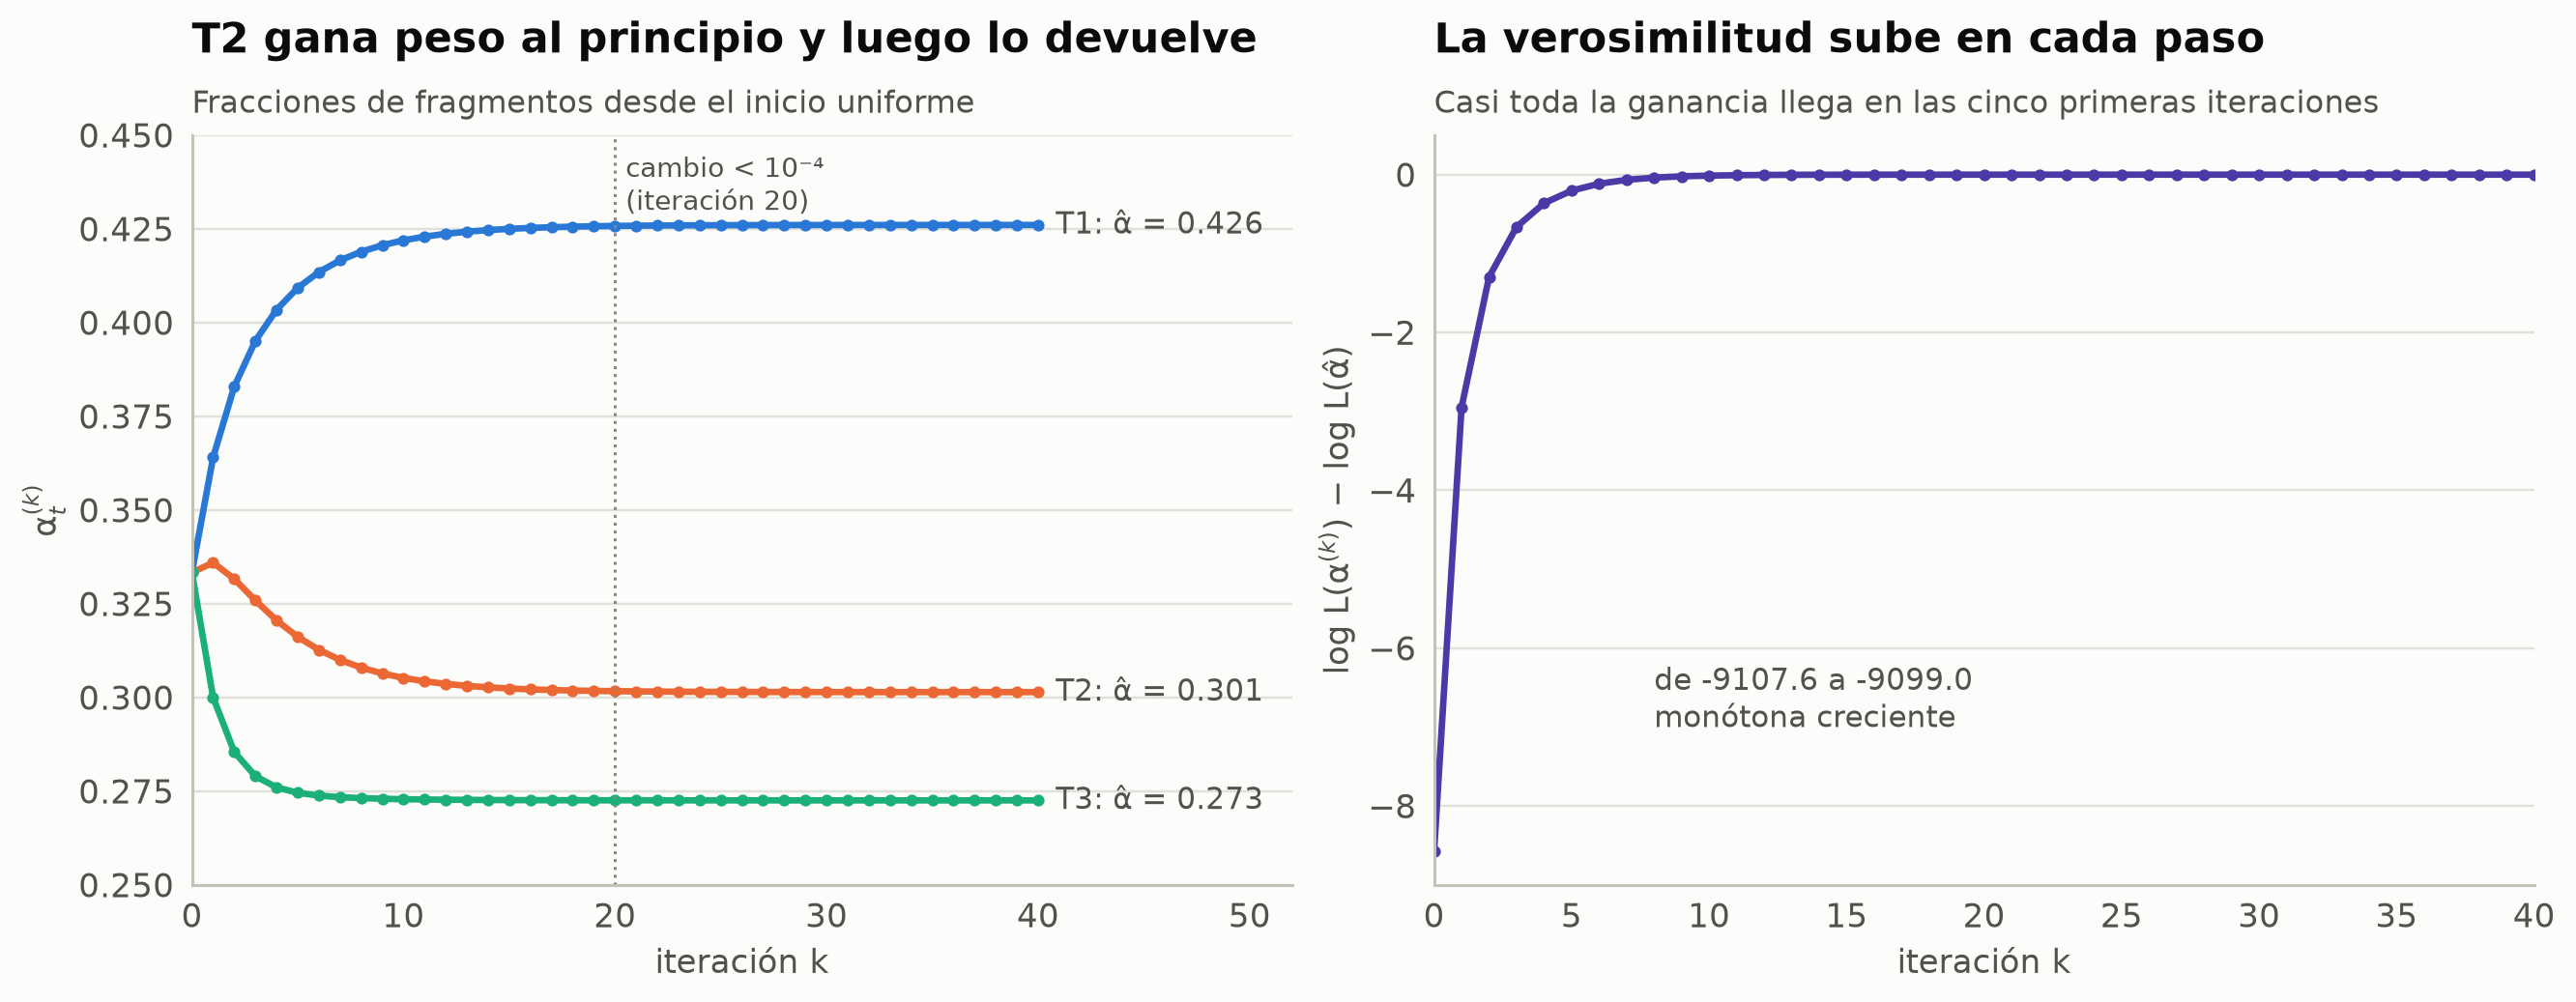

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
cols3 = [ec.BLUE, ec.ORANGE, ec.AQUA]
K = 41
ax = axes[0]
for t in range(3):
    ax.plot(range(K), hist[:K, t], color=cols3[t], lw=2.2, marker="o", ms=3)
    ec.label_end(ax, K - 1, hist[K - 1, t], f"T{t + 1}: α̂ = {alpha_hat[t]:.3f}")
ax.axvline(k_conv, color=ec.MUTED, ls=":", lw=1)
ax.text(k_conv + 0.5, 0.445, f"cambio < 10⁻⁴\n(iteración {k_conv})", fontsize=9, color=ec.INK_2, va="top")
ax.set_xlim(0, 52); ax.set_ylim(0.25, 0.45)
ax.set_xlabel("iteración k"); ax.set_ylabel("α$_t^{(k)}$")
ec.title(ax, "T2 gana peso al principio y luego lo devuelve", "Fracciones de fragmentos desde el inicio uniforme")
ax = axes[1]
ax.plot(range(K), lls[:K] - lls[-1], color=ec.VIOLET, lw=2.2, marker="o", ms=3)
ax.set_xlim(0, 40); ax.set_ylim(-9, 0.5)
ax.set_xlabel("iteración k"); ax.set_ylabel("log L(α$^{(k)}$) − log L(α̂)")
ax.annotate(f"de {lls[0]:.1f} a {lls[-1]:.1f}\nmonótona creciente", (1, lls[1] - lls[-1]), xytext=(8, -7),
            arrowprops=dict(arrowstyle="->", color=ec.INK_2), fontsize=10, color=ec.INK_2)
ec.title(ax, "La verosimilitud sube en cada paso", "Casi toda la ganancia llega en las cinco primeras iteraciones")
plt.show()

> 🔎 **Qué observamos.** En la primera iteración T2 gana peso porque es corto y absorbe más de lo que le corresponde de
> las lecturas ambiguas; las lecturas exclusivas de T1 (120) y las de la unión `E1`–`E4` (sólo 30, que dicen «T2 no
> es tan abundante») terminan corrigiendo ese exceso. La log-verosimilitud sube de −9107,6 a −9099,0 sin retroceder
> nunca, como garantiza el teorema.

**Fracciones molares.** Por la ecuación 11.2, $\hat\tau = (0{,}383;\ 0{,}440;\ 0{,}177)$. T2 recibe **menos
fragmentos** que T1 (361,7 frente a 511,3) pero tiene **más moléculas**, porque es más corto; T3 recibe un cuarto de
los fragmentos pero sólo un sexto de las moléculas, porque es el más largo. **Confundir $\alpha$ con $\tau$ es
confundir «cuántas lecturas» con «cuánto ARN».**

### Mírelo moverse

La animación muestra el paso E de cada iteración: cómo se reparte cada clase de equivalencia entre las isoformas
(barras) y hacia dónde se mueve $\alpha$ (derecha).

![El algoritmo EM reparte las clases ambiguas y vuelve a contar hasta que el reparto deja de cambiar](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-11-rnaseq/11.1_em_reparto.gif)

*El algoritmo EM reparte las clases ambiguas y vuelve a contar hasta que el reparto deja de cambiar*

In [17]:
class_labels = ["{T1}", "{T2}", "{T3}", "{T1,T2}", "{T1,T3}", "{T1,T2,T3}"]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.6), gridspec_kw=dict(width_ratios=[1.35, 1]))
def draw_em(k):
    axL.clear(); axR.clear()
    shares = e_step(hist[k], BOOK_CLASSES, BOOK_LEFF)
    for row, ((C, n), sh) in enumerate(zip(BOOK_CLASSES, shares)):
        left = 0
        for t, v in zip(C, sh):
            axL.barh(row, v, left=left, color=cols3[t], height=0.7)
            if v > 35:
                axL.text(left + v / 2, row, f"{v:.0f}", ha="center", va="center", color="white", fontsize=9)
            left += v
    axL.set_yticks(range(6), class_labels); axL.invert_yaxis()
    axL.set_xlim(0, 470); axL.set_xlabel("fragmentos de la clase asignados a cada isoforma")
    axL.grid(axis="y", visible=False)
    axL.legend(handles=[Rectangle((0, 0), 1, 1, color=cols3[t]) for t in range(3)], labels=["T1", "T2", "T3"],
               loc="upper right", frameon=False, ncol=3)
    ec.title(axL, f"Paso E de la iteración {k + 1}", r"Reparto proporcional a $\alpha_t/\tilde\ell_t$")
    for t in range(3):
        axR.plot(range(k + 1), hist[:k + 1, t], color=cols3[t], lw=2.2)
        axR.plot([k], [hist[k, t]], "o", color=cols3[t])
        ylab = hist[k, t] + (0.012 * (1 - t) if k < 3 else 0)       # separa las etiquetas mientras se solapan
        axR.text(26.5, ylab, f"T{t + 1} {hist[k, t]:.3f}", va="center", fontsize=10, color=ec.INK_2)
    axR.set_xlim(0, 33); axR.set_ylim(0.25, 0.45)
    axR.set_xlabel("iteración k"); axR.set_ylabel("α$^{(k)}$")
    ec.title(axR, "α se mueve hacia el punto fijo", f"log L = {lls[k]:.2f}")
draw_em(0)
ec.animate(fig, draw_em, frames=list(range(0, 26)), interval=450, name="11.1_em_reparto")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### El paisaje de la verosimilitud (interactivo)

Como $\alpha_1 + \alpha_2 + \alpha_3 = 1$, todas las posibles soluciones viven en un **triángulo** (un símplex). En el
gráfico ternario siguiente cada punto es una $\alpha$ posible, coloreada por su log-verosimilitud relativa al máximo;
la línea es el camino que siguió EM. Pase el cursor: verá $\alpha$, las fracciones molares $\tau$ correspondientes y
cuántas unidades de log-verosimilitud faltan para el máximo.

> 🤔 **Antes de mirar, prediga.** ¿El camino de EM será una línea recta hacia el máximo o hará una curva? ¿Dará pasos
> grandes o pequeños cerca del final?

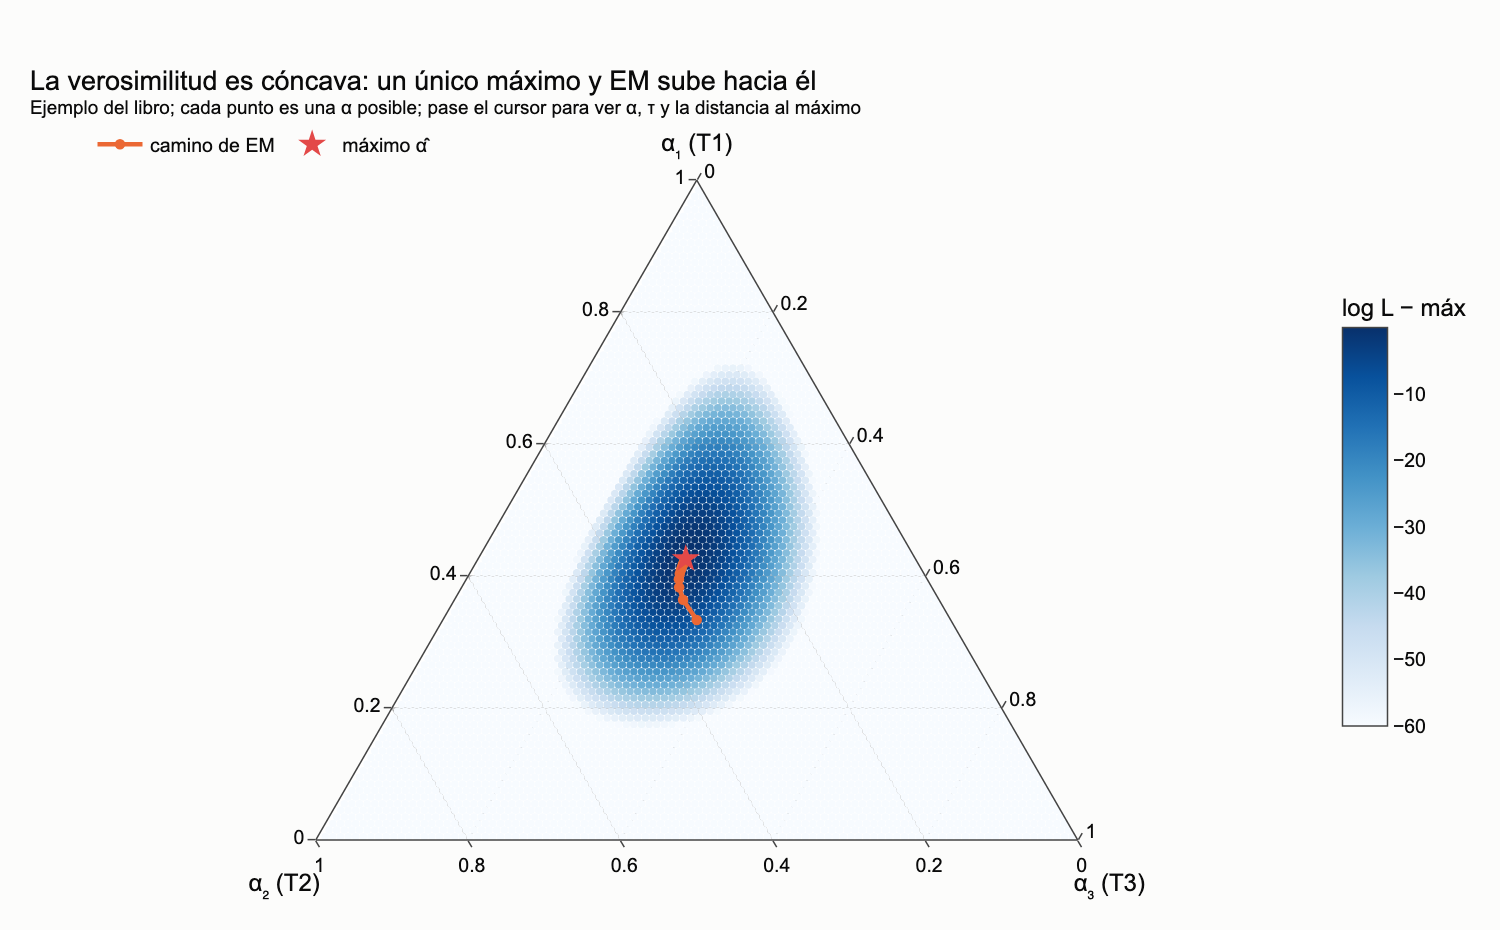

In [18]:
grid = [(a, b, 1 - a - b) for a in np.arange(0.005, 1, 0.01) for b in np.arange(0.005, 1, 0.01) if a + b < 0.995]
grid = np.array(grid)
ll_grid = np.array([loglik(g, BOOK_CLASSES, BOOK_LEFF) for g in grid]) - lls[-1]
tau_grid = np.array([tau_from_alpha(g, BOOK_LEFF) for g in grid])
hover = [f"α = ({g[0]:.2f}; {g[1]:.2f}; {g[2]:.2f})<br>τ = ({t[0]:.2f}; {t[1]:.2f}; {t[2]:.2f})"
         f"<br>log L − log L(α̂) = {l:.1f}" for g, t, l in zip(grid, tau_grid, ll_grid)]
path = hist[:30]
fig = go.Figure()
fig.add_trace(go.Scatterternary(a=grid[:, 0], b=grid[:, 1], c=grid[:, 2], mode="markers",
    marker=dict(size=5, color=np.clip(ll_grid, -60, 0), colorscale="Blues", showscale=True,
                colorbar=dict(title="log L − máx", len=0.7)),
    text=hover, hoverinfo="text", name="α posibles", showlegend=False))
fig.add_trace(go.Scatterternary(a=path[:, 0], b=path[:, 1], c=path[:, 2], mode="lines+markers",
    line=dict(color=ec.ORANGE, width=3), marker=dict(size=7, color=ec.ORANGE),
    text=[f"iteración {k}<br>α = ({a[0]:.3f}; {a[1]:.3f}; {a[2]:.3f})<br>log L = {lls[k]:.2f}"
          for k, a in enumerate(path)], hoverinfo="text", name="camino de EM"))
fig.add_trace(go.Scatterternary(a=[alpha_hat[0]], b=[alpha_hat[1]], c=[alpha_hat[2]], mode="markers",
    marker=dict(size=14, symbol="star", color=ec.RED), name="máximo α̂",
    text=[f"α̂ = ({alpha_hat[0]:.3f}; {alpha_hat[1]:.3f}; {alpha_hat[2]:.3f})<br>τ̂ = "
          f"({tau_hat[0]:.3f}; {tau_hat[1]:.3f}; {tau_hat[2]:.3f})"], hoverinfo="text"))
fig.update_layout(
    title="La verosimilitud es cóncava: un único máximo y EM sube hacia él<br><sup>Ejemplo del libro; cada punto es "
          "una α posible; pase el cursor para ver α, τ y la distancia al máximo</sup>",
    ternary=dict(aaxis=dict(title="α₁ (T1)"), baxis=dict(title="α₂ (T2)"), caxis=dict(title="α₃ (T3)")),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=620, margin=dict(t=120, l=60, r=60, b=60))
fig.show()

> 🔎 **Qué observamos.** La región de alta verosimilitud es una elipse alargada: la dirección en que T1 y T3 se
> intercambian peso está mal determinada (comparten muchas lecturas), mientras que moverse hacia T2 se castiga rápido.
> EM da pasos grandes al principio y cada vez más cortos al final; ése es su punto débil: **converge con lentitud
> cuando dos isoformas son casi indistinguibles**, y por eso Salmon ofrece aceleraciones (SQUAREM) y la variante
> bayesiana variacional.

### ¿Por qué la verosimilitud no baja nunca?

Llamemos **responsabilidades** a las probabilidades que calcula el paso E,
$\gamma_{jt} = \Pr(z_j = t \mid j, \alpha^{(k)})$. Para cualquier $\alpha$, la **desigualdad de Jensen** aplicada al
logaritmo (una función cóncava: el logaritmo de un promedio es mayor o igual que el promedio de los logaritmos) da
(ecuación 11.6)

$$
\log\sum_t y_{jt}\frac{\alpha_t}{\tilde\ell_t}
=\log\sum_t \gamma_{jt}\,\frac{y_{jt}\,\alpha_t/\tilde\ell_t}{\gamma_{jt}}
\;\ge\;\sum_t\gamma_{jt}\log\frac{y_{jt}\,\alpha_t/\tilde\ell_t}{\gamma_{jt}},
$$

con igualdad cuando $\alpha = \alpha^{(k)}$.

| Símbolo | Significado |
|---|---|
| $z_j$ | transcrito de origen (desconocido) del fragmento $j$ |
| $\gamma_{jt}$ | responsabilidad: probabilidad de que $j$ venga de $t$ según la estimación actual |
| $Q(\alpha\mid\alpha^{(k)})$ | lado derecho sumado sobre $j$: una cota inferior de $\log\mathcal L(\alpha)$ |

El lado derecho, sumado sobre $j$, es una **cota inferior** de $\log\mathcal L(\alpha)$ que **toca** la curva en
$\alpha^{(k)}$. El paso M maximiza esa cota (un problema multinomial con solución cerrada); como la cota está por
debajo de la curva, la verosimilitud en el nuevo punto es al menos tan alta como en el anterior. Para verlo en una
dimensión, tomemos sólo T1 y T2 con las clases {T1} = 120, {T2} = 30 y {T1,T2} = 250: la única incógnita es
$a = \alpha_1$ (y $\alpha_2 = 1 - a$). Empezamos lejos, en $a = 0{,}10$.

![Cada paso de EM maximiza una cota inferior que toca la log-verosimilitud en el punto actual](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-11-rnaseq/11.1_em_cota.gif)

*Cada paso de EM maximiza una cota inferior que toca la log-verosimilitud en el punto actual*

In [19]:
L2 = np.array([1301.0, 801.0]); n1, n2, n12 = 120, 30, 250
def ll_1d(a):
    return n1 * np.log(a / L2[0]) + n2 * np.log((1 - a) / L2[1]) + n12 * np.log(a / L2[0] + (1 - a) / L2[1])
def bound_1d(a, ak):
    w = np.array([ak / L2[0], (1 - ak) / L2[1]]); g = w / w.sum()          # responsabilidades en a_k
    return (n1 * np.log(a / L2[0]) + n2 * np.log((1 - a) / L2[1])
            + n12 * (g[0] * np.log(a / L2[0] / g[0]) + g[1] * np.log((1 - a) / L2[1] / g[1])))
def m_step_1d(ak):
    w = np.array([ak / L2[0], (1 - ak) / L2[1]]); g = w / w.sum()
    return (n1 + n12 * g[0]) / (n1 + n2 + n12)
steps = [0.10]
for _ in range(7):
    steps.append(m_step_1d(steps[-1]))
xs = np.linspace(0.02, 0.98, 400)
a_mle = xs[np.argmax(ll_1d(xs))]
top = ll_1d(a_mle); YLIM = (top - 150, top + 15)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
def draw_mm(f):
    ax.clear()
    k, phase = divmod(f, 2)                       # fase 0: dibuja la cota; fase 1: salta a su máximo
    ak = steps[k]
    ax.plot(xs, ll_1d(xs), color=ec.VIOLET, lw=2.4)
    ax.text(0.85, ll_1d(0.85) + 6, "log L(a)", color=ec.INK_2, fontsize=10)
    ax.plot(xs, bound_1d(xs, ak), color=ec.ORANGE, lw=1.8, ls="--")
    ax.plot([ak], [ll_1d(ak)], "o", color=ec.INK, zorder=5)
    ax.annotate(f"a$^{{({k})}}$ = {ak:.3f}: la cota toca la curva", (ak, ll_1d(ak)), xytext=(0.3, top - 125),
                arrowprops=dict(arrowstyle="->", color=ec.INK_2), fontsize=10, color=ec.INK_2)
    if phase == 1:
        a1 = steps[k + 1]
        ax.plot([a1], [bound_1d(a1, ak)], "s", color=ec.ORANGE)
        ax.plot([a1, a1], [bound_1d(a1, ak), ll_1d(a1)], color=ec.GREEN, lw=2)
        ax.plot([a1], [ll_1d(a1)], "o", color=ec.GREEN, zorder=5)
        ax.text(a1 + 0.015, (bound_1d(a1, ak) + ll_1d(a1)) / 2, "ganancia ≥ 0", color=ec.INK_2, fontsize=9.5)
    ax.axvline(a_mle, color=ec.MUTED, ls=":", lw=1)
    ax.set_xlim(0, 1); ax.set_ylim(*YLIM)
    ax.set_xlabel("a = α₁ (con α₂ = 1 − a)"); ax.set_ylabel("log-verosimilitud")
    ec.title(ax, f"Paso {k + 1}: maximizar la cota (naranja) nunca baja la curva (violeta)",
             f"Subproblema con dos isoformas; máximo de la curva en a ≈ {a_mle:.3f} (línea punteada)")
draw_mm(0)
ec.animate(fig, draw_mm, frames=list(range(12)), interval=900, name="11.1_em_cota")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** La cota naranja siempre queda por debajo de la curva violeta y la toca en el punto actual. Su
> máximo (cuadrado) está a la derecha; al evaluar la curva verdadera allí (punto verde) ganamos **al menos** lo que
> subió la cota. Los pasos se acortan a medida que nos acercamos al máximo. Además, la log-verosimilitud del modelo es
> **cóncava** en $\alpha$, así que EM converge al máximo **global**.

### El error de la implementación ingenua

> 🤔 **Antes de ejecutar, prediga.** Si olvidamos dividir por $\tilde\ell_t$ en el paso E (repartimos en proporción a
> $\alpha_t$), ¿qué isoforma saldrá beneficiada, la corta o la larga?

In [20]:
def em_naive(classes, T, iters=200):
    """EM SIN dividir por la longitud efectiva (error frecuente)."""
    N = sum(n for _, n in classes); alpha = np.full(T, 1 / T)
    for _ in range(iters):
        exp_ = np.zeros(T)
        for C, n in classes:
            idx = list(C); w = alpha[idx]
            exp_[idx] += n * w / w.sum()
        alpha = exp_ / N
    return alpha
a_naive = em_naive(BOOK_CLASSES, 3)
tab = pd.DataFrame({"α correcta": alpha_hat, "α ingenua": a_naive,
                    "τ correcta": tau_hat, "τ ingenua": tau_from_alpha(a_naive, BOOK_LEFF)},
                   index=["T1 (1500)", "T2 (1000)", "T3 (2000)"]).round(3)
print(tab.to_string())
print(f"\nlog L correcta = {loglik(alpha_hat, BOOK_CLASSES, BOOK_LEFF):.2f}   "
      f"log L de la ingenua = {loglik(a_naive, BOOK_CLASSES, BOOK_LEFF):.2f} (no es el máximo del modelo)")

           α correcta  α ingenua  τ correcta  τ ingenua
T1 (1500)       0.426      0.578       0.383      0.605
T2 (1000)       0.301      0.081       0.440      0.137
T3 (2000)       0.273      0.341       0.177      0.258

log L correcta = -9098.99   log L de la ingenua = -9146.98 (no es el máximo del modelo)


> 🔎 **Qué observamos.** Sin la división, las lecturas ambiguas se reparten como si todas las isoformas tuvieran la
> misma longitud y T2 (la corta) pierde la ventaja que le da explicar mejor cada fragmento: su fracción molar queda
> subestimada. El resultado no es el máximo de la verosimilitud del modelo: es el máximo de *otro* modelo, uno en el
> que la longitud no influye en la probabilidad de cada fragmento.

### ¿Recupera EM la verdad? Prueba con los fragmentos simulados

En la sección 4 simulamos 1200 fragmentos con $\tau$ conocido. Apliquemos EM a sus seis clases y comparemos, y repitamos
la simulación 200 veces para ver la **variabilidad de muestreo** del estimador.

τ verdadera : [0.383 0.44  0.177]
τ estimada  : [0.383 0.445 0.171] (31 iteraciones)


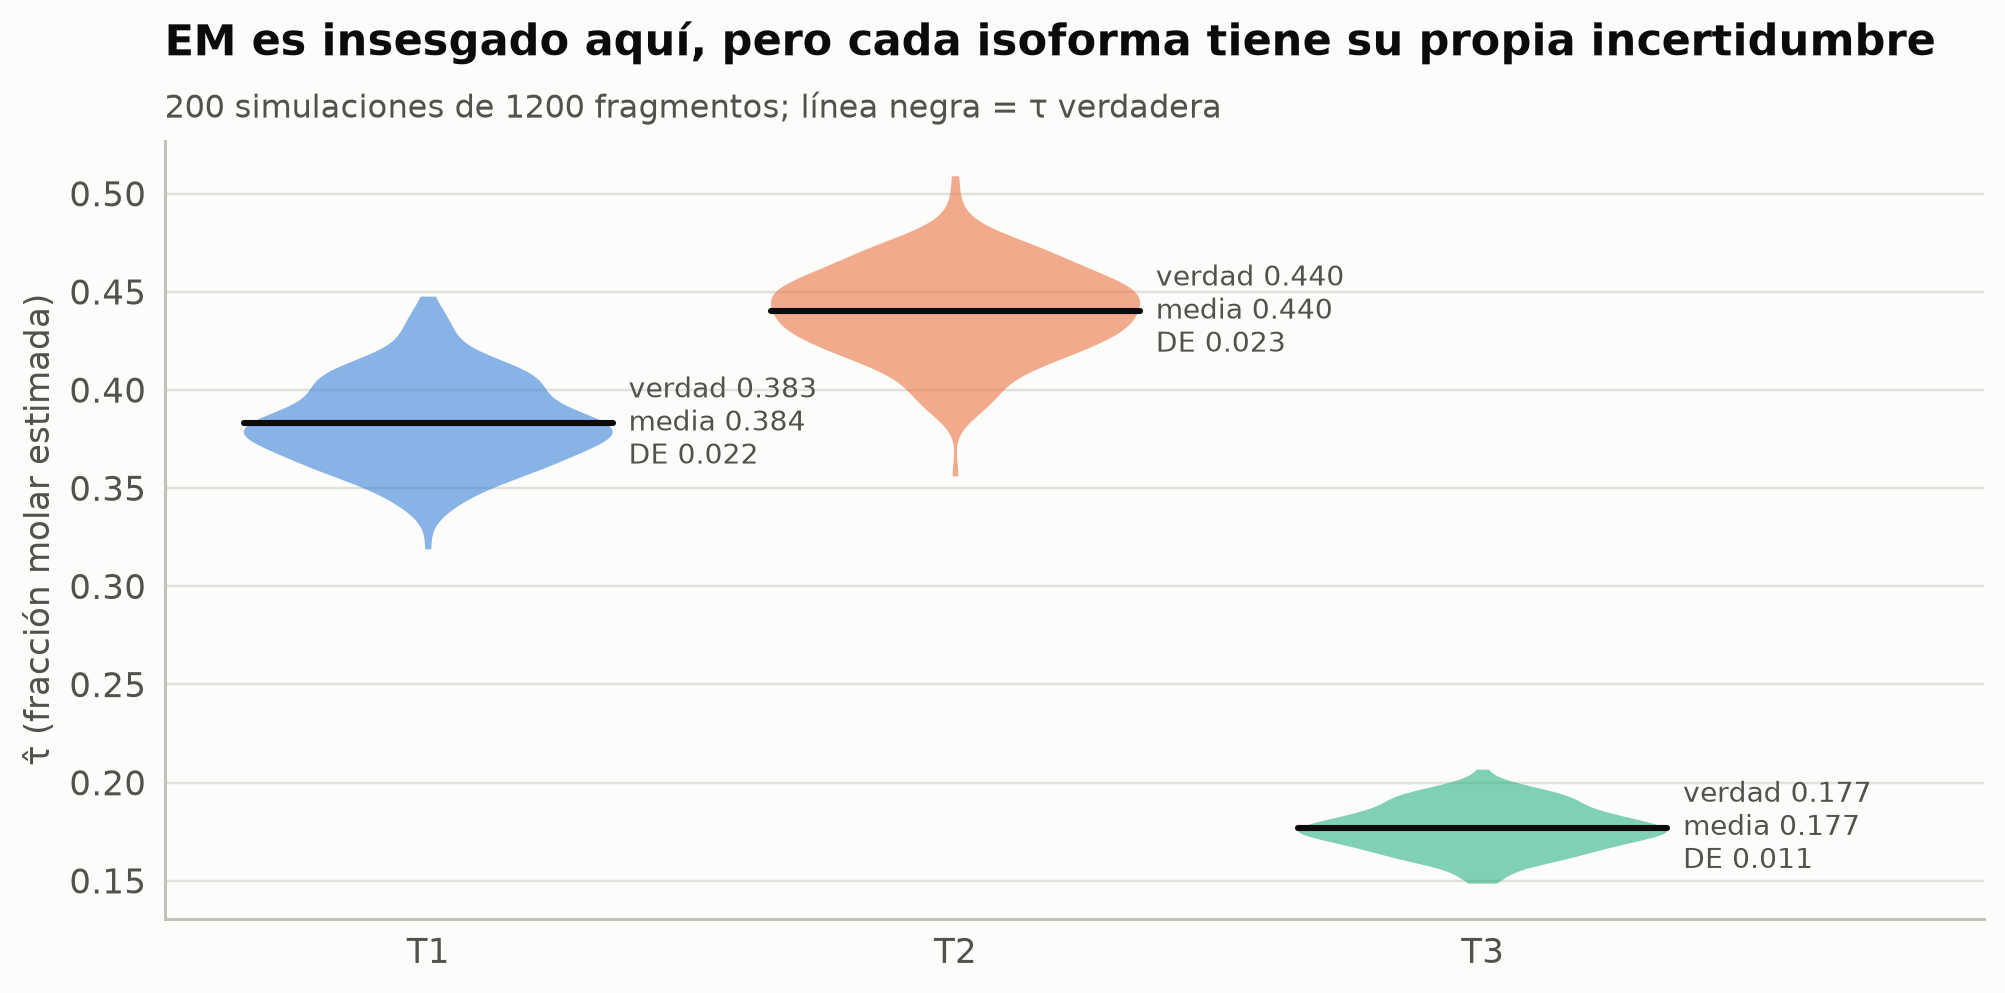

In [21]:
hist_sim = em_isoforms(classes_sim, leff_toy, iters=500, tol=1e-8)
tau_sim_hat = tau_from_alpha(hist_sim[-1], leff_toy)
print("τ verdadera :", TAU_SIM)
print("τ estimada  :", np.round(tau_sim_hat, 3), f"({len(hist_sim) - 1} iteraciones)")

reps = []
for r in range(200):
    s = simulate_fragments(TAU_SIM, N_SIM)
    cl = [(class_members(C), int(n)) for C, n in s.groupby("eqclass").size().items()]
    reps.append(tau_from_alpha(em_isoforms(cl, leff_toy, iters=500, tol=1e-7)[-1], leff_toy))
reps = np.array(reps)
fig, ax = plt.subplots(figsize=(9, 4.4))
parts = ax.violinplot(reps, positions=[1, 2, 3], showextrema=False, widths=0.7)
for b, c in zip(parts["bodies"], cols3):
    b.set_facecolor(c); b.set_alpha(0.55); b.set_edgecolor("none")
for t in range(3):
    ax.plot([t + 0.65, t + 1.35], [TAU_SIM[t]] * 2, color=ec.INK, lw=2)
    ax.text(t + 1.38, TAU_SIM[t], f"verdad {TAU_SIM[t]:.3f}\nmedia {reps[:, t].mean():.3f}\nDE {reps[:, t].std():.3f}",
            va="center", fontsize=9, color=ec.INK_2)
ax.set_xticks([1, 2, 3], ["T1", "T2", "T3"]); ax.set_xlim(0.5, 3.95)
ax.set_ylabel("τ̂ (fracción molar estimada)")
ec.title(ax, "EM es insesgado aquí, pero cada isoforma tiene su propia incertidumbre",
         "200 simulaciones de 1200 fragmentos; línea negra = τ verdadera")
plt.show()

> 🔎 **Qué observamos.** Las medias coinciden con la verdad, pero las desviaciones estándar difieren: T3 tiene un
> exón propio largo (`E3`, 1 kb) y se estima con precisión; T1 y T2, que sólo se distinguen por uniones cortas, oscilan
> más. Esa incertidumbre es la que Salmon cuantifica con `--numBootstraps` o `--numGibbsSamples` y la que RSEM
> estimaba con muestreo de Gibbs.

> 📜 **Un poco de historia: de RPKM a RSEM.** El primer gran estudio de RNA-seq en mamíferos (Mortazavi *et al.*,
> 2008) ya tropezó con las lecturas que mapean en varios lugares: las asignó en proporción a las lecturas únicas de cada
> locus, una especie de «paso E» de una sola iteración. Li y Dewey (2011) formalizaron el problema como un modelo
> generativo completo, lo resolvieron con EM y añadieron intervalos de credibilidad por muestreo de Gibbs; su programa,
> RSEM, funciona incluso sin genoma de referencia, con un transcriptoma ensamblado *de novo*. Casi todos los
> cuantificadores posteriores son variaciones sobre ese modelo.

## 7. Pseudoalineamiento y mapeo selectivo

El modelo anterior no necesita saber **dónde** alinea un fragmento dentro de un transcrito, sólo **con qué
transcritos es compatible**. Bray *et al.* (2016) explotaron esa observación en **kallisto**: construyen un grafo de
De Bruijn del transcriptoma (con $k = 31$ por defecto) en el que cada $k$-mer lleva anotado el conjunto de transcritos
que lo contienen. Para una lectura se buscan sus $k$-mers en el índice y se **intersecan** los conjuntos: el resultado
es la clase de equivalencia de la lectura,

$$
C(r) \;=\; \bigcap_{x \,\in\, K(r)\,:\, x \in \mathcal I} S(x),
$$

| Símbolo | Significado |
|---|---|
| $K(r)$ | $k$-mers de la lectura $r$ (y de su pareja, en bibliotecas pareadas) |
| $\mathcal I$ | índice: todos los $k$-mers del transcriptoma |
| $S(x)$ | conjunto de transcritos que contienen el $k$-mer $x$ |
| $C(r)$ | clase de equivalencia de la lectura |

Como los $k$-mers consecutivos de un mismo tramo del grafo tienen el mismo conjunto, basta consultar unos pocos y
**saltar** el resto. No hay alineamiento base a base: por eso se llama **pseudoalineamiento**. Los autores
cuantificaron 30 millones de lecturas humanas en menos de tres minutos en un ordenador de escritorio.

Hagámoslo a mano con un gen real que responde a la dexametasona: ***TSC22D3***, que codifica **GILZ**
(*glucocorticoid-induced leucine zipper*), uno de los mediadores antiinflamatorios clásicos de los corticoides. Primero
cargamos el transcriptoma reducido de la lección (todas las isoformas GENCODE v26 de 250 genes) y las lecturas.

In [22]:
tx2gene = pd.read_csv(course_file("111_tx2gene.tsv.gz"), sep="\t")
assert tx2gene.transcript_id.is_unique
TX_FA = course_file("111_transcriptome_reduced.fa.gz")
def read_fasta(path):
    seqs, name, buf = {}, None, []
    with gzip.open(path, "rt") as fh:
        for line in fh:
            if line.startswith(">"):
                if name: seqs[name] = "".join(buf)
                name, buf = line[1:].split()[0], []
            else:
                buf.append(line.strip())
    if name: seqs[name] = "".join(buf)
    return seqs
tx_seqs = read_fasta(TX_FA)
print(f"Transcriptoma reducido: {len(tx_seqs)} transcritos de {tx2gene.gene_id.nunique()} genes, "
      f"{sum(map(len, tx_seqs.values()))/1e6:.2f} Mb")
print(tx2gene.groupby("group").agg(genes=("gene_id", "nunique"), transcritos=("transcript_id", "size")).to_string())
print("\nTipos de transcrito:", tx2gene.transcript_type.value_counts().head(5).to_dict())

READS = {run: (course_file(f"111_{run}_500k_sel_1.fastq.gz"), course_file(f"111_{run}_500k_sel_2.fastq.gz"))
         for run in ["SRR1039508", "SRR1039509"]}
def read_pairs(r1, r2):
    with gzip.open(r1, "rt") as f1, gzip.open(r2, "rt") as f2:
        while True:
            h1 = f1.readline()
            if not h1: return
            s1 = f1.readline().strip(); f1.readline(); f1.readline()
            f2.readline(); s2 = f2.readline().strip(); f2.readline(); f2.readline()
            yield h1.split()[0][1:], s1, s2
first = next(read_pairs(*READS["SRR1039509"]))
print("\nPrimer par de SRR1039509:", first[0], "\n  R1:", first[1], "\n  R2:", first[2])

Transcriptoma reducido: 2128 transcritos de 250 genes, 4.02 Mb
           genes  transcritos
group                        
dex_down      14           81
dex_up        38          291
random       150         1242
reference     48          514

Tipos de transcrito: {'protein_coding': 1182, 'retained_intron': 449, 'processed_transcript': 350, 'nonsense_mediated_decay': 144, 'non_stop_decay': 2}

Primer par de SRR1039509: SRR1039509.9/1 
  R1: CTGATGGTGTCCCAGGGAAAGATGGCCCAAGGGGTCCTACTGGTCCTATTGGTCCTCCTGGCC 
  R2: TTACCACCAGGTTCACCATTCTGTCCAGGAGCACCAGGGAAACCAGCAGGTCCTGGAGGGCCA


> ⚠️ **Sobre estas lecturas.** Para que la lección corra en segundos guardamos en el repositorio, de los **primeros
> 500 000 pares** de cada corrida (FASTQ de ENA), sólo los que tocan nuestro transcriptoma reducido: 94 990 pares de
> SRR1039508 (sin tratar) y 88 945 de SRR1039509 (dexametasona) de la línea celular N61311. Las calidades se
> reemplazaron por una constante (`I`) para ahorrar espacio: el mapeo selectivo de Salmon no las usa, y comprobamos que
> los NumReads salen idénticos. Si trabaja en Colab puede descargar usted mismo los pares con la celda opcional del
> final de la sección 8.

In [23]:
K = 31
COMP = str.maketrans("ACGTN", "TGCAN")
def canonical(kmer):
    """k-mer canónico: el menor entre el k-mer y su complemento inverso (la biblioteca no tiene hebra)."""
    rc = kmer.translate(COMP)[::-1]
    return kmer if kmer < rc else rc

gene_tx = tx2gene.query("symbol == 'TSC22D3'").sort_values("length", ascending=False)
iso = list(gene_tx.transcript_id)
iso_name = dict(zip(gene_tx.transcript_id, gene_tx.transcript_name))
kmer_index = collections.defaultdict(set)
for t in iso:
    s = tx_seqs[t]
    for i in range(len(s) - K + 1):
        kmer_index[canonical(s[i:i + K])].add(t)
kmer_index = {k: frozenset(v) for k, v in kmer_index.items()}
colors_count = collections.Counter(kmer_index.values())
print(f"TSC22D3: {len(iso)} isoformas, {len(kmer_index):,} k-mers distintos, {len(colors_count)} 'colores' "
      "(conjuntos de transcritos distintos)")
print(gene_tx[["transcript_name", "length", "transcript_type"]].to_string(index=False))

TSC22D3: 17 isoformas, 4,918 k-mers distintos, 52 'colores' (conjuntos de transcritos distintos)
transcript_name  length transcript_type
    TSC22D3-004    2266  protein_coding
    TSC22D3-008    2213  protein_coding
    TSC22D3-005    2199  protein_coding
    TSC22D3-001    2027  protein_coding
    TSC22D3-002    1812  protein_coding
    TSC22D3-003    1216  protein_coding
    TSC22D3-007     956  protein_coding
    TSC22D3-013     802  protein_coding
    TSC22D3-012     581  protein_coding
    TSC22D3-006     576  protein_coding
    TSC22D3-016     569  protein_coding
    TSC22D3-009     567  protein_coding
    TSC22D3-017     551  protein_coding
    TSC22D3-011     546  protein_coding
    TSC22D3-010     521  protein_coding
    TSC22D3-014     503  protein_coding
    TSC22D3-015     425  protein_coding


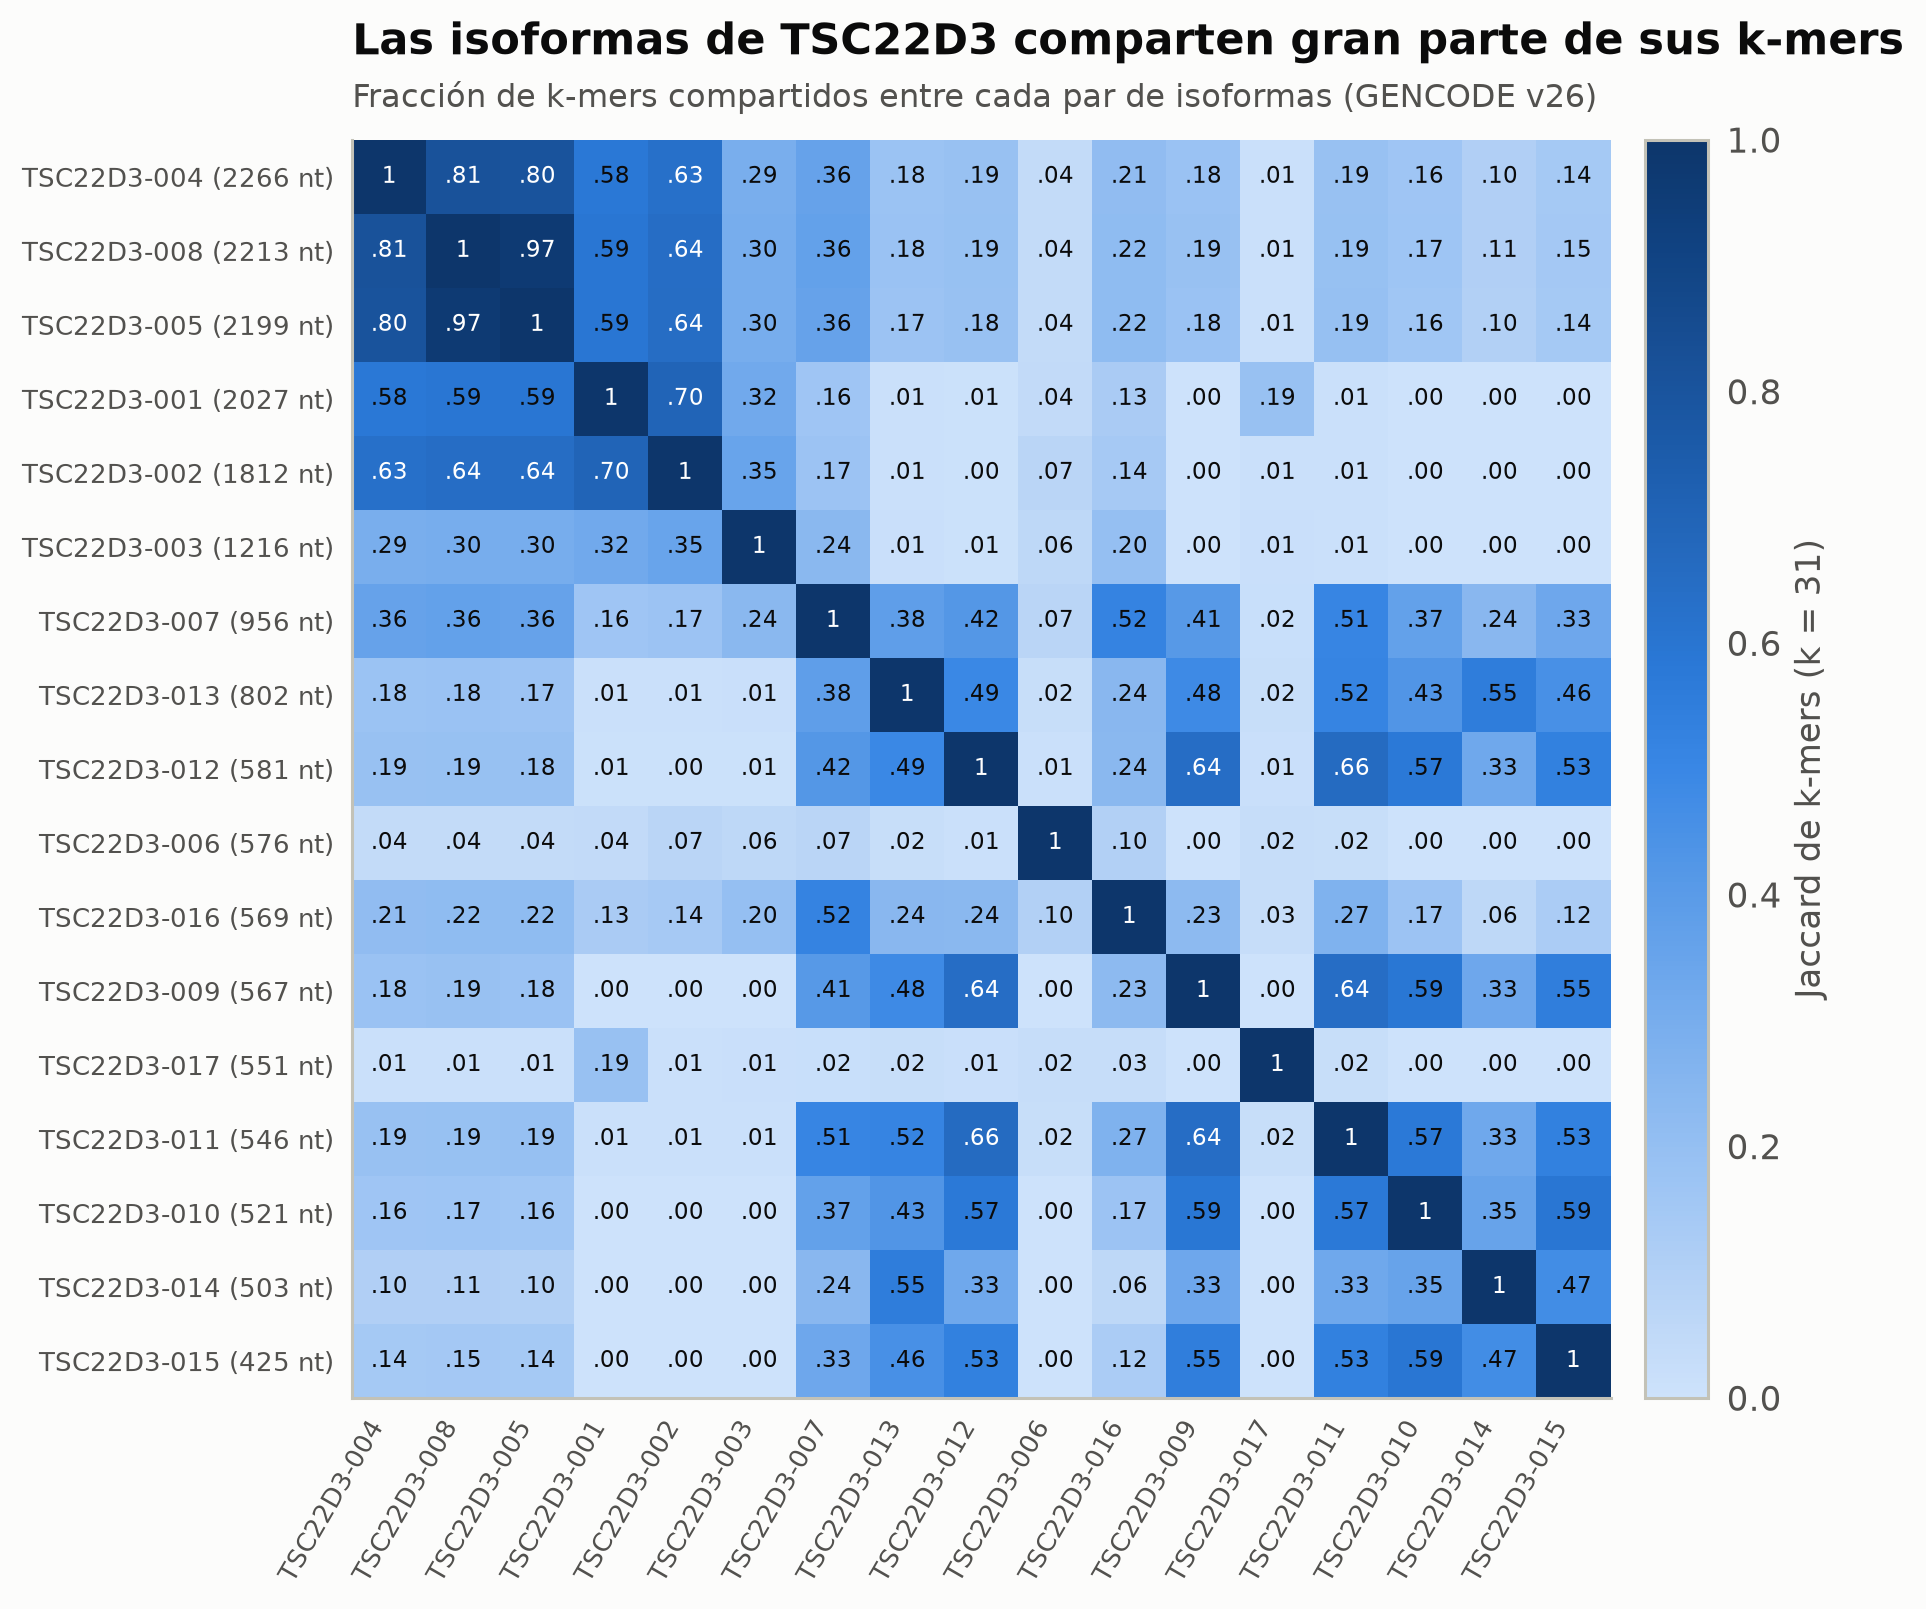

In [24]:
# Cuántos k-mers comparte cada par de isoformas (índice de Jaccard)
km_sets = {t: {k for k, v in kmer_index.items() if t in v} for t in iso}
J = np.array([[len(km_sets[a] & km_sets[b]) / len(km_sets[a] | km_sets[b]) for b in iso] for a in iso])
labels = [f"{iso_name[t]} ({len(tx_seqs[t])} nt)" for t in iso]
fig, ax = plt.subplots(figsize=(9, 7.2))
im = ax.imshow(J, cmap=ec.CMAP_SEQ, vmin=0, vmax=1)
for i in range(len(iso)):
    for j in range(len(iso)):
        ax.text(j, i, f"{J[i, j]:.2f}".lstrip("0") if i != j else "1", ha="center", va="center", fontsize=7.5,
                color="white" if J[i, j] > 0.6 else ec.INK)
ax.set_xticks(range(len(iso)), [iso_name[t] for t in iso], rotation=60, ha="right", fontsize=8.5)
ax.set_yticks(range(len(iso)), labels, fontsize=8.5)
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02).set_label("Jaccard de k-mers (k = 31)")
ec.title(ax, "Las isoformas de TSC22D3 comparten gran parte de sus k-mers",
         "Fracción de k-mers compartidos entre cada par de isoformas (GENCODE v26)")
plt.show()

> 🔎 **Qué observamos.** Muchas parejas comparten más de la mitad de sus $k$-mers: una lectura que cae en esa parte
> común no puede distinguirlas. Ahora pseudoalineamos las lecturas de la muestra con dexametasona. Para ir rápido
> hacemos lo que hace kallisto: consultamos sólo tres $k$-mers por lectura (inicio, centro y final) y, si ninguno está
> en el índice, descartamos el par sin mirar más.

In [25]:
def pseudoalign(pairs, index, k=K):
    classes, lookups, n_pairs, n_hit = collections.Counter(), 0, 0, 0
    for name, s1, s2 in pairs:
        n_pairs += 1
        probes = [s[i:i + k] for s in (s1, s2) for i in (0, (len(s) - k) // 2, len(s) - k) if len(s) >= k]
        lookups += len(probes)
        if not any(canonical(p) in index for p in probes if "N" not in p):
            continue                                            # salto: el par no toca este gen
        n_hit += 1
        cls = None
        for s in (s1, s2):
            for i in range(len(s) - k + 1):
                x = s[i:i + k]
                if "N" in x: continue
                lookups += 1
                S = index.get(canonical(x))
                if S is not None:
                    cls = S if cls is None else cls & S         # intersección de conjuntos
        if cls:
            classes[cls] += 1
        else:
            classes[frozenset()] += 1                           # k-mers en conflicto: intersección vacía
    return classes, lookups, n_pairs, n_hit

t0 = time.time()
cls_tsc, lookups, n_pairs, n_hit = pseudoalign(read_pairs(*READS["SRR1039509"]), kmer_index)
print(f"{n_pairs:,} pares revisados en {time.time()-t0:.1f} s; {n_hit} tocan TSC22D3; "
      f"{lookups:,} consultas al índice (una búsqueda exhaustiva habría hecho {n_pairs*2*33:,})")
rows = [(" + ".join(sorted(iso_name[t] for t in C)) if C else "(vacía: k-mers en conflicto)", len(C), n)
        for C, n in cls_tsc.most_common()]
eq_tsc = pd.DataFrame(rows, columns=["clase de equivalencia", "tamaño |C|", "pares n_C"])
print(f"\n{len(eq_tsc)} clases de equivalencia:")
print(eq_tsc.head(12).to_string(index=False))

88,945 pares revisados en 0.3 s; 103 tocan TSC22D3; 540,468 consultas al índice (una búsqueda exhaustiva habría hecho 5,870,370)

8 clases de equivalencia:
                                                                                        clase de equivalencia  tamaño |C|  pares n_C
                                          TSC22D3-001 + TSC22D3-002 + TSC22D3-004 + TSC22D3-005 + TSC22D3-008           5         39
                                                                                    TSC22D3-001 + TSC22D3-017           2         20
                            TSC22D3-001 + TSC22D3-002 + TSC22D3-003 + TSC22D3-004 + TSC22D3-005 + TSC22D3-008           6         18
TSC22D3-001 + TSC22D3-002 + TSC22D3-003 + TSC22D3-004 + TSC22D3-005 + TSC22D3-007 + TSC22D3-008 + TSC22D3-016           8         11
              TSC22D3-001 + TSC22D3-002 + TSC22D3-003 + TSC22D3-004 + TSC22D3-005 + TSC22D3-007 + TSC22D3-008           7         10
                                              

> 🔎 **Qué observamos.** Un centenar de pares de TSC22D3 se resume en ocho clases. Algunas son de tamaño 1
> (lecturas que atraviesan una unión o un exón exclusivo), pero la más poblada suele contener varias isoformas: el EM
> tendrá trabajo. El salto de $k$-mers redujo las consultas en más de un orden de magnitud respecto a revisar los 33
> $k$-mers de cada lectura. (Nuestro pseudoalineador es didáctico: no maneja errores de secuenciación, que en kallisto
> se toleran porque sólo se exige compatibilidad con los $k$-mers presentes en el índice.)

### Salmon: mapeo selectivo, sesgos y señuelos

**Salmon** (Patro *et al.*, 2017) persigue el mismo objetivo con otra arquitectura. Su *cuasi-mapeo* localiza
coincidencias exactas largas y obtiene también la posición y la orientación aproximadas; la inferencia se hace en dos
fases, una «en línea» mientras llegan las lecturas y otra «fuera de línea» que refina las abundancias sobre las clases
de equivalencia con EM o con Bayes variacional (VBEM, la opción por defecto). Su aportación central es modelar los
**sesgos** de las bibliotecas reales: contenido en GC del fragmento (`--gcBias`), secuencia alrededor de los extremos,
porque los hexámeros del cebado no son tan aleatorios (`--seqBias`), y posición a lo largo del transcrito
(degradación en 5′ o 3′). Salmon estima esos sesgos con los propios datos y los usa para corregir la **longitud
efectiva** de cada transcrito.

Las versiones posteriores sustituyeron el cuasi-mapeo por un **alineamiento selectivo** (Srivastava *et al.*, 2020)
que verifica cada coincidencia candidata con un alineamiento rápido y puede usar **señuelos** (*decoys*). La idea de
los señuelos es simple: **si una lectura se parece más a algo que no queremos cuantificar que a nuestros transcritos,
hay que descartarla en vez de forzarla** en el transcrito más parecido. Con el transcriptoma completo, el señuelo
habitual es el genoma (lecturas de intrones o de regiones no anotadas). Con un índice **parcial** como el nuestro
(250 genes de ~60 000) el problema es mucho peor: todas las lecturas de los genes que *no* están en el índice buscan
dónde caer. En la consola, el flujo del libro es:

```bash
# 1. Índice del transcriptoma (con el genoma como señuelo)
grep '^>' genoma.fa | cut -d ' ' -f 1 | sed 's/>//' > decoys.txt
cat transcritos.fa genoma.fa > gentrome.fa
salmon index -t gentrome.fa -d decoys.txt -i idx_salmon -k 31

# 2. Cuantificación de una muestra pareada con corrección de sesgos
salmon quant -i idx_salmon -l A \
    -1 ctrl1_R1.fastq.gz -2 ctrl1_R2.fastq.gz \
    --validateMappings --gcBias --seqBias \
    -p 8 -o quant/ctrl1
# quant/ctrl1/quant.sf: Name Length EffectiveLength TPM NumReads
```

Nuestros señuelos no son un genoma de 3 Gb (no cabe en una clase de 3 minutos) sino **señuelos parciales**: 2696
tramos (1,1 Mb en total) del resto del transcriptoma GENCODE donde se parecen a nuestros transcritos. Es la misma
lógica de la primera versión de los señuelos de Salmon, que tomaba sólo las regiones del genoma similares al
transcriptoma. Construyamos los dos índices.

## 8. Salmon en vivo, con y sin señuelos

In [26]:
def run(cmd, log=None):
    """Ejecuta un comando, mide el tiempo y muestra el error si falla."""
    t0 = time.time()
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        print(res.stderr[-2000:])
        raise RuntimeError("falló: " + " ".join(cmd[:3]))
    if log:
        open(log, "w").write(res.stderr)
    return time.time() - t0

DECOY_FA = course_file("111_decoys.fa.gz")
with open(f"{WORK}/gentrome.fa", "w") as out:              # transcritos primero, señuelos al final
    for path in (TX_FA, DECOY_FA):
        with gzip.open(path, "rt") as fh:
            shutil.copyfileobj(fh, out)
decoy_names = [l[1:].split()[0] for l in gzip.open(DECOY_FA, "rt") if l.startswith(">")]
open(f"{WORK}/decoys.txt", "w").write("\n".join(decoy_names) + "\n")
print(f"gentrome.fa: {len(tx_seqs)} transcritos + {len(decoy_names)} señuelos; ejemplo de nombre: {decoy_names[0]}")

t_red = run([SALMON, "index", "-t", TX_FA, "-i", f"{WORK}/idx_red", "-k", "31", "-p", "2"])
t_dec = run([SALMON, "index", "-t", f"{WORK}/gentrome.fa", "-d", f"{WORK}/decoys.txt",
             "-i", f"{WORK}/idx_dec", "-k", "31", "-p", "2"])
print(f"índice reducido: {t_red:.1f} s · índice con señuelos: {t_dec:.1f} s")

gentrome.fa: 2128 transcritos + 2696 señuelos; ejemplo de nombre: decoy_PINK1-AS_ENST00000451424.1_0_498


índice reducido: 0.8 s · índice con señuelos: 1.1 s


In [27]:
RUNS = {"SRR1039508": "sin tratar", "SRR1039509": "dexametasona"}
qdir = {}
for run_id in RUNS:
    r1, r2 = READS[run_id]
    for ix in ["red", "dec"]:
        out = f"{WORK}/quant_{ix}_{run_id}"
        t = run([SALMON, "quant", "-i", f"{WORK}/idx_{ix}", "-l", "A", "-1", r1, "-2", r2,
                 "--validateMappings", "--dumpEq", "-p", "2", "-o", out])
        qdir[(ix, run_id)] = out
        print(f"{run_id} · índice {'con señuelos' if ix == 'dec' else 'reducido   '}: {t:.1f} s")

full_summary = json.load(open(course_file("111_full_index_summary.json")))
rows = []
for (ix, run_id), d in qdir.items():
    mi = json.load(open(f"{d}/aux_info/meta_info.json"))
    lf = json.load(open(f"{d}/lib_format_counts.json"))
    rows.append(dict(run=run_id, índice="con señuelos" if ix == "dec" else "reducido", biblioteca=lf["expected_format"],
                     pares_en_archivo=mi["num_processed"], asignados=mi["num_mapped"],
                     a_señuelos=mi.get("num_decoy_fragments", 0),
                     pct_de_500k=round(100 * mi["num_mapped"] / 500_000, 2),
                     media_fragmento=round(mi["frag_length_mean"], 1), clases=mi["num_eq_classes"]))
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
for run_id, v in full_summary.items():
    print(f"{run_id}: con el transcriptoma COMPLETO (198 540 transcritos) se asignaron "
          f"{v['num_mapped_full']:,} de {v['num_processed']:,} pares ({v['percent_mapped_full']:.1f} %)")

SRR1039508 · índice reducido   : 0.4 s


SRR1039508 · índice con señuelos: 0.6 s


SRR1039509 · índice reducido   : 0.4 s


SRR1039509 · índice con señuelos: 0.7 s
       run       índice biblioteca  pares_en_archivo  asignados  a_señuelos  pct_de_500k  media_fragmento  clases
SRR1039508     reducido         IU             94990      94990           0        19.00            159.5    3888
SRR1039508 con señuelos         IU             94990      91745        3245        18.35            159.7    2743
SRR1039509     reducido         IU             88945      88945           0        17.79            162.3    4243
SRR1039509 con señuelos         IU             88945      85350        3595        17.07            162.6    2920
SRR1039508: con el transcriptoma COMPLETO (198 540 transcritos) se asignaron 472,212 de 500,000 pares (94.4 %)
SRR1039509: con el transcriptoma COMPLETO (198 540 transcritos) se asignaron 469,572 de 500,000 pares (93.9 %)


> 🔎 **Qué observamos.**
> * Salmon detectó solo el tipo de biblioteca **`IU`**: *inward* (las dos lecturas del par apuntan una hacia la otra)
>   y *unstranded* (sin hebra), como corresponde a un protocolo sin hebra.
> * Con el índice reducido se asignan ~19 % de los 500 000 pares: nuestros 250 genes incluyen varios muy expresados
>   en músculo liso (*FN1*, *COL1A2*, *EEF1A1*, *DCN*). Con el transcriptoma completo se asigna ~94 %.
> * Con señuelos, ~3 300–3 600 pares por muestra dejan de asignarse: se parecían más a un señuelo que a nuestros
>   transcritos. ¿Eran realmente intrusos? Lo comprobaremos contra la cuantificación con el transcriptoma completo.
> * La media de los fragmentos ronda los 160 nt: con lecturas de 63 nt, los dos extremos del par casi se tocan.

Antes, miremos la distribución de longitudes de fragmento $P_F$ que Salmon estimó con los pares que mapean de forma
única: es la que usa para calcular $\tilde\ell_t$ con la ecuación de la sección 5.

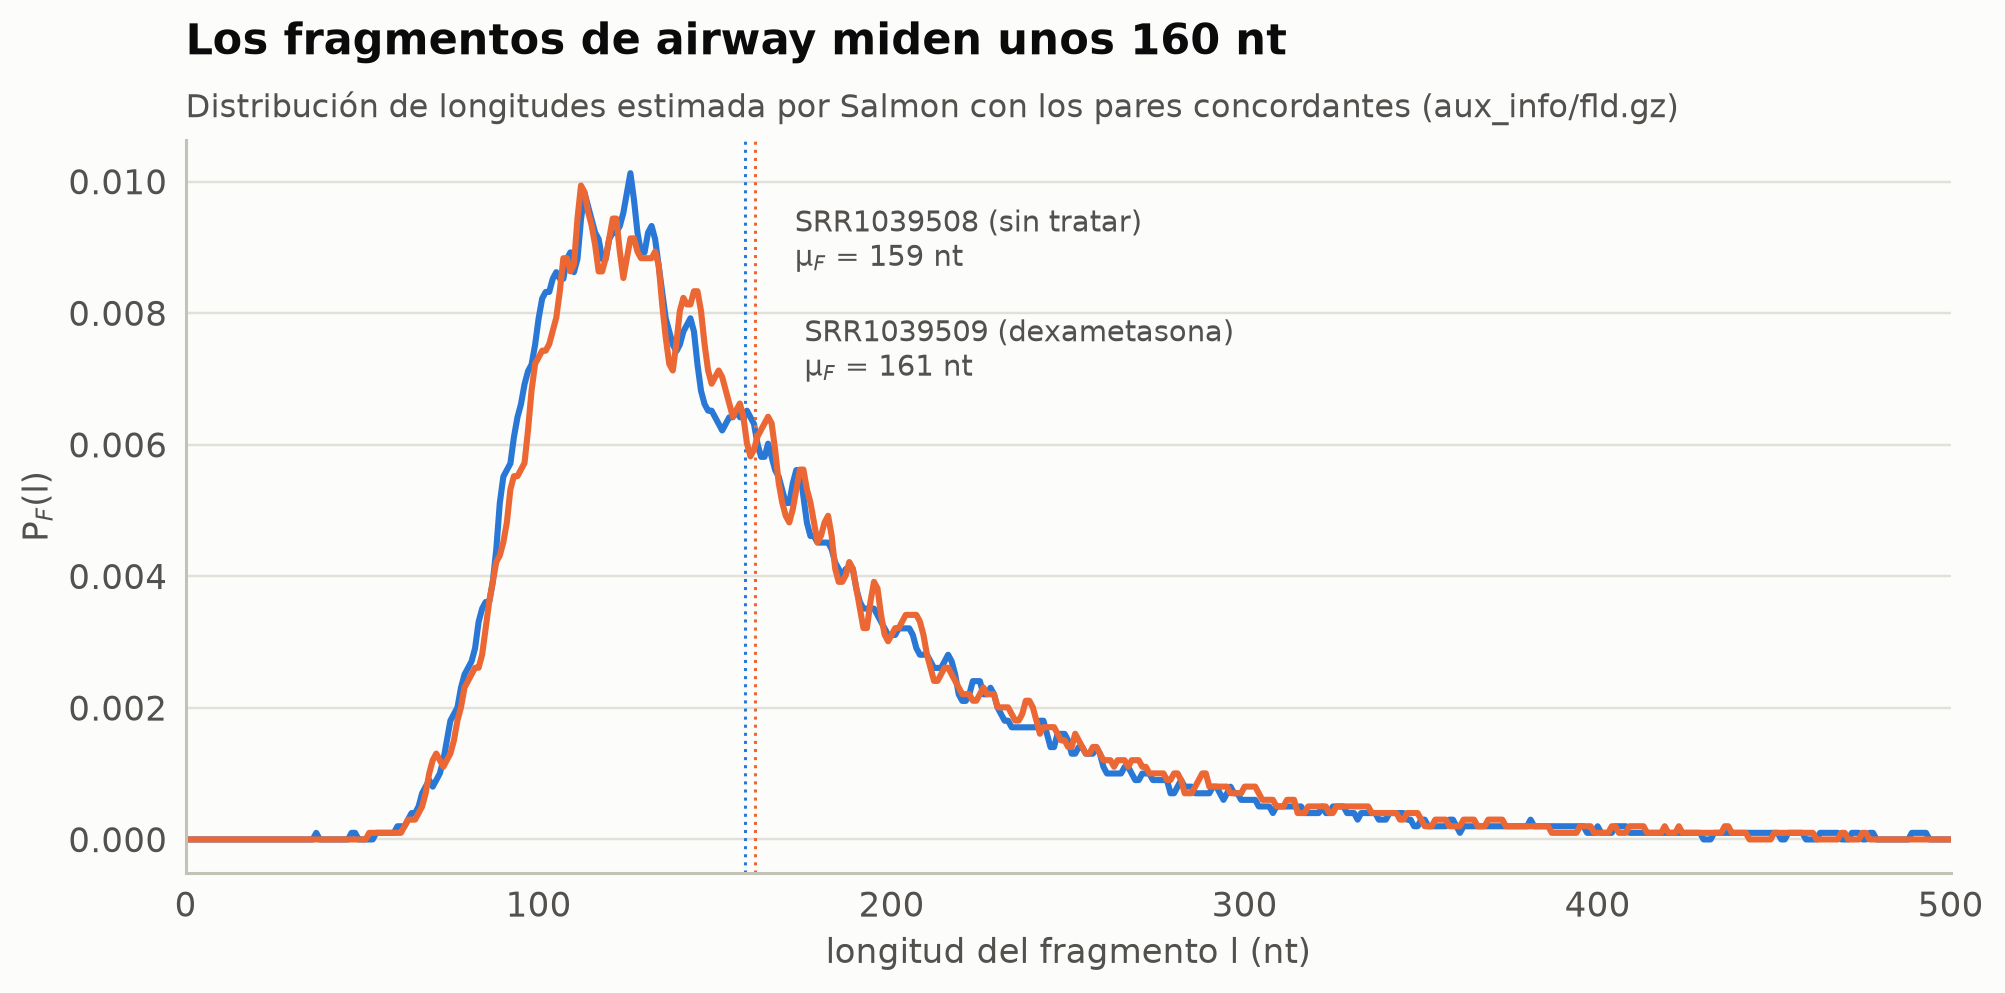

quant.sf (primeras filas):
                   Length  EffectiveLength         TPM  NumReads  symbol transcript_name    Leff/L
Name                                                                                              
ENST00000474874.5     479          317.773    0.000000     0.000  ERRFI1      ERRFI1-003  0.663409
ENST00000377482.9    3104         2941.386  563.154545    72.853  ERRFI1      ERRFI1-001  0.947611
ENST00000467067.1    2097         1934.386   48.743041     4.147  ERRFI1      ERRFI1-002  0.922454
ENST00000469499.5     995          832.386    0.000000     0.000  ERRFI1      ERRFI1-004  0.836569

Transcritos < 300 nt: mediana ℓ̃/ℓ = 0.40;  > 3000 nt: 0.97


In [28]:
fig, ax = plt.subplots(figsize=(9, 4.4))
for (run_id, col) in zip(RUNS, [ec.BLUE, ec.ORANGE]):
    fld = np.frombuffer(gzip.open(f"{qdir[('dec', run_id)]}/aux_info/fld.gz").read(), dtype=np.int32).astype(float)
    pf = fld / fld.sum(); l = np.arange(len(pf))
    mu = (l * pf).sum()
    ax.plot(l, pf, color=col, lw=2)
    ax.axvline(mu, color=col, ls=":", lw=1)
    ax.text(mu + 14, pf.max() * (0.95 if col == ec.BLUE else 0.8), f"{run_id} ({RUNS[run_id]})\nμ$_F$ = {mu:.0f} nt",
            color=ec.INK_2, fontsize=9.5, va="top")
ax.set_xlim(0, 500); ax.set_xlabel("longitud del fragmento l (nt)"); ax.set_ylabel("P$_F$(l)")
ec.title(ax, "Los fragmentos de airway miden unos 160 nt",
         "Distribución de longitudes estimada por Salmon con los pares concordantes (aux_info/fld.gz)")
plt.show()

q = pd.read_csv(f"{qdir[('dec', 'SRR1039509')]}/quant.sf", sep="\t", index_col=0)
q = q.join(tx2gene.set_index("transcript_id")[["symbol", "transcript_name"]])
q["Leff/L"] = q.EffectiveLength / q.Length
print("quant.sf (primeras filas):")
print(q.head(4).to_string())
print(f"\nTranscritos < 300 nt: mediana ℓ̃/ℓ = {q.loc[q.Length < 300, 'Leff/L'].median():.2f};  "
      f"> 3000 nt: {q.loc[q.Length > 3000, 'Leff/L'].median():.2f}")

### ¿Qué hicieron los señuelos? La comparación con el transcriptoma completo

Para saber la «verdad» cuantificamos los **mismos 500 000 pares** con un índice de Salmon del transcriptoma GENCODE v26
**completo** (198 540 transcritos; se construyó fuera de clase porque tarda y ocupa varios GB) y guardamos el resultado
de nuestros transcritos. Comparemos, gen a gen, los conteos estimados (suma de NumReads de sus isoformas) con los tres
índices. El cociente $\log_2\big((\text{reducido}+1)/(\text{completo}+1)\big)$ mide cuánto **infla** el índice parcial
cada gen.

In [29]:
full_tx = pd.read_csv(course_file("111_full_reference_tx.tsv.gz"), sep="\t", index_col=0)
sym = tx2gene.set_index("transcript_id").symbol
def gene_counts(path):
    qq = pd.read_csv(f"{path}/quant.sf", sep="\t", index_col=0)
    qq = qq[~qq.index.str.startswith("decoy_")]
    return qq.NumReads.groupby(sym.reindex(qq.index).values).sum()
cmp = {}
for run_id in RUNS:
    d = pd.DataFrame({"reducido": gene_counts(qdir[("red", run_id)]),
                      "con_señuelos": gene_counts(qdir[("dec", run_id)]),
                      "completo": full_tx[f"NumReads_{run_id}"].groupby(sym.reindex(full_tx.index).values).sum()})
    d["lfc_red"] = np.log2((d.reducido + 1) / (d.completo + 1))
    d["lfc_dec"] = np.log2((d.con_señuelos + 1) / (d.completo + 1))
    cmp[run_id] = d
    exc_r, exc_d = (d.reducido - d.completo).clip(lower=0).sum(), (d.con_señuelos - d.completo).clip(lower=0).sum()
    print(f"{run_id}: fragmentos de más respecto al índice completo: sin señuelos {exc_r:,.0f}, con señuelos {exc_d:,.0f}"
          f"  ·  genes inflados > 2×: {(d.lfc_red > 1).sum()} → {(d.lfc_dec > 1).sum()}")
d9 = cmp["SRR1039509"]
print("\nLos genes más inflados en SRR1039509:")
print(d9.sort_values("lfc_red", ascending=False).head(10).round(1).to_string())

origins = pd.read_csv(course_file("111_false_capture_origins.tsv"), sep="\t")
top_orig = (origins.groupby(["assigned_gene_reduced", "true_gene_full"]).fragments.sum()
            .sort_values(ascending=False).head(12).round(1))
print("\n¿De dónde venían en realidad? (ambas muestras; gen asignado por el índice reducido ← gen verdadero)")
print(top_orig.to_string())

SRR1039508: fragmentos de más respecto al índice completo: sin señuelos 3,567, con señuelos 322  ·  genes inflados > 2×: 44 → 3
SRR1039509: fragmentos de más respecto al índice completo: sin señuelos 3,895, con señuelos 301  ·  genes inflados > 2×: 39 → 7

Los genes más inflados en SRR1039509:
                reducido  con_señuelos  completo  lfc_red  lfc_dec
MYH11               70.1           0.0       0.0      6.2      0.0
SLC29A4            114.5           5.0       1.0      5.9      1.6
TRPV1              113.9           5.0       2.2      5.2      0.9
GRK4                34.5           2.0       0.0      5.1      1.6
TBCCD1              48.0           4.0       1.2      4.5      1.2
ALDH6A1            246.1          15.0      11.2      4.3      0.4
RP11-231C18.3      139.0         123.0       9.1      3.8      3.6
COQ7                31.9           2.0       2.0      3.5      0.0
RP11-1212A22.4     113.0          44.0      16.1      2.7      1.4
ABI2                93.4          3

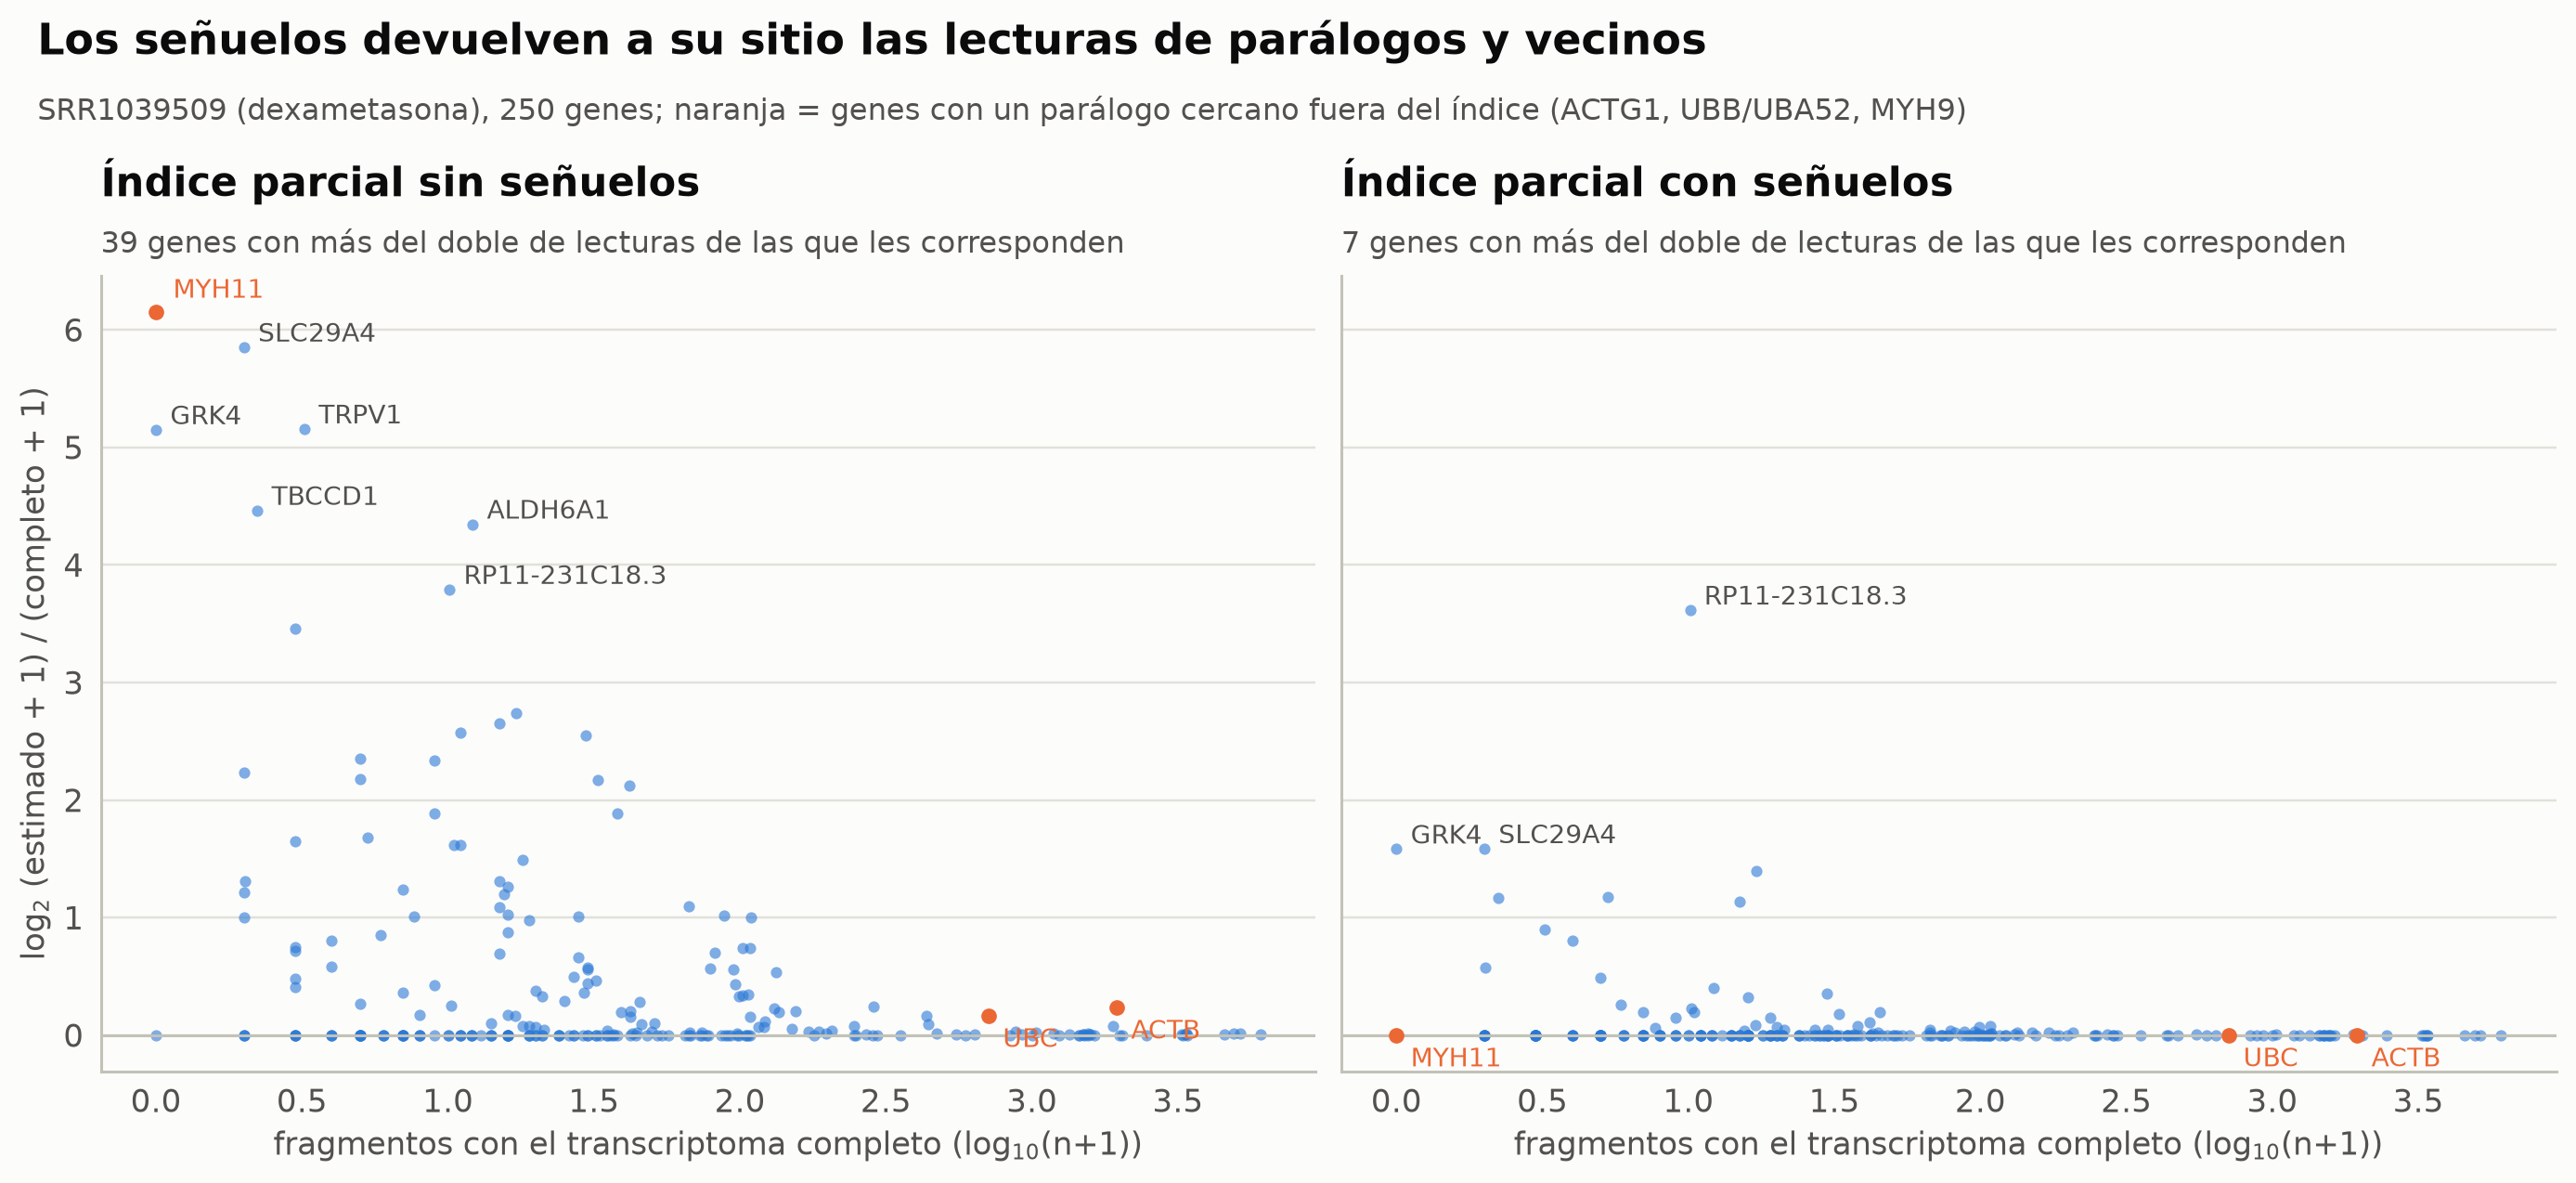

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), sharey=True)
grp = tx2gene.drop_duplicates("symbol").set_index("symbol").group
for ax, col, lab in [(axes[0], "lfc_red", "sin señuelos"), (axes[1], "lfc_dec", "con señuelos")]:
    x = np.log10(d9.completo + 1); y = d9[col]
    ax.scatter(x, y, s=16, color=ec.BLUE, alpha=0.6, lw=0)
    big = d9[d9[col] > 1.5].drop(["ACTB", "UBC", "MYH11"], errors="ignore").sort_values(col, ascending=False).head(6)
    for gname, r in big.iterrows():
        ax.annotate(gname, (np.log10(r.completo + 1), r[col]), xytext=(5, 2), textcoords="offset points",
                    fontsize=9, color=ec.INK_2)
    for gname in ["ACTB", "UBC", "MYH11"]:
        r = d9.loc[gname]
        ax.scatter([np.log10(r.completo + 1)], [r[col]], s=30, color=ec.ORANGE, zorder=4)
        ax.annotate(gname, (np.log10(r.completo + 1), r[col]), textcoords="offset points",
                    xytext=(6, 5) if (gname == "MYH11" and r[col] > 1) else (5, -11), fontsize=9, color=ec.ORANGE)
    ax.axhline(0, color=ec.BASELINE, lw=1)
    ax.set_xlabel("fragmentos con el transcriptoma completo (log$_{10}$(n+1))")
    ec.title(ax, f"Índice parcial {lab}",
             f"{(d9[col] > 1).sum()} genes con más del doble de lecturas de las que les corresponden")
axes[0].set_ylabel("log$_2$ (estimado + 1) / (completo + 1)")
ec.fig_title(fig, "Los señuelos devuelven a su sitio las lecturas de parálogos y vecinos",
             "SRR1039509 (dexametasona), 250 genes; naranja = genes con un parálogo cercano fuera del índice (ACTG1, UBB/UBA52, MYH9)")
plt.show()

> 🔎 **Qué observamos.** Sin señuelos, decenas de genes reciben lecturas que no son suyas. Hay dos tipos de intrusos:
> * **Parálogos:** *ACTB* absorbe ~300 lecturas por muestra de *ACTG1* (las dos actinas citoplasmáticas son casi
>   idénticas), *UBC* las de *UBB* y *UBA52* (todas codifican ubiquitina), *TPM2* las de *TPM4*. En estos genes
>   abundantes el error relativo es de ~20 %. Peor le va a *MYH11*, la miosina del músculo liso, que en este cultivo
>   casi no se expresa: sin señuelos «recibe» unas 70 lecturas de su parálogo *MYH9* y parecería expresada.
> * **Genes poco expresados que comparten un trocito con un gen muy expresado** (una repetición en el UTR, un exón de
>   un gen solapado): *ALDH6A1*, *SLC29A4* o *TRPV1* multiplican sus lecturas por 10 o por 100. Para estos genes el
>   índice parcial sin señuelos es **inútil**, y en un análisis de expresión diferencial aparecerían como falsos
>   positivos si el gen intruso cambia con el tratamiento.
>
> Con los señuelos casi todo vuelve a su sitio. Lo que queda (p. ej. un par de lncRNA del tipo *RP11-…*) viene de
> regiones que nuestros señuelos parciales no cubren: con el genoma completo como señuelo, el problema desaparece.

Explore los genes uno a uno en el gráfico interactivo: el cursor muestra los conteos con los tres índices y de qué
genes venían las lecturas intrusas.

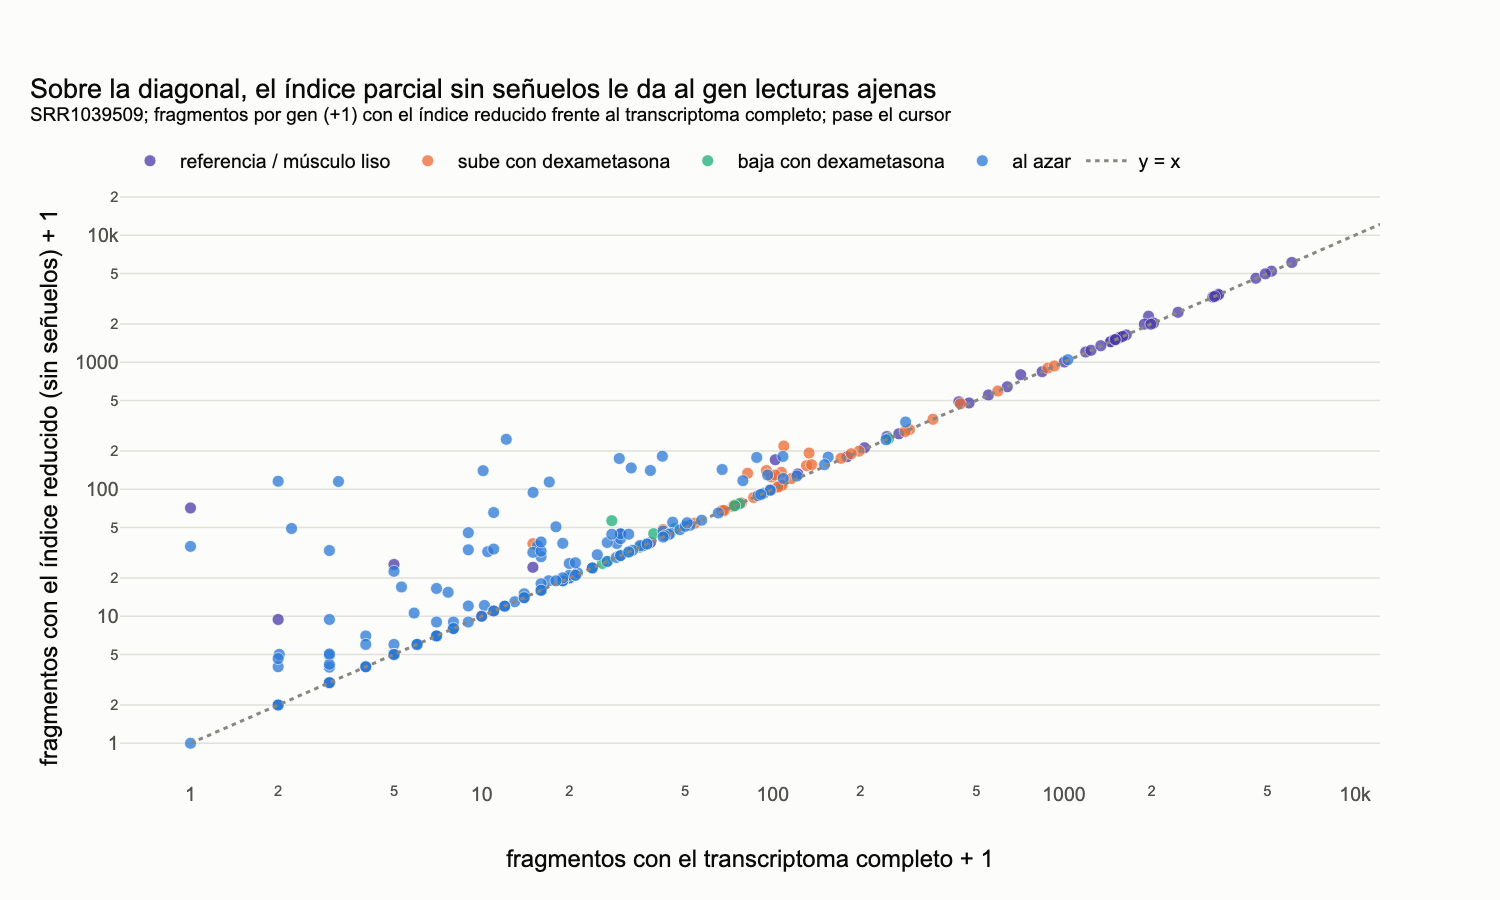

In [31]:
orig9 = origins[origins.run == "SRR1039509"]
def origin_text(gname):
    o = orig9[orig9.assigned_gene_reduced == gname].nlargest(3, "fragments")
    return "<br>".join(f"  ← {r.true_gene_full}: {r.fragments:.0f}" for r in o.itertuples()) or "  (ninguna)"
dd = d9.copy(); dd["grupo"] = grp.reindex(dd.index).map(
    {"dex_up": "sube con dexametasona", "dex_down": "baja con dexametasona", "reference": "referencia / músculo liso",
     "random": "al azar"}).values
fig = go.Figure()
for g_es, col in zip(["referencia / músculo liso", "sube con dexametasona", "baja con dexametasona", "al azar"],
                     [ec.VIOLET, ec.ORANGE, ec.AQUA, ec.BLUE]):
    sub = dd[dd.grupo == g_es]
    fig.add_trace(go.Scatter(
        x=sub.completo + 1, y=sub.reducido + 1, mode="markers", name=g_es,
        marker=dict(size=8, color=col, opacity=0.75, line=dict(width=0.5, color="white")),
        text=[f"<b>{gname}</b> ({g_es})<br>completo: {r.completo:.0f}<br>reducido: {r.reducido:.0f} "
              f"(×{(r.reducido + 1) / (r.completo + 1):.1f})<br>con señuelos: {r.con_señuelos:.0f}"
              f"<br>lecturas intrusas vienen de:<br>{origin_text(gname)}" for gname, r in sub.iterrows()],
        hoverinfo="text"))
lim = [1, dd[["completo", "reducido"]].max().max() * 2]
fig.add_trace(go.Scatter(x=lim, y=lim, mode="lines", line=dict(color=ec.MUTED, dash="dot"), name="y = x",
                         hoverinfo="skip"))
fig.update_layout(
    title="Sobre la diagonal, el índice parcial sin señuelos le da al gen lecturas ajenas<br><sup>SRR1039509; "
          "fragmentos por gen (+1) con el índice reducido frente al transcriptoma completo; pase el cursor</sup>",
    xaxis=dict(type="log", title="fragmentos con el transcriptoma completo + 1"),
    yaxis=dict(type="log", title="fragmentos con el índice reducido (sin señuelos) + 1"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=600, margin=dict(t=130))
fig.show()

### Nuestro EM sobre las clases de equivalencia de Salmon

Con `--dumpEq`, Salmon escribe sus clases de equivalencia en `aux_info/eq_classes.txt.gz`: el número de transcritos,
el de clases, los nombres y una línea por clase con `k  t1 … tk  n_C`. Con `--dumpEqWeights` añade, para cada
transcrito de la clase, un **peso** que ya incluye $1/\tilde\ell_t$ y la probabilidad del alineamiento y de la longitud
del fragmento. Corramos Salmon con el EM clásico (`--useEM`, sin factorización por rangos) y comparemos con nuestro EM
del libro, vectorizado con matrices dispersas: si $A$ es la matriz clases × transcritos,

$$
\alpha^{(k+1)} = \frac{1}{N}\,\Big(A^\top \frac{n}{A\,x^{(k)}}\Big)\odot x^{(k)},\qquad x^{(k)}_t = \frac{\alpha_t^{(k)}}{\tilde\ell_t},
$$

que es exactamente el paso E seguido del paso M (la división y el producto $\odot$ son elemento a elemento).

In [32]:
em_dir = f"{WORK}/quant_em_SRR1039508"
run([SALMON, "quant", "-i", f"{WORK}/idx_dec", "-l", "A", "-1", READS["SRR1039508"][0], "-2", READS["SRR1039508"][1],
     "--validateMappings", "--useEM", "--rangeFactorizationBins", "0", "--dumpEqWeights", "-p", "2", "-o", em_dir])

def read_eq(path, weights):
    with gzip.open(path, "rt") as fh:
        T = int(fh.readline()); C = int(fh.readline())
        names = [fh.readline().strip() for _ in range(T)]
        r, c, v, n = [], [], [], []
        for i in range(C):
            p = fh.readline().split(); k = int(p[0])
            idx = list(map(int, p[1:1 + k]))
            w = list(map(float, p[1 + k:1 + 2 * k])) if weights else [1.0] * k
            r += [i] * k; c += idx; v += w; n.append(int(p[-1]))
    return names, sp.csr_matrix((v, (r, c)), shape=(C, T)), np.array(n, float)

def em_sparse(A, n, leff, iters=20000, tol=1e-9):
    a = np.full(A.shape[1], 1 / A.shape[1]); N = n.sum()
    for it in range(iters):
        x = a / leff
        new = (A.T @ (n / (A @ x))) * x / N
        if np.abs(new - a).max() < tol:
            break
        a = new
    return new * N, it + 1

qs = pd.read_csv(f"{em_dir}/quant.sf", sep="\t", index_col=0)
names, A_w, n_eq = read_eq(f"{em_dir}/aux_info/eq_classes.txt.gz", weights=True)
_, A_1, _ = read_eq(f"{em_dir}/aux_info/eq_classes.txt.gz", weights=False)
leff_s = qs.EffectiveLength.reindex(names).fillna(1.0).values      # los señuelos no tienen ℓ̃ (no aparecen en clases)
t0 = time.time()
ours_book, it_b = em_sparse(A_1, n_eq, leff_s)                      # el modelo del libro: y_jt ∈ {0,1} y 1/ℓ̃
ours_w, it_w = em_sparse(A_w, n_eq, np.ones_like(leff_s))           # los pesos de Salmon ya traen 1/ℓ̃
print(f"{A_1.shape[0]} clases × {len(qs)} transcritos · EM en {time.time()-t0:.1f} s ({it_b} y {it_w} iteraciones)")
ours_book = pd.Series(ours_book, index=names).reindex(qs.index)
ours_w = pd.Series(ours_w, index=names).reindex(qs.index)
for lab, o in [("modelo del libro (indicadoras)", ours_book), ("con los pesos de Salmon", ours_w)]:
    r = np.corrcoef(np.log1p(o), np.log1p(qs.NumReads))[0, 1]
    print(f"{lab:32s}: r(log) = {r:.4f}   máx |dif| = {(o - qs.NumReads).abs().max():7.1f} fragmentos")

2229 clases × 2128 transcritos · EM en 0.6 s (11877 y 5778 iteraciones)
modelo del libro (indicadoras)  : r(log) = 0.9864   máx |dif| =   314.9 fragmentos
con los pesos de Salmon         : r(log) = 0.9994   máx |dif| =    10.8 fragmentos


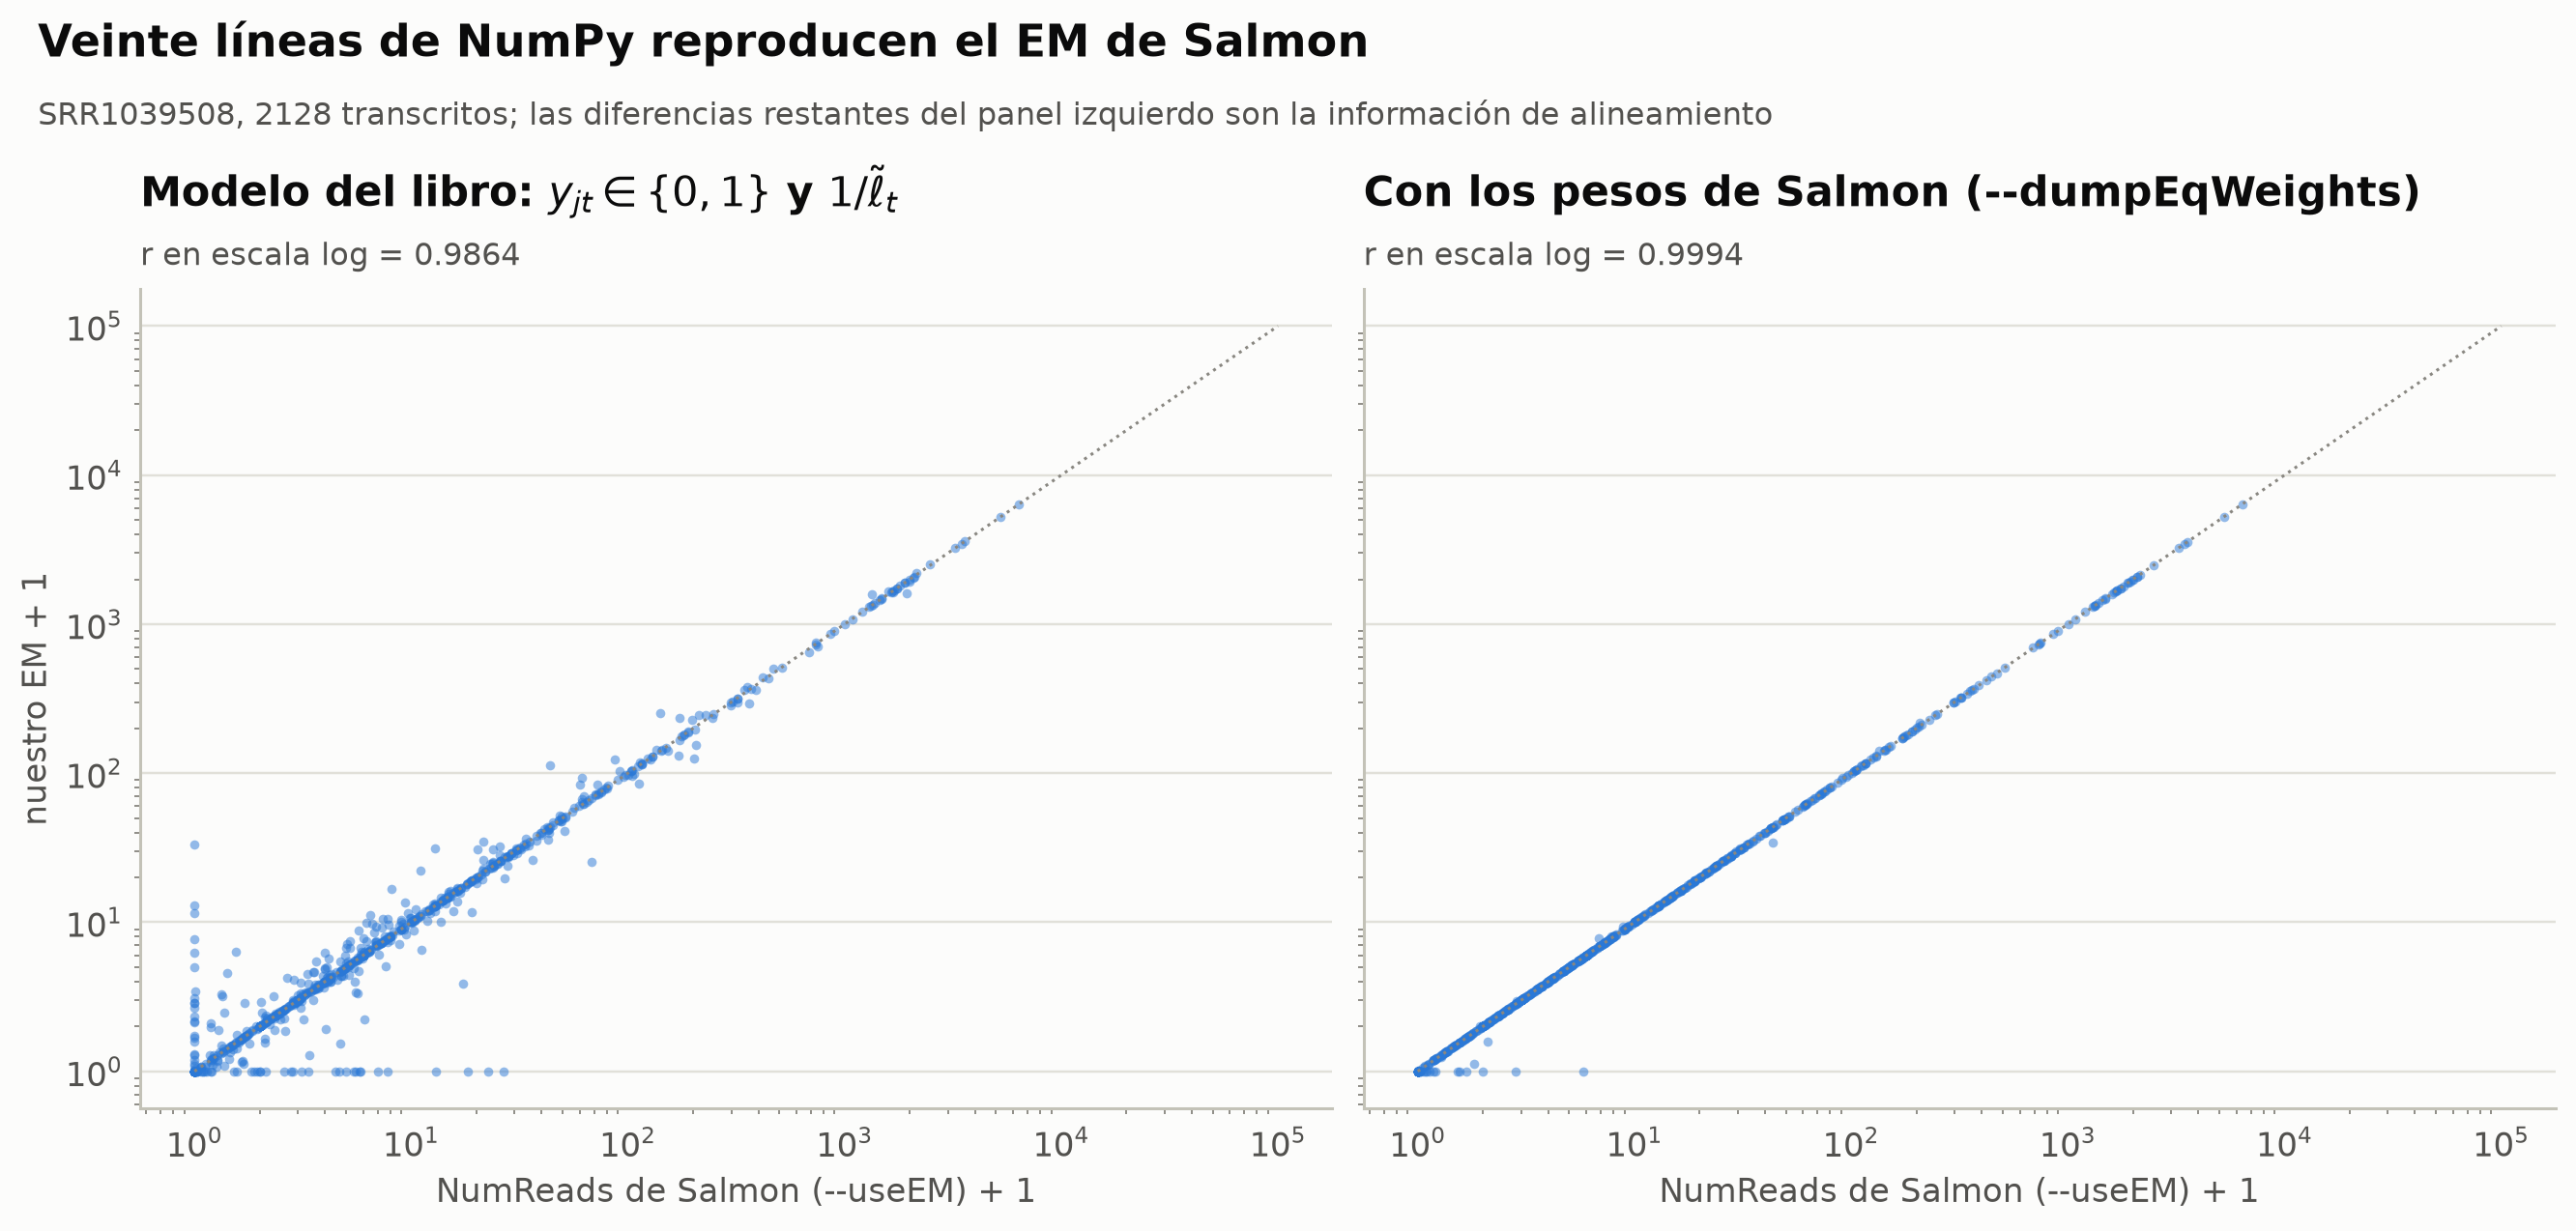

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, o, lab in [(axes[0], ours_book, r"Modelo del libro: $y_{jt}\in\{0,1\}$ y $1/\tilde\ell_t$"),
                   (axes[1], ours_w, "Con los pesos de Salmon (--dumpEqWeights)")]:
    ax.scatter(qs.NumReads + 1, o + 1, s=10, color=ec.BLUE, alpha=0.5, lw=0)
    ax.plot([1, 1e5], [1, 1e5], color=ec.MUTED, ls=":", lw=1)
    ax.set_xscale("log"); ax.set_yscale("log")
    r = np.corrcoef(np.log1p(o), np.log1p(qs.NumReads))[0, 1]
    ax.set_xlabel("NumReads de Salmon (--useEM) + 1")
    ec.title(ax, lab, f"r en escala log = {r:.4f}")
axes[0].set_ylabel("nuestro EM + 1")
ec.fig_title(fig, "Veinte líneas de NumPy reproducen el EM de Salmon",
             "SRR1039508, 2128 transcritos; las diferencias restantes del panel izquierdo son la información de alineamiento")
plt.show()

> 🔎 **Qué observamos.** Con el modelo del libro (sólo compatibilidad y $1/\tilde\ell_t$) ya coincidimos casi
> perfectamente a nivel de transcrito (r ≈ 0,99); las diferencias están en isoformas casi idénticas, donde Salmon usa
> además **cuán bien** alinea cada lectura y si la longitud del fragmento es plausible en cada isoforma. Al usar sus
> pesos, nuestro EM y el de Salmon son prácticamente el mismo cálculo. No hay magia en Salmon: hay un buen modelo y
> mucha ingeniería.

> ✅ **Compruebe su comprensión.** Salmon usa por defecto **VBEM** (Bayes variacional) en lugar de EM. Con un *prior*
> pequeño por nucleótido, ¿en qué transcritos esperaría las mayores diferencias entre ambos? *(Respuesta: en los de
> muy pocas lecturas y en los grupos de isoformas indistinguibles, donde la verosimilitud es plana y el prior decide;
> VBEM tiende a dar cero a las isoformas sin evidencia propia en lugar de repartir un poco a cada una.)*

#### Opcional (sólo Colab): descargar usted mismo las lecturas de ENA

La celda siguiente descarga por *streaming* los primeros pares de SRR1039508/09 directamente de ENA (unos 25 MB
comprimidos por archivo), reanudando la conexión si se corta. Cámbiela a `STREAM_ENA = True` si quiere repetir el
análisis con todas las lecturas (no sólo las preseleccionadas); tarda 1–2 minutos más.

In [34]:
STREAM_ENA = False
ENA = "https://ftp.sra.ebi.ac.uk/vol1/fastq/SRR103/{sub}/{run}/{run}_{r}.fastq.gz"

def stream_fastq_head(url, n_reads, out, chunk=1 << 20):
    """Descomprime al vuelo el inicio de un FASTQ.gz remoto y guarda las primeras n_reads lecturas (reanuda si se corta)."""
    import zlib
    dec, got, buf, offset, lines_out = zlib.decompressobj(16 + zlib.MAX_WBITS), 0, b"", 0, 0
    with gzip.open(out, "wt") as fo:
        while lines_out < 4 * n_reads:
            try:
                req = urllib.request.Request(url, headers={"Range": f"bytes={offset}-"})
                with urllib.request.urlopen(req, timeout=60) as resp:
                    while lines_out < 4 * n_reads:
                        raw = resp.read(chunk)
                        if not raw:
                            return
                        offset += len(raw)
                        buf += dec.decompress(raw)
                        *lines, buf = buf.split(b"\n")
                        take = lines[:4 * n_reads - lines_out]
                        fo.write("\n".join(l.decode() for l in take) + "\n")
                        lines_out += len(take)
            except Exception as err:                       # ENA corta conexiones largas: reanudamos
                print("reintento tras:", err); time.sleep(3)

if STREAM_ENA:
    for run_id in RUNS:
        for r in (1, 2):
            url = ENA.format(sub="0" + run_id[-2:], run=run_id, r=r)
            stream_fastq_head(url, 500_000, f"{WORK}/{run_id}_head_{r}.fastq.gz")
        READS[run_id] = (f"{WORK}/{run_id}_head_1.fastq.gz", f"{WORK}/{run_id}_head_2.fastq.gz")
    print("Lecturas descargadas; vuelva a ejecutar las celdas de Salmon de esta sección.")
else:
    print("Usando las lecturas preseleccionadas del repositorio (STREAM_ENA = False).")

Usando las lecturas preseleccionadas del repositorio (STREAM_ENA = False).


## 9. Unidades: RPKM, TPM y conteos

El archivo `quant.sf` ofrece dos columnas de abundancia que conviene no confundir. **NumReads** es el número
**esperado** de fragmentos asignados al transcrito, $N\hat\alpha_t$; no es entero porque procede de repartos
fraccionarios. **TPM** es una estimación de la fracción molar $\hat\tau_t$ multiplicada por un millón. Para comparar
genes de distinta longitud dentro de una muestra, Mortazavi *et al.* (2008) propusieron dividir el conteo por la
longitud en kilobases y por el total de lecturas en millones: las **lecturas por kilobase por millón** (RPKM, o FPKM
si se cuentan fragmentos pareados). TPM invierte el orden de las operaciones (ecuación 11.7):

$$
\mathrm{RPKM}_t=\frac{c_t}{\left(\tilde\ell_t/10^3\right)\left(N/10^6\right)},\qquad
\mathrm{TPM}_t=10^6\,\frac{c_t/\tilde\ell_t}{\sum_u c_u/\tilde\ell_u}.
$$

| Símbolo | Significado |
|---|---|
| $c_t$ | fragmentos asignados al transcrito (o gen) $t$ |
| $N$ | fragmentos totales de la muestra, $\sum_u c_u$ |
| $\tilde\ell_t$ | longitud efectiva (en la práctica, a veces la longitud sin corregir) |

La diferencia parece cosmética, pero no lo es. Los TPM de una muestra suman siempre $10^6$ y, por la ecuación 11.2,
estiman directamente $10^6\,\tau_t$. Los RPKM suman $10^9/\bar\ell$, donde $\bar\ell$ es la longitud media (armónica), ponderada
por fragmentos, de lo que se expresa en esa muestra, y esa media cambia de una muestra a otra. Wagner, Kin y Lynch
(2012) mostraron que por eso **los RPKM no son consistentes entre muestras** y recomendaron TPM.

### El ejemplo del libro: el mismo gen, dos unidades, dos historias

Dos muestras expresan cuatro genes de longitudes 1, 2, 4 y 0,5 kb y se secuencian a 10 millones de fragmentos. En A
los cuatro tienen el mismo número de moléculas; en B el gen 4 (el corto) tiene **cuatro veces más** moléculas y los
otros tres no cambian en números absolutos. Los fragmentos se reparten en proporción a moléculas × longitud.

> 🤔 **Antes de ejecutar, prediga.** En B, ¿el RPKM del gen 1 sube, baja o queda igual? ¿Y su TPM? ¿Cuál de los dos
> refleja que la **proporción** de moléculas del gen 1 cayó de 1/4 a 1/7?

In [35]:
glen = np.array([1.0, 2.0, 4.0, 0.5])                       # kb
molA = np.array([10, 10, 10, 10.0]); molB = np.array([10, 10, 10, 40.0])
def frags(mol, total=10e6):
    x = mol * glen
    return x / x.sum() * total
def rpkm(c, l_kb):
    return c / (l_kb * c.sum() / 1e6)
def tpm(c, l):
    x = c / l
    return x / x.sum() * 1e6
readsA, readsB = frags(molA), frags(molB)
RA, RB, TA, TB = rpkm(readsA, glen), rpkm(readsB, glen), tpm(readsA, glen), tpm(readsB, glen)
ex = pd.DataFrame({"frag. A (M)": readsA / 1e6, "frag. B (M)": readsB / 1e6, "RPKM A": RA, "RPKM B": RB,
                   "TPM A": TA, "TPM B": TB}, index=["gen 1 (1 kb)", "gen 2 (2 kb)", "gen 3 (4 kb)", "gen 4 (0,5 kb)"])
ex.loc["suma"] = ex.sum()
print(ex.round(2).to_string())
frac_B = molB[0] / molB.sum()
print(f"\nFracción real de moléculas del gen 1 en B = 10/70 = {frac_B:.3f} → TPM/10⁶ = {TB[0]/1e6:.3f}")
print(f"El RPKM del gen 1 cae {100*(1 - RB[0]/RA[0]):.0f} %; su fracción molar cae {100*(1 - frac_B/0.25):.0f} %")
assert np.allclose(np.round(readsA), [1333333, 2666667, 5333333, 666667]) and np.allclose(np.round(readsB), [1111111, 2222222, 4444444, 2222222])
assert round(RA.sum()) == 533333 and round(RB.sum()) == 777778 and round(RB[0]) == 111111 and round(RB[3]) == 444444
assert np.allclose(np.round(TB), [142857, 142857, 142857, 571429]) and np.allclose(TA, 250000)
print("✔ cifras del ejemplo del libro reproducidas")

                frag. A (M)  frag. B (M)     RPKM A     RPKM B      TPM A       TPM B
gen 1 (1 kb)           1.33         1.11  133333.33  111111.11   250000.0   142857.14
gen 2 (2 kb)           2.67         2.22  133333.33  111111.11   250000.0   142857.14
gen 3 (4 kb)           5.33         4.44  133333.33  111111.11   250000.0   142857.14
gen 4 (0,5 kb)         0.67         2.22  133333.33  444444.44   250000.0   571428.57
suma                  10.00        10.00  533333.33  777777.78  1000000.0  1000000.00

Fracción real de moléculas del gen 1 en B = 10/70 = 0.143 → TPM/10⁶ = 0.143
El RPKM del gen 1 cae 17 %; su fracción molar cae 43 %
✔ cifras del ejemplo del libro reproducidas


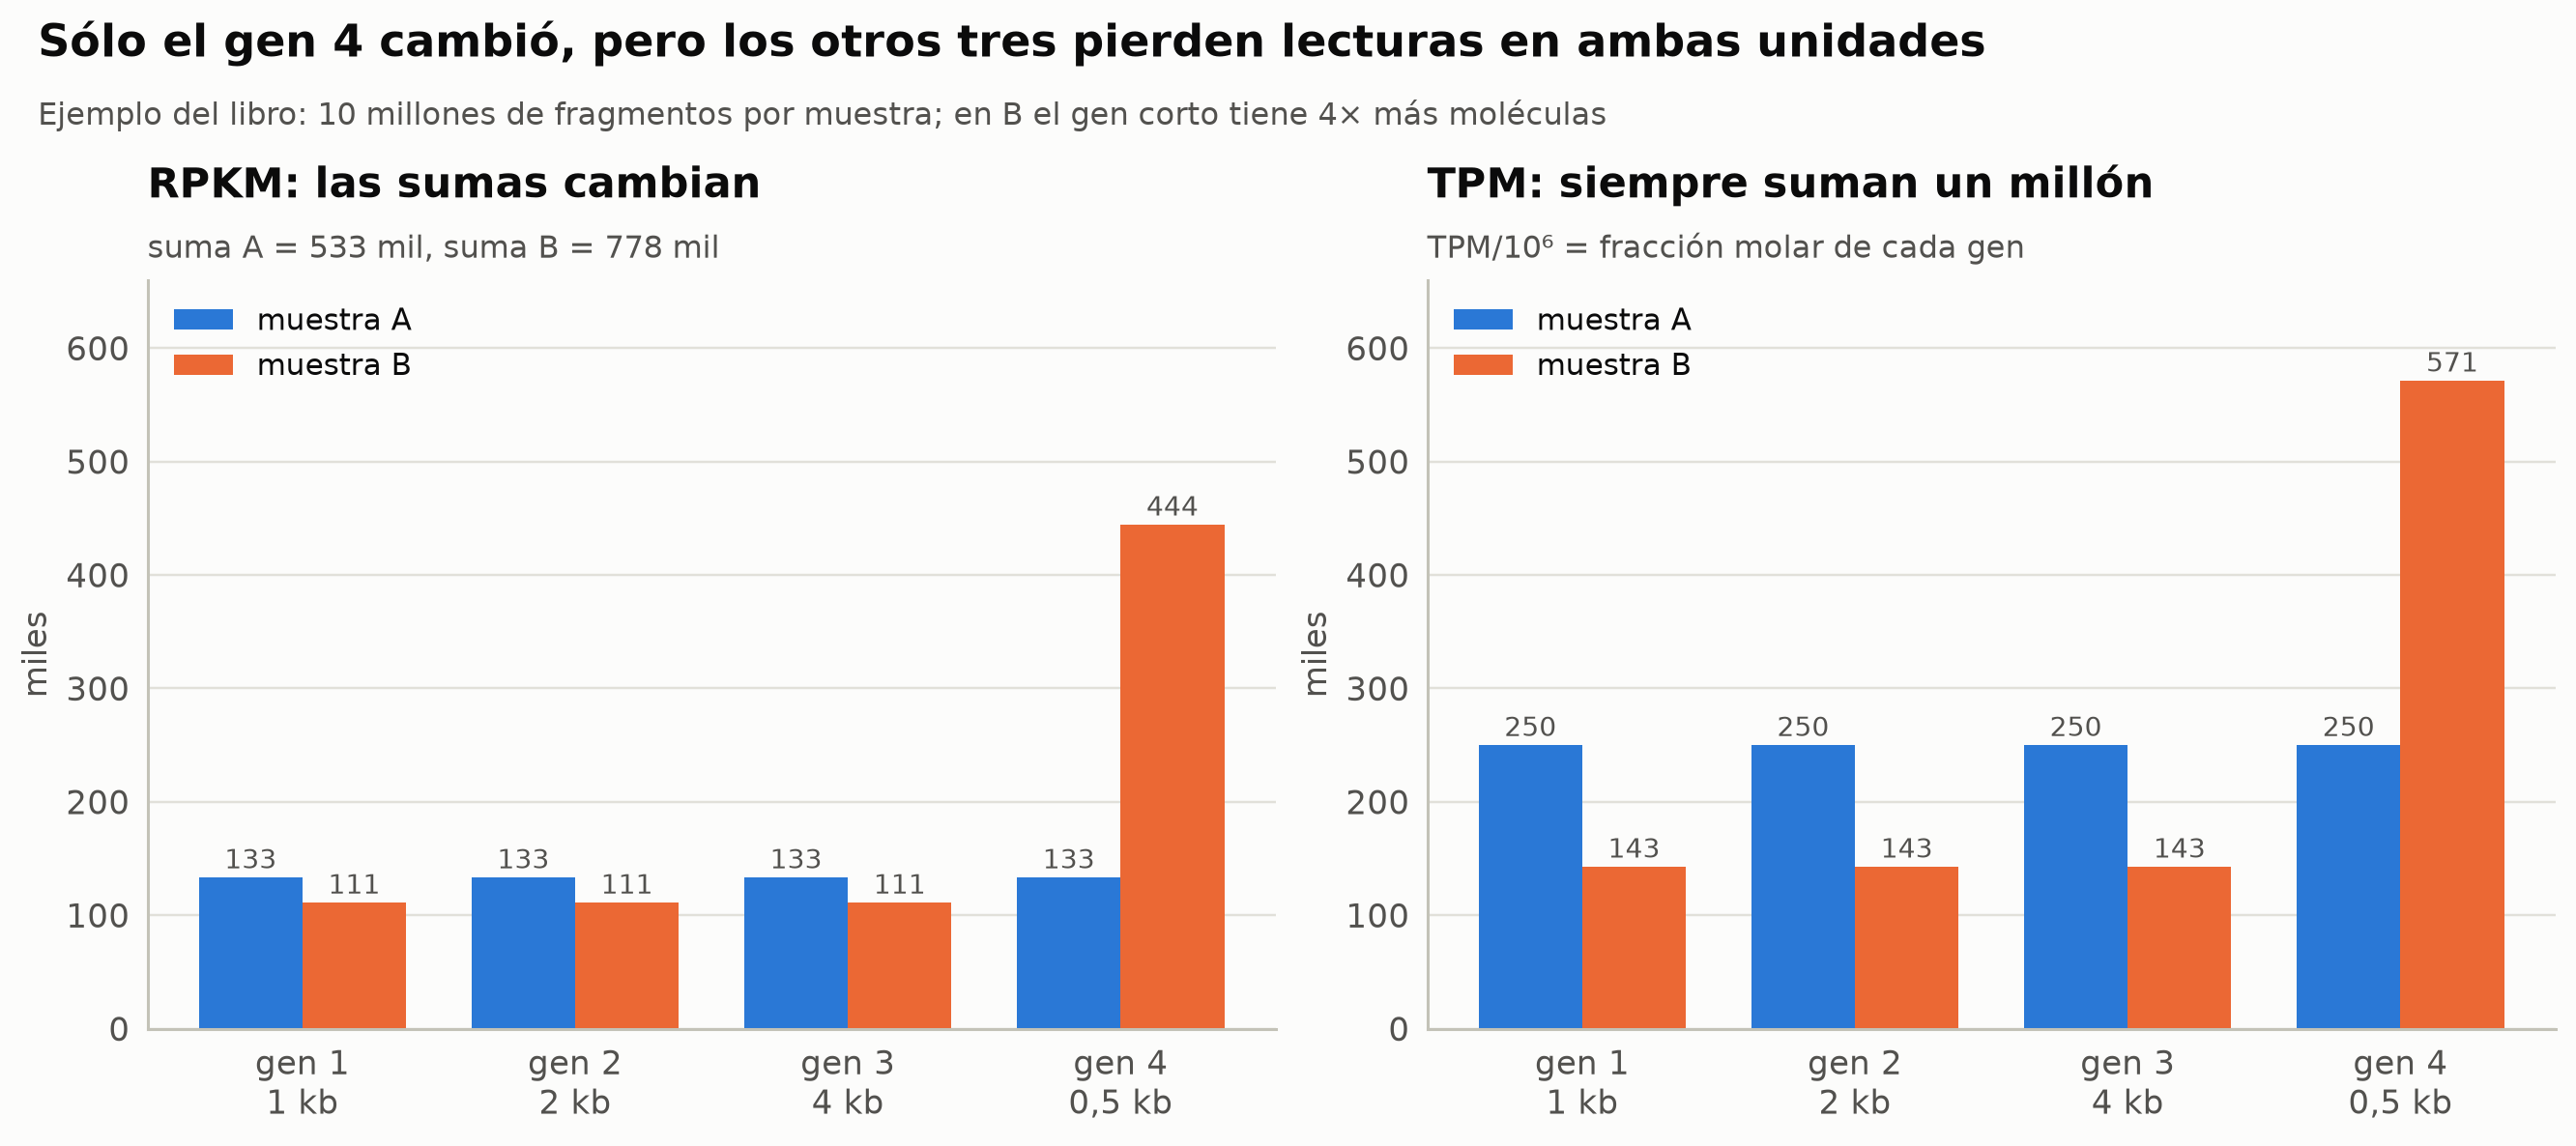

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
x = np.arange(4); w = 0.38
for ax, (vA, vB), ttl, sub in [(axes[0], (RA / 1e3, RB / 1e3), "RPKM: las sumas cambian", f"suma A = {RA.sum()/1e3:.0f} mil, suma B = {RB.sum()/1e3:.0f} mil"),
                               (axes[1], (TA / 1e3, TB / 1e3), "TPM: siempre suman un millón", "TPM/10⁶ = fracción molar de cada gen")]:
    ax.bar(x - w / 2, vA, w, color=ec.BLUE, label="muestra A")
    ax.bar(x + w / 2, vB, w, color=ec.ORANGE, label="muestra B")
    for i in range(4):
        ax.text(i - w / 2, vA[i] + 8, f"{vA[i]:.0f}", ha="center", fontsize=9, color=ec.INK_2)
        ax.text(i + w / 2, vB[i] + 8, f"{vB[i]:.0f}", ha="center", fontsize=9, color=ec.INK_2)
    ax.set_xticks(x, ["gen 1\n1 kb", "gen 2\n2 kb", "gen 3\n4 kb", "gen 4\n0,5 kb"])
    ax.set_ylabel("miles"); ax.set_ylim(0, 660)
    ax.legend(loc="upper left", frameon=False)
    ec.title(ax, ttl, sub)
ec.fig_title(fig, "Sólo el gen 4 cambió, pero los otros tres pierden lecturas en ambas unidades",
             "Ejemplo del libro: 10 millones de fragmentos por muestra; en B el gen corto tiene 4× más moléculas")
plt.show()

> 🔎 **Qué observamos.** El TPM del gen 1 en B (142 857) es exactamente su fracción molar, 1/7. Su RPKM sugiere una
> caída del 17 % cuando la proporción de moléculas cayó un 43 %: los RPKM de cada muestra suman cantidades distintas
> (533 mil frente a 778 mil) y no pueden leerse como proporciones. Pero ojo: **ninguna** de las dos unidades distingue
> «el gen 1 bajó» de «el gen 4 subió». Ese problema de **composición** es el tema de la Lección 11.2.

Mueva el deslizador para cambiar cuántas veces más moléculas tiene el gen 4 en B y observe cómo se separan las dos
unidades.

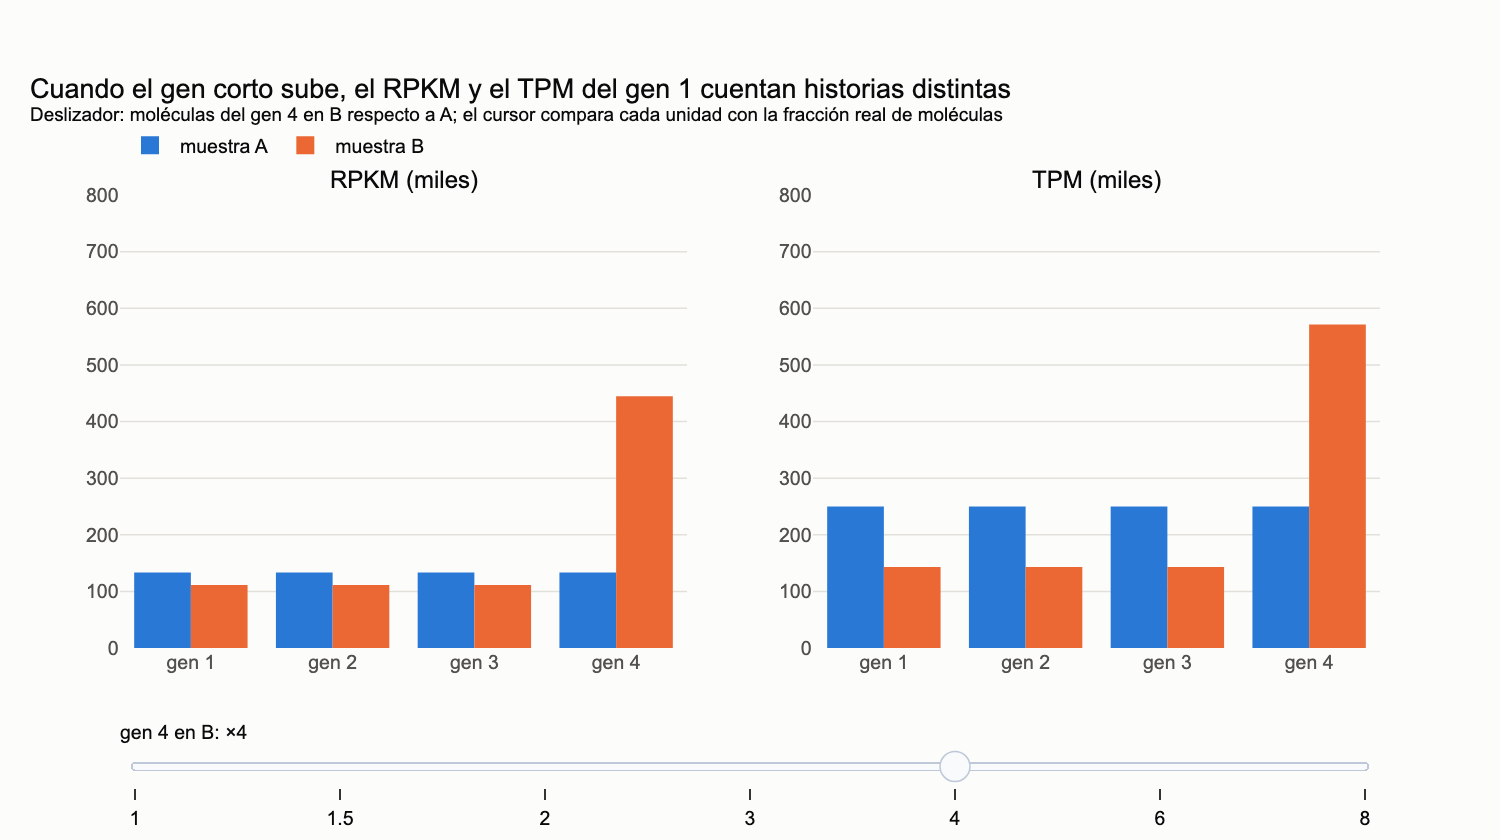

In [37]:
factors = [1, 1.5, 2, 3, 4, 6, 8]
def unit_traces(f):
    mB = np.array([10, 10, 10, 10.0 * f]); cB = frags(mB)
    rB, tB = rpkm(cB, glen), tpm(cB, glen)
    true_frac = mB / mB.sum()
    hover_r = [f"gen {i+1}<br>RPKM B = {rB[i]:,.0f} (A = {RA[i]:,.0f})<br>suma RPKM B = {rB.sum():,.0f}"
               f"<br>fracción real de moléculas = {true_frac[i]:.3f}" for i in range(4)]
    hover_t = [f"gen {i+1}<br>TPM B = {tB[i]:,.0f} (A = {TA[i]:,.0f})<br>TPM/10⁶ = {tB[i]/1e6:.3f}"
               f"<br>fracción real de moléculas = {true_frac[i]:.3f} ✔" for i in range(4)]
    genes = ["gen 1", "gen 2", "gen 3", "gen 4"]
    return [go.Bar(x=genes, y=RA / 1e3, marker_color=ec.BLUE, name="muestra A", legendgroup="A", hoverinfo="skip"),
            go.Bar(x=genes, y=rB / 1e3, marker_color=ec.ORANGE, name="muestra B", legendgroup="B",
                   hovertext=hover_r, hoverinfo="text"),
            go.Bar(x=genes, y=TA / 1e3, marker_color=ec.BLUE, showlegend=False, legendgroup="A", hoverinfo="skip"),
            go.Bar(x=genes, y=tB / 1e3, marker_color=ec.ORANGE, showlegend=False, legendgroup="B",
                   hovertext=hover_t, hoverinfo="text")]
fig = make_subplots(rows=1, cols=2, subplot_titles=("RPKM (miles)", "TPM (miles)"))
for i, tr in enumerate(unit_traces(4)):
    fig.add_trace(tr, row=1, col=1 if i < 2 else 2)
fig.frames = [go.Frame(data=unit_traces(f), name=str(f), traces=[0, 1, 2, 3]) for f in factors]
fig.update_layout(
    title="Cuando el gen corto sube, el RPKM y el TPM del gen 1 cuentan historias distintas<br><sup>Deslizador: "
          "moléculas del gen 4 en B respecto a A; el cursor compara cada unidad con la fracción real de moléculas</sup>",
    barmode="group", height=560, margin=dict(t=130, b=110),
    legend=dict(orientation="h", yanchor="bottom", y=1.06, x=0),
    yaxis=dict(range=[0, 800]), yaxis2=dict(range=[0, 800]),
    sliders=[dict(active=factors.index(4), y=-0.08, currentvalue=dict(prefix="gen 4 en B: ×"),
                  steps=[dict(label=str(f), method="animate",
                              args=[[str(f)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
                         for f in factors])])
fig.show()

### Las unidades con datos reales

Calculemos RPKM y TPM a partir de los `NumReads` y `EffectiveLength` de Salmon (índice con señuelos) y comprobemos
las dos afirmaciones: el TPM que reporta Salmon es exactamente la ecuación 11.7, y las sumas de RPKM difieren entre
muestras.

In [38]:
quant = {}
for run_id in RUNS:
    qq = pd.read_csv(f"{qdir[('dec', run_id)]}/quant.sf", sep="\t", index_col=0)
    qq["TPM_ours"] = tpm(qq.NumReads.values, qq.EffectiveLength.values)
    qq["RPKM"] = rpkm(qq.NumReads.values, qq.EffectiveLength.values / 1e3)
    qq = qq.join(tx2gene.set_index("transcript_id")[["gene_id", "symbol", "transcript_name", "group"]])
    quant[run_id] = qq
    lbar = qq.NumReads.sum() / (qq.NumReads / qq.EffectiveLength).sum()   # media armónica ponderada por fragmentos
    print(f"{run_id} ({RUNS[run_id]}): máx |TPM Salmon − ecuación| = {(qq.TPM - qq.TPM_ours).abs().max():.3f}; "
          f"suma TPM = {qq.TPM.sum():,.0f}; suma RPKM = {qq.RPKM.sum():,.0f} "
          f"= 10⁹/ℓ̄ con ℓ̄ = {lbar:,.0f} nt")

SRR1039508 (sin tratar): máx |TPM Salmon − ecuación| = 0.040; suma TPM = 1,000,000; suma RPKM = 509,167 = 10⁹/ℓ̄ con ℓ̄ = 1,964 nt
SRR1039509 (dexametasona): máx |TPM Salmon − ecuación| = 0.068; suma TPM = 1,000,000; suma RPKM = 515,306 = 10⁹/ℓ̄ con ℓ̄ = 1,941 nt


> 🔎 **Qué observamos.** Nuestro TPM coincide con el de Salmon hasta el redondeo, y la suma de RPKM es exactamente
> $10^9/\bar\ell$, distinta en cada muestra. Hay otra lección escondida: estos TPM suman un millón **sobre nuestros
> 250 genes**, no sobre el transcriptoma entero. **Un TPM sólo tiene sentido respecto al universo de transcritos del
> índice.** Comparemos los genes de respuesta a glucocorticoides con los TPM del índice completo.

In [39]:
dex_genes = ["FKBP5", "TSC22D3", "ZBTB16", "PER1", "KLF15", "DUSP1", "GLUL", "CRISPLD2", "SAMHD1", "CXCL12"]
def gene_tpm(tpm_series):
    return tpm_series.groupby(sym.reindex(tpm_series.index).values).sum()
rows = []
for gname in dex_genes:
    r = {"gen": gname}
    for run_id in RUNS:
        r[f"TPM reducido {run_id[-2:]}"] = gene_tpm(quant[run_id].TPM).get(gname, 0)
        r[f"TPM completo {run_id[-2:]}"] = gene_tpm(full_tx[f"TPM_{run_id}"]).get(gname, 0)
        r[f"frag. {run_id[-2:]}"] = quant[run_id].groupby("symbol").NumReads.sum().get(gname, 0)
    r["log2 FC (frag.)"] = np.log2((r["frag. 09"] + 1) / (r["frag. 08"] + 1))
    rows.append(r)
dex_tab = pd.DataFrame(rows).set_index("gen")
print(dex_tab.round(1).to_string())

          TPM reducido 08  TPM completo 08  frag. 08  TPM reducido 09  TPM completo 09  frag. 09  log2 FC (frag.)
gen                                                                                                              
FKBP5                34.9              4.6       6.8            620.9             86.6     103.0              3.7
TSC22D3              57.3              8.8       5.0           1462.6            209.7     103.0              4.1
ZBTB16                0.0              0.0       0.0            134.9             19.4      14.0              3.9
PER1                129.1             19.9       3.0            209.0             30.0      41.0              3.4
KLF15                17.7              2.7       2.0            432.9             62.1      34.0              3.5
DUSP1                92.1             14.2       8.0           1298.3            186.3     106.0              3.6
GLUL               1759.6            271.3     115.0          15417.6           2209.0  

> 🔎 **Qué observamos.** Los TPM del índice reducido son unas 7 veces más grandes que los del índice completo (el millón
> se reparte entre muchos menos transcritos), pero el **cociente** entre muestras se conserva. Y la biología aparece ya
> con 500 000 pares de un solo donante: *FKBP5*, *TSC22D3* (GILZ), *ZBTB16*, *PER1*, *KLF15* y *DUSP1*, genes diana
> clásicos del receptor de glucocorticoides, suben varias veces con dexametasona, mientras *CXCL12* (una quimiocina)
> baja. Con un solo par de muestras no podemos decir nada estadístico: eso llega en la Lección 11.3 con los cuatro
> donantes.

### Isoformas: ¿cambia *TSC22D3* entera o sólo alguna de sus isoformas?

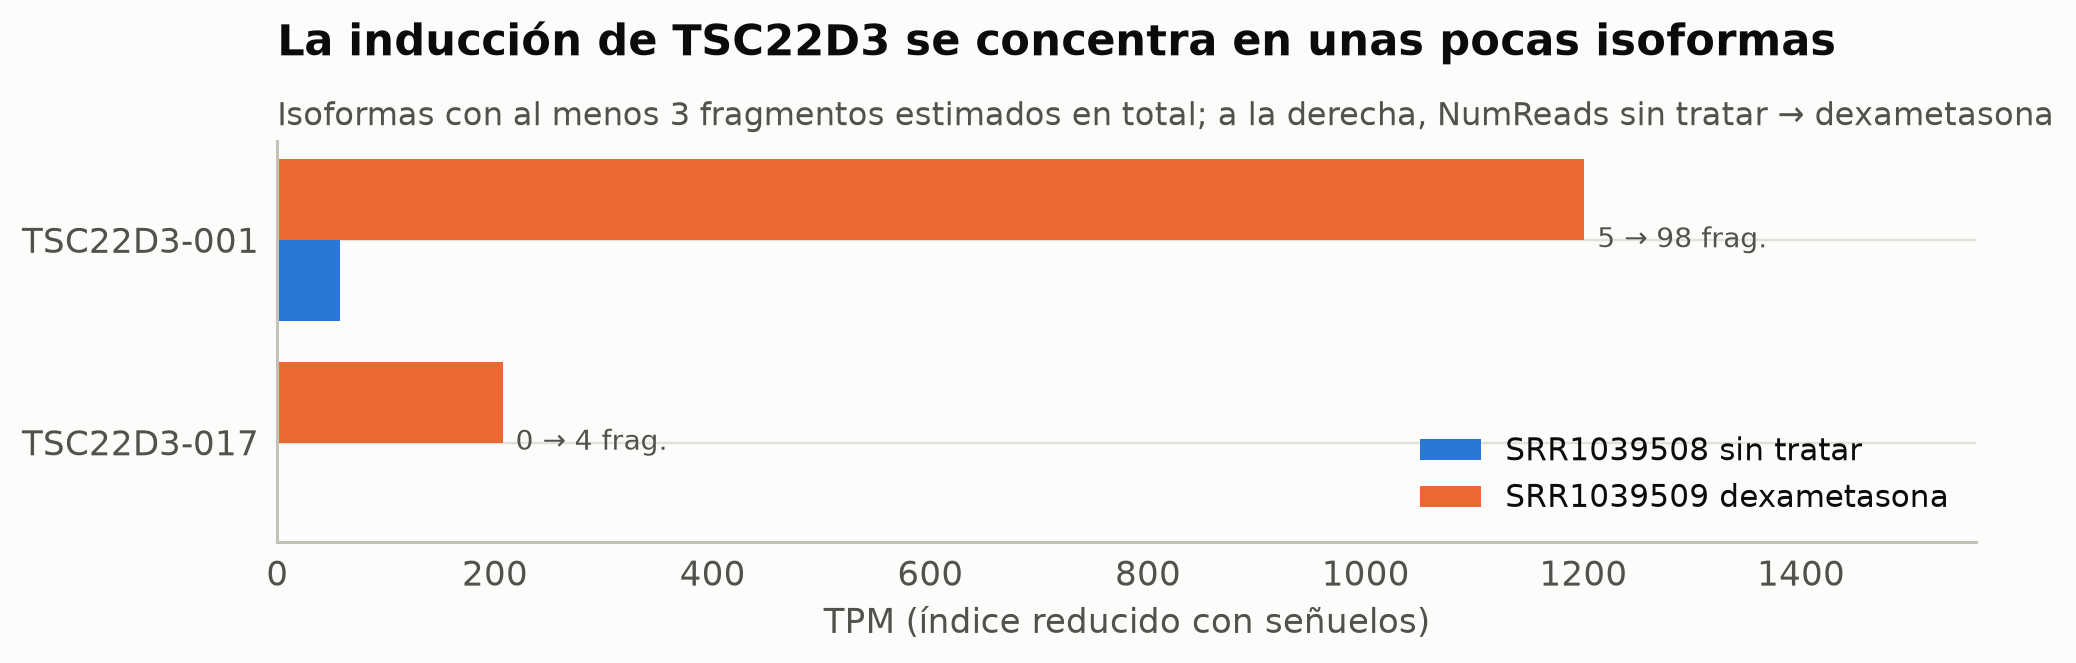

In [40]:
iso_tab = pd.DataFrame({run_id: quant[run_id].query("symbol == 'TSC22D3'").set_index("transcript_name").TPM
                        for run_id in RUNS})
iso_tab["frag08"] = quant["SRR1039508"].query("symbol == 'TSC22D3'").set_index("transcript_name").NumReads
iso_tab["frag09"] = quant["SRR1039509"].query("symbol == 'TSC22D3'").set_index("transcript_name").NumReads
iso_tab = iso_tab[(iso_tab.frag08 + iso_tab.frag09) > 2].sort_values("SRR1039509")
fig, ax = plt.subplots(figsize=(9.5, 0.45 * len(iso_tab) + 2))
y = np.arange(len(iso_tab))
ax.barh(y - 0.2, iso_tab.SRR1039508, 0.4, color=ec.BLUE, label="SRR1039508 sin tratar")
ax.barh(y + 0.2, iso_tab.SRR1039509, 0.4, color=ec.ORANGE, label="SRR1039509 dexametasona")
for i, (n, r) in enumerate(iso_tab.iterrows()):
    ax.text(max(r.SRR1039508, r.SRR1039509) + iso_tab.values[:, :2].max() * 0.01, i,
            f"{r.frag08:.0f} → {r.frag09:.0f} frag.", va="center", fontsize=9, color=ec.INK_2)
ax.set_yticks(y, iso_tab.index)
ax.set_xlim(0, iso_tab.values[:, :2].max() * 1.3)
ax.set_xlabel("TPM (índice reducido con señuelos)")
ax.legend(loc="lower right", frameon=False)
ec.title(ax, "La inducción de TSC22D3 se concentra en unas pocas isoformas",
         "Isoformas con al menos 3 fragmentos estimados en total; a la derecha, NumReads sin tratar → dexametasona")
plt.show()

> 🔎 **Qué observamos.** Unas pocas isoformas concentran casi toda la señal y la inducción. Con tan pocas lecturas las
> estimaciones de isoformas cercanas son frágiles (recuerde la dispersión de la simulación de la sección 6): por eso la
> expresión diferencial suele hacerse **a nivel de gen**, que es la siguiente parada.

## 10. Del transcrito al gen: `tximport`

La expresión diferencial suele analizarse a nivel de gen, donde las estimaciones son más estables. Sumar los TPM de
las isoformas de un gen da su fracción molar, pero los métodos de la Lección 11.2 necesitan **conteos**, no TPM.
Soneson, Love y Robinson (2015) mostraron que la forma correcta no es contar lecturas por gen sobre un alineamiento,
sino **sumar los conteos estimados** por transcrito y, además, calcular para cada gen $g$ y muestra $i$ una **longitud
efectiva media** ponderada por la abundancia de sus isoformas:

$$
c_{gi} = \sum_{t\in g} \hat c_{ti},\qquad
\bar\ell_{gi} = \frac{\sum_{t\in g} \mathrm{TPM}_{ti}\,\tilde\ell_{ti}}{\sum_{t\in g}\mathrm{TPM}_{ti}} .
$$

| Símbolo | Significado |
|---|---|
| $\hat c_{ti}$ | conteo estimado (NumReads) del transcrito $t$ en la muestra $i$ |
| $c_{gi}$ | conteo estimado del gen $g$ |
| $\bar\ell_{gi}$ | longitud efectiva media del gen en esa muestra, ponderada por la abundancia de sus isoformas |

Si una muestra expresa sobre todo la isoforma larga y otra la corta, el gen producirá más fragmentos en la primera
aunque tenga el mismo número de moléculas; $\bar\ell_{gi}$, usada como **desplazamiento** (*offset*) en el modelo de
la Lección 11.2, corrige ese efecto. Es lo que hace el paquete de R `tximport`; en Python bastan unas líneas.

In [41]:
def tximport(qq):
    g = qq.groupby("gene_id")
    counts = g.NumReads.sum()
    abund = g.TPM.sum()
    length = (qq.TPM * qq.EffectiveLength).groupby(qq.gene_id).sum() / abund
    # genes sin expresión: longitud media simple (tximport usa el promedio entre muestras)
    length = length.fillna(g.EffectiveLength.mean())
    return counts, abund, length
txi = {run_id: tximport(quant[run_id]) for run_id in RUNS}
gene_sym = tx2gene.drop_duplicates("gene_id").set_index("gene_id").symbol
gl = pd.DataFrame({"L08": txi["SRR1039508"][2], "L09": txi["SRR1039509"][2],
                   "c08": txi["SRR1039508"][0], "c09": txi["SRR1039509"][0]})
gl["symbol"] = gene_sym.reindex(gl.index).values
gl["log2_len_ratio"] = np.log2(gl.L09 / gl.L08)
ok = gl[(gl.c08 >= 50) & (gl.c09 >= 50)]
print(f"{len(ok)} genes con ≥ 50 fragmentos en ambas muestras; |log2 ℓ̄09/ℓ̄08| > 0,25 en "
      f"{(ok.log2_len_ratio.abs() > 0.25).sum()} de ellos")
print(ok.reindex(ok.log2_len_ratio.abs().sort_values(ascending=False).index).head(8)
      [["symbol", "c08", "c09", "L08", "L09", "log2_len_ratio"]].round(2).to_string(index=False))

67 genes con ≥ 50 fragmentos en ambas muestras; |log2 ℓ̄09/ℓ̄08| > 0,25 en 9 de ellos
 symbol    c08     c09     L08     L09  log2_len_ratio
 IGSF10  219.0   73.00 6787.52 2442.84           -1.47
  MBNL1   92.0  152.00 2679.46 4526.87            0.76
   CD46  101.0   95.00 3200.30 1911.81           -0.74
  MOB1A   56.0   68.00 2972.70 4416.78            0.57
 SEC23A   83.0   89.13 2831.22 2035.07           -0.48
COL14A1  229.0   76.00 6244.13 4846.34           -0.37
   FLNA 1363.0 1569.87 7611.49 6103.83           -0.32
  EEF1D  140.0  120.04  639.88  772.16            0.27


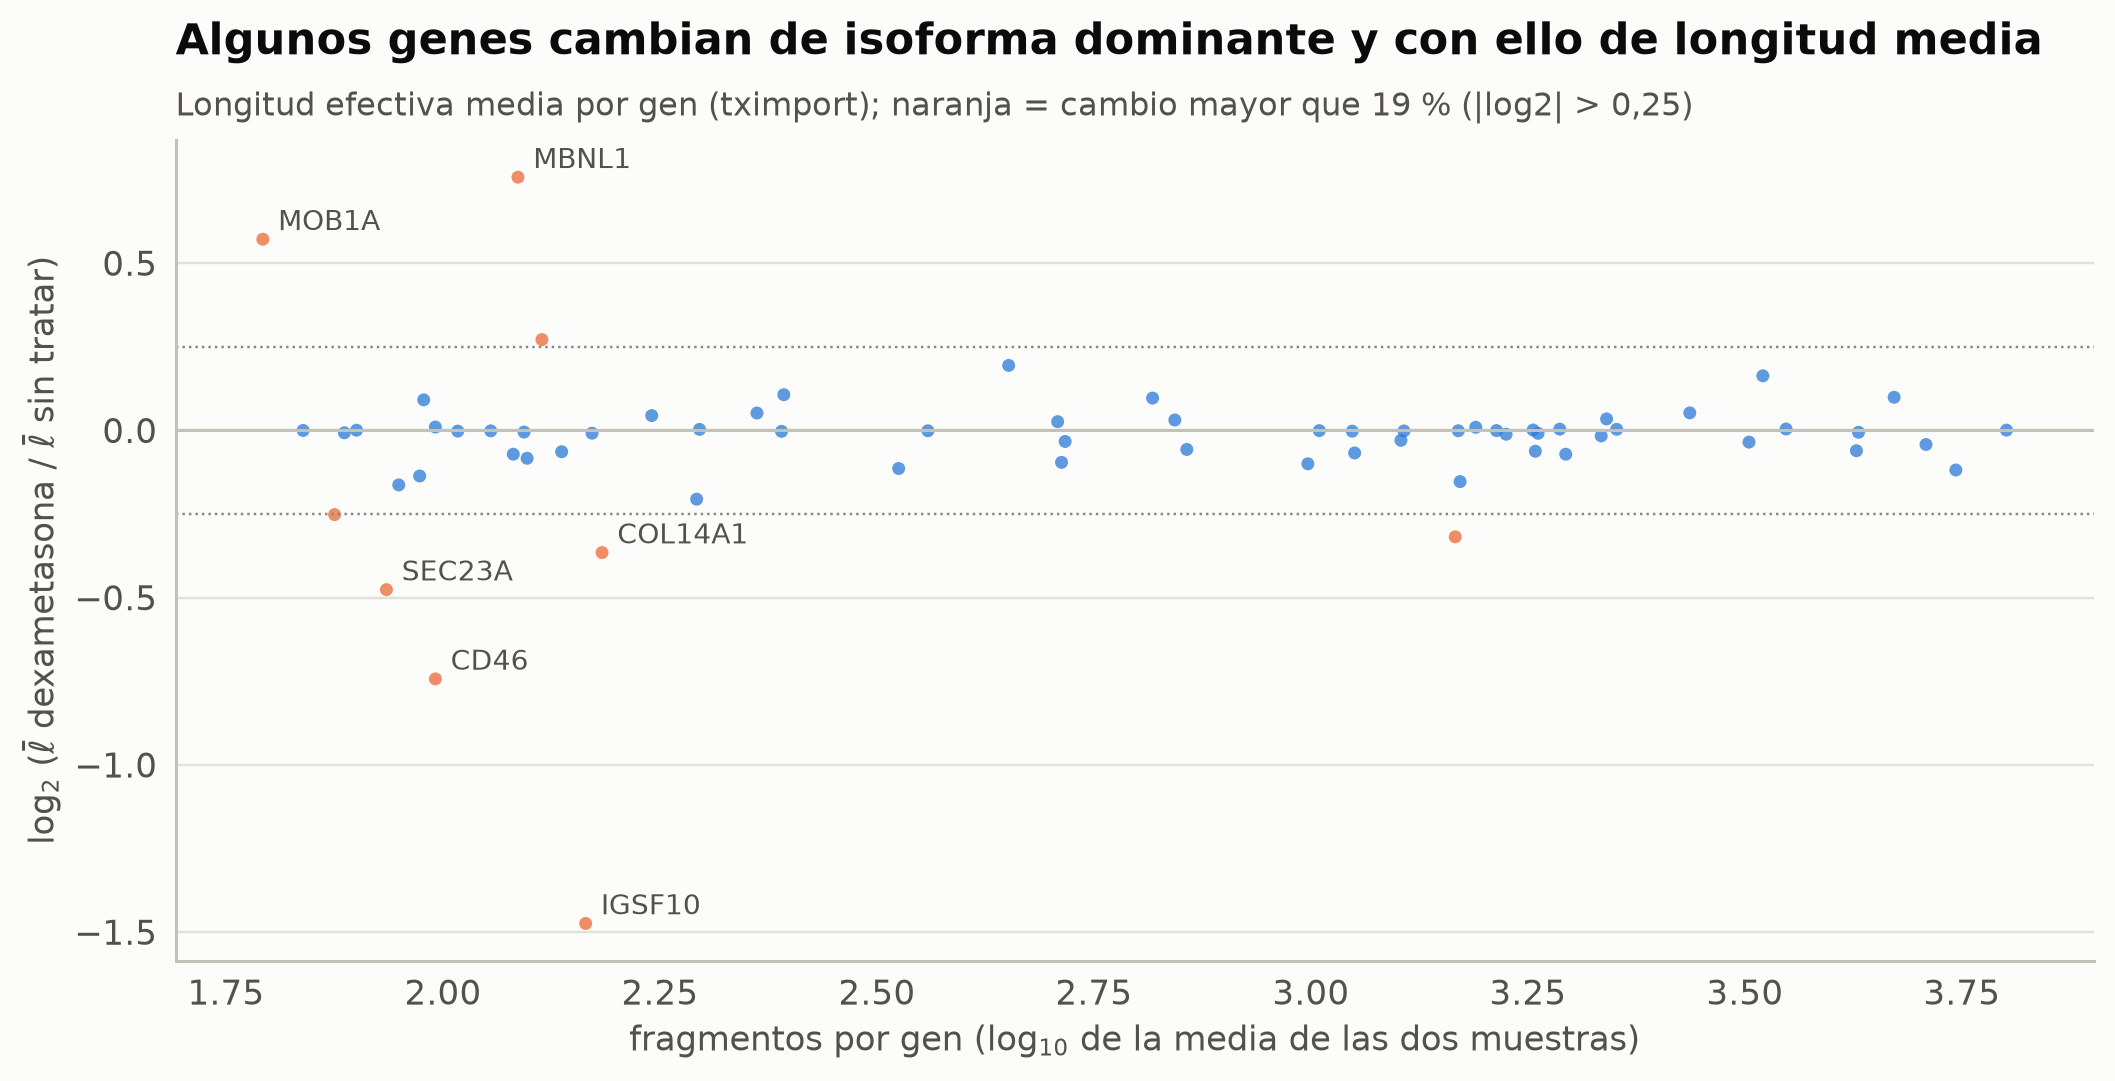

In [42]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
xg = np.log10((ok.c08 + ok.c09) / 2)
colr = np.where(ok.log2_len_ratio.abs() > 0.25, ec.ORANGE, ec.BLUE)
ax.scatter(xg, ok.log2_len_ratio, s=18, c=colr, alpha=0.75, lw=0)
for _, r in ok.reindex(ok.log2_len_ratio.abs().sort_values(ascending=False).index).head(6).iterrows():
    ax.annotate(r.symbol, (np.log10((r.c08 + r.c09) / 2), r.log2_len_ratio), xytext=(5, 3),
                textcoords="offset points", fontsize=9, color=ec.INK_2)
ax.axhline(0, color=ec.BASELINE, lw=1)
for yy in (-0.25, 0.25):
    ax.axhline(yy, color=ec.MUTED, lw=0.8, ls=":")
ax.set_xlabel("fragmentos por gen (log$_{10}$ de la media de las dos muestras)")
ax.set_ylabel(r"log$_2$ ($\bar\ell$ dexametasona / $\bar\ell$ sin tratar)")
ec.title(ax, "Algunos genes cambian de isoforma dominante y con ello de longitud media",
         "Longitud efectiva media por gen (tximport); naranja = cambio mayor que 19 % (|log2| > 0,25)")
plt.show()

> 🔎 **Qué observamos.** La mayoría de los genes conservan su longitud media, pero unos cuantos la cambian bastante.
> Para ellos, comparar conteos sin el desplazamiento de longitud confundiría «cambió la isoforma» con «cambió la
> cantidad de moléculas». (Con 500 000 pares parte de ese cambio es ruido de estimación de isoformas; con la muestra
> completa las longitudes medias son mucho más estables.)

### Comprobación final: nuestros conteos frente a recount3

El proyecto **recount3** (Wilks *et al.*, 2021) reprocesó de forma uniforme cientos de miles de muestras públicas de
RNA-seq, incluida *airway*. Sus conteos por gen (GENCODE v26, los mismos identificadores que usamos) se obtienen
alineando al genoma con STAR (la ruta azul) y dividiendo la **cobertura por base** sumada sobre los exones del gen
entre las **bases por fragmento**, redondeado. Son los que usaremos en las Lecciones 11.2–11.4. ¿Se parecen a lo que
Salmon estimó con sólo el 2 % de las lecturas?

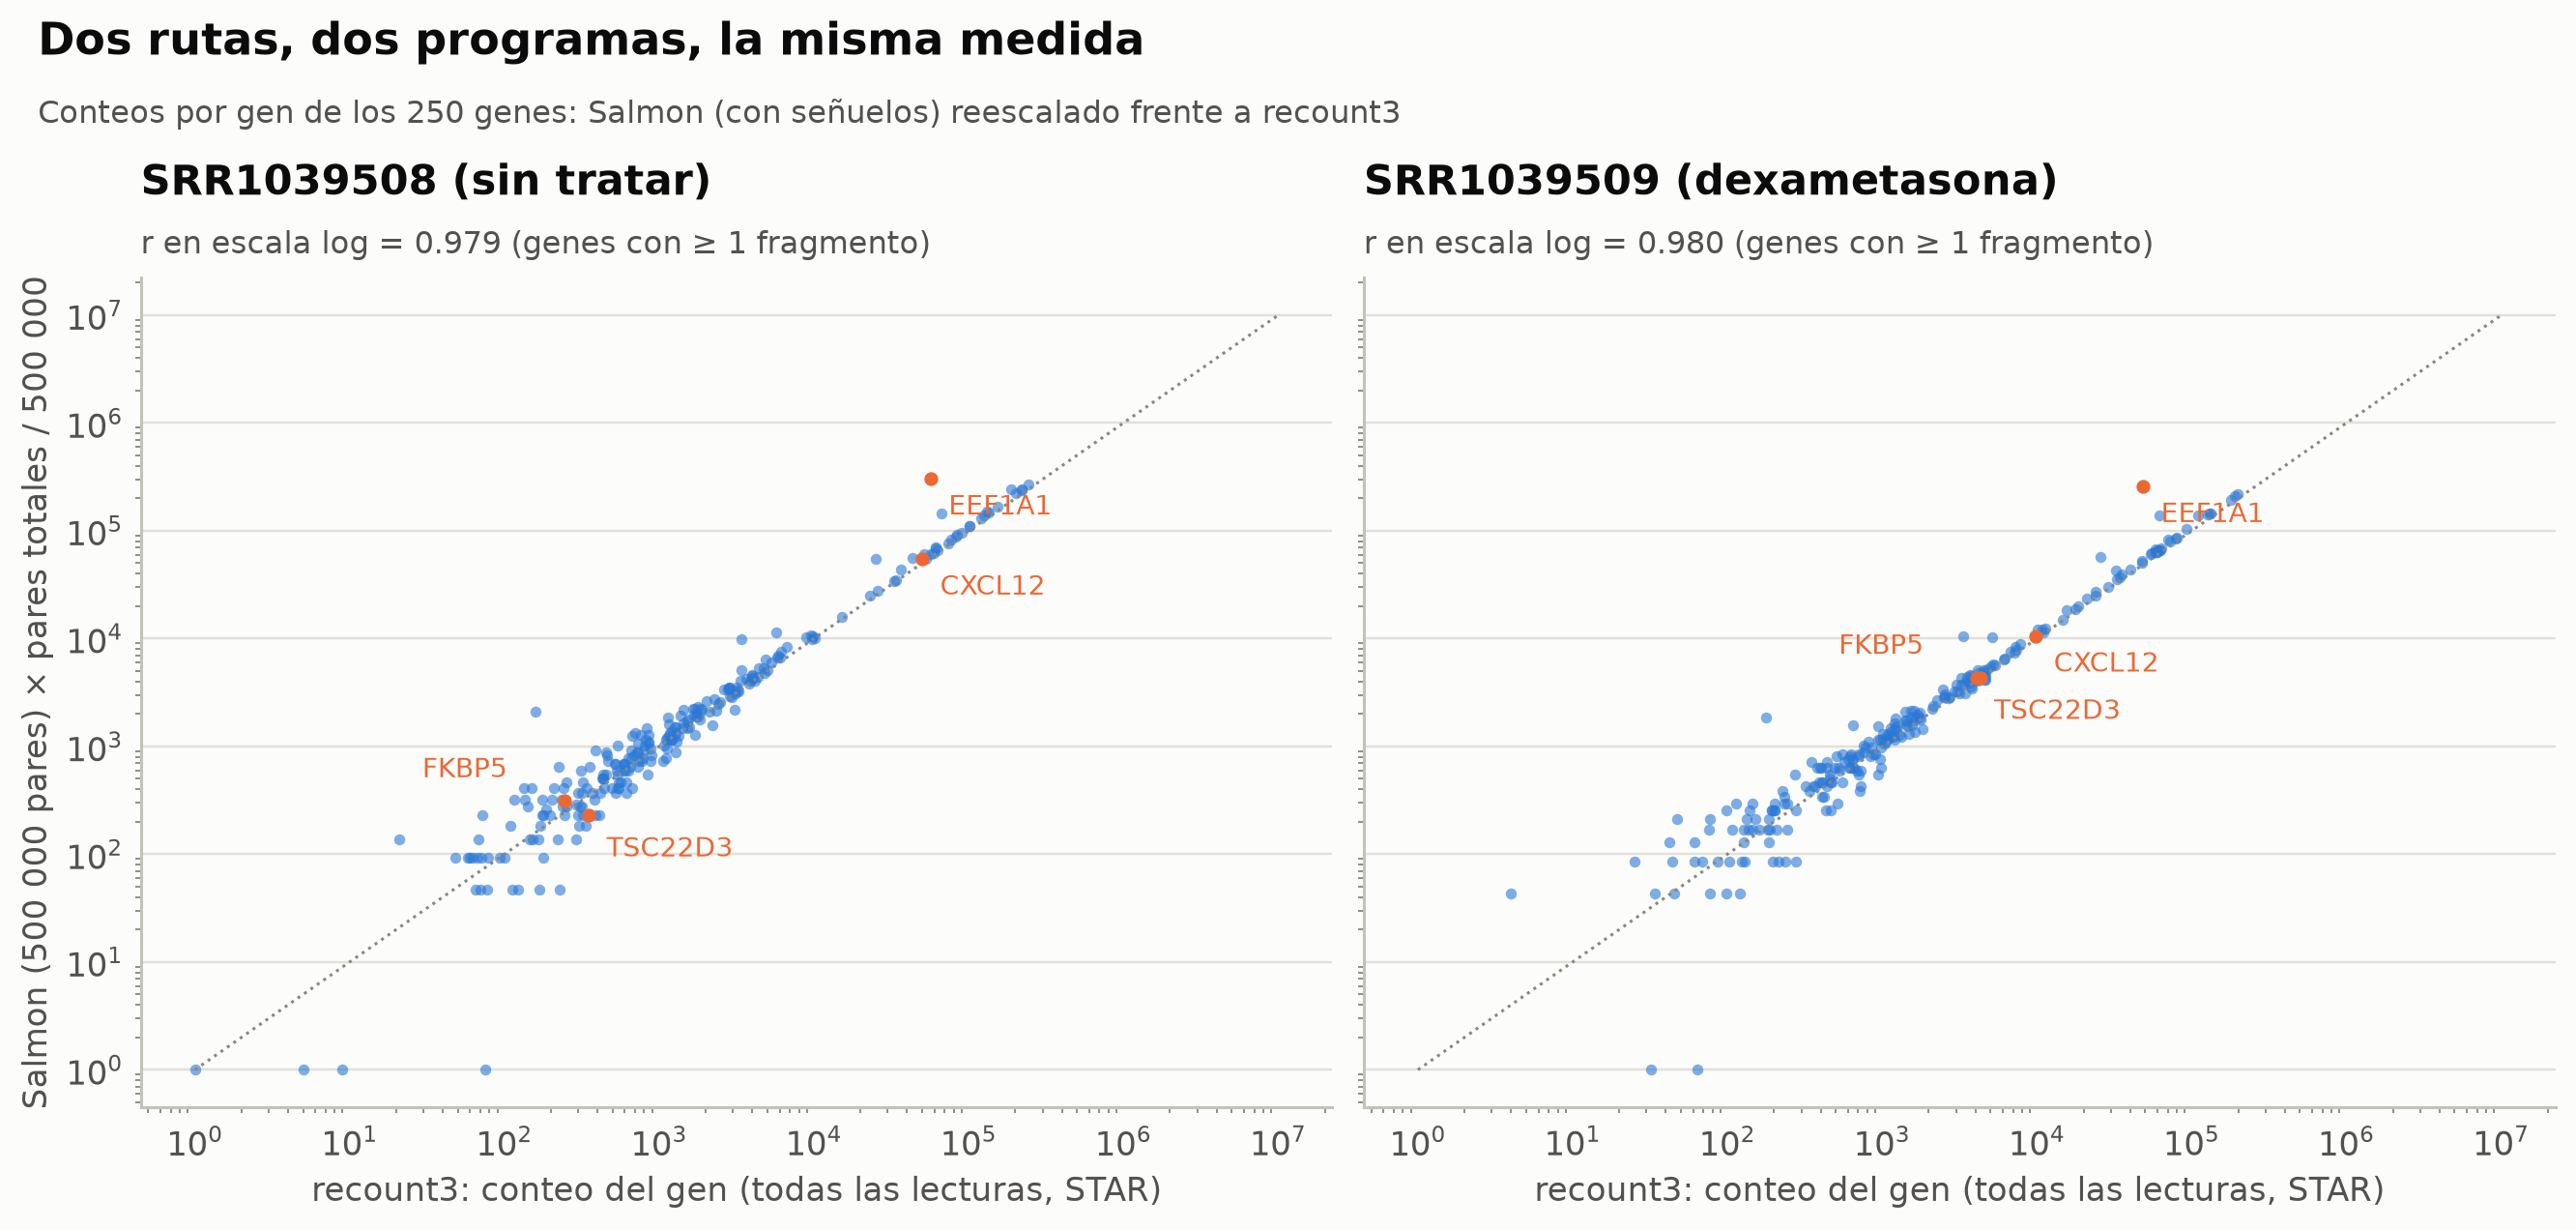

In [43]:
rc = pd.read_csv(course_file("airway_SRP033351_counts.tsv.gz"), sep="\t", index_col=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, run_id in zip(axes, RUNS):
    ours = txi[run_id][0]
    both = pd.DataFrame({"salmon": ours, "recount3": rc[run_id].reindex(ours.index)}).dropna()
    scale = samples.set_index("run").spots[run_id] / 500_000
    lx, ly = np.log10(both.recount3 + 1), np.log10(both.salmon * scale + 1)
    r = np.corrcoef(lx[both.salmon > 0], ly[both.salmon > 0])[0, 1]
    ax.scatter(both.recount3 + 1, both.salmon * scale + 1, s=14, color=ec.BLUE, alpha=0.6, lw=0)
    ax.plot([1, 1e7], [1, 1e7], color=ec.MUTED, ls=":", lw=1)
    for gname, off in [("FKBP5", (-48, 8)), ("TSC22D3", (6, -14)), ("EEF1A1", (6, -12)), ("CXCL12", (6, -12))]:
        gid = gene_sym[gene_sym == gname].index[0]
        if gid in both.index:
            ax.scatter([both.recount3[gid] + 1], [both.salmon[gid] * scale + 1], s=22, color=ec.ORANGE, zorder=4)
            ax.annotate(gname, (both.recount3[gid] + 1, both.salmon[gid] * scale + 1), xytext=off,
                        textcoords="offset points", fontsize=9, color=ec.ORANGE)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("recount3: conteo del gen (todas las lecturas, STAR)")
    ec.title(ax, f"{run_id} ({RUNS[run_id]})", f"r en escala log = {r:.3f} (genes con ≥ 1 fragmento)")
axes[0].set_ylabel(f"Salmon (500 000 pares) × pares totales / 500 000")
ec.fig_title(fig, "Dos rutas, dos programas, la misma medida",
             "Conteos por gen de los 250 genes: Salmon (con señuelos) reescalado frente a recount3")
plt.show()

> 🔎 **Qué observamos.** Los puntos siguen la diagonal a lo largo de cuatro órdenes de magnitud; la dispersión crece
> abajo, donde nuestros 500 000 pares aportan pocas lecturas por gen (el ruido de Poisson de la sección 2) y donde el
> orden de las lecturas en el FASTQ (las primeras de la celda de flujo) no es una muestra perfectamente aleatoria. El
> punto que más se aparta es *EEF1A1* (unas 5 veces más con Salmon): el genoma humano tiene decenas de pseudogenes
> procesados de *EEF1A1*, y una explicación compatible es que en la ruta del genoma muchas de sus lecturas se reparten o
> se descartan como multimapeo, mientras que nuestro índice sólo ofrece el gen verdadero. Salvo esos casos, las dos
> rutas del diagrama de la sección 2 llegan a la misma matriz de conteos.

> ⚠️ **Cuidado: TPM no es una entrada para expresión diferencial.** Los TPM sirven para describir y visualizar, pero no
> deben alimentar un modelo de conteos: al dividir por la longitud y reescalar se pierde la información sobre la
> precisión de cada medida (cien lecturas no son tan ruidosas como diez, aunque den el mismo TPM), y el reescalado a un
> millón hereda el problema de composición. Use los conteos estimados, con las longitudes medias como desplazamientos,
> tal como hace `tximport`.

## 11. Ejercicios

**Ejercicio 1 (EM a mano y en código).** En el ejemplo del libro, suponga que se secuencian 100 fragmentos más que
atraviesan la unión `E1`–`E4` (la clase {T2} pasa de 30 a 130). Antes de ejecutar, prediga qué pasará con
$\hat\tau_2$ y con $\hat\tau_1$. Luego compruébelo con `em_isoforms` y explique por qué T1 también cambia aunque
ninguna de sus clases haya cambiado.

In [44]:
# Su código aquí

In [45]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
cls_mod = [((0,), 120), ((1,), 130), ((2,), 200), ((0, 1), 250), ((0, 2), 150), ((0, 1, 2), 450)]
h_mod = em_isoforms(cls_mod, BOOK_LEFF, iters=500)
tau_mod = tau_from_alpha(h_mod[-1], BOOK_LEFF)
print("τ̂ original  :", np.round(tau_hat, 3))
print("τ̂ modificada:", np.round(tau_mod, 3))
# T2 gana moléculas por dos vías: sus 100 fragmentos exclusivos y, al subir α2, una parte mayor de las clases
# ambiguas {T1,T2} y {T1,T2,T3} en el paso E. Esa parte sale de T1 (y de T3), cuya estimación baja aunque sus
# clases no cambiaron: las fracciones compiten porque suman 1.

τ̂ original  : [0.383 0.44  0.177]
τ̂ modificada: [0.263 0.589 0.148]


**Ejercicio 2 (longitud efectiva real).** Con la distribución de fragmentos que estimó Salmon para SRR1039509
(`aux_info/fld.gz`), calcule con la ecuación 11.1 la longitud efectiva de un transcrito de 300 nt y de uno de 3000
nt. Compare con la columna `EffectiveLength` de `quant.sf` para transcritos de esas longitudes. ¿Coinciden? (Pista:
sin `--gcBias` ni `--seqBias` Salmon usa exactamente esa ecuación, condicionada a fragmentos que caben en el
transcrito.)

In [46]:
# Su código aquí

In [47]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
fld = np.frombuffer(gzip.open(f"{qdir[('dec', 'SRR1039509')]}/aux_info/fld.gz").read(), dtype=np.int32).astype(float)
pf = fld / fld.sum()
def leff_from_fld(L):
    l = np.arange(1, min(L, len(pf) - 1) + 1)
    return float((pf[l] * (L - l + 1)).sum())
qq = quant["SRR1039509"]
for L in (300, 3000):
    near = qq.iloc[(qq.Length - L).abs().argsort()[:1]]
    print(f"ℓ = {L}: ecuación 11.1 → {leff_from_fld(L):.1f}   |   Salmon, transcrito de {near.Length.iloc[0]} nt → "
          f"{near.EffectiveLength.iloc[0]:.1f} (nuestra ecuación para esa longitud: {leff_from_fld(int(near.Length.iloc[0])):.1f})")
# Para transcritos largos coinciden casi exactamente. Para los cortos, Salmon renormaliza P_F a los fragmentos
# que caben (l ≤ ℓ), lo que da una ℓ̃ algo mayor que la suma sin renormalizar.

ℓ = 300: ecuación 11.1 → 142.1   |   Salmon, transcrito de 300 nt → 147.3 (nuestra ecuación para esa longitud: 142.1)
ℓ = 3000: ecuación 11.1 → 2839.7   |   Salmon, transcrito de 3000 nt → 2837.4 (nuestra ecuación para esa longitud: 2839.7)


**Ejercicio 3 (TPM desde NumReads).** Demuestre algebraicamente que la suma de los TPM de una muestra es $10^6$ y
que $\mathrm{TPM}_t/10^6 = \hat\tau_t$ cuando $c_t = N\hat\alpha_t$. Después, con los datos de SRR1039508, calcule el
TPM **a nivel de gen** de dos maneras: (a) sumando los TPM de sus isoformas; (b) aplicando la ecuación 11.7 a los
conteos por gen con la longitud media $\bar\ell_{gi}$ de `tximport`. ¿Coinciden? ¿Por qué?

In [48]:
# Su código aquí

In [49]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
# Álgebra: Σ_t TPM_t = 10⁶ Σ_t (c_t/ℓ̃_t) / Σ_u (c_u/ℓ̃_u) = 10⁶. Con c_t = N α_t, la N se cancela y queda
# 10⁶ (α_t/ℓ̃_t)/Σ_u(α_u/ℓ̃_u) = 10⁶ τ_t por la ecuación 11.2.
counts08, abund08, len08 = txi["SRR1039508"]
tpm_b = pd.Series(tpm(counts08.values, len08.values), index=counts08.index)
d = pd.DataFrame({"(a) suma de TPM": abund08, "(b) conteo/ℓ̄": tpm_b})
print(d.head(6).round(2).to_string())
print("máxima diferencia:", float((d.iloc[:, 0] - d.iloc[:, 1]).abs().max()))
# Coinciden: ℓ̄ se definió precisamente como la media de ℓ̃ ponderada por TPM, de modo que c_g/ℓ̄_g = Σ_t c_t/ℓ̃_t.

                    (a) suma de TPM  (b) conteo/ℓ̄
gene_id                                           
ENSG00000004799.7              0.00           0.00
ENSG00000010219.13           311.14         311.14
ENSG00000011465.16         76776.15       76776.15
ENSG00000013297.10          1584.23        1584.23
ENSG00000014824.13           150.87         150.87
ENSG00000021776.10            79.53          79.53
máxima diferencia: 0.12514275197963798


**Ejercicio 4 (señuelos y falsos positivos).** Uno de nuestros genes de respuesta a dexametasona, *CRISPLD2*, recibe
lecturas intrusas sin señuelos. Use la tabla `origins` para averiguar de qué genes vienen y calcule, para SRR1039508 y
SRR1039509, el log2 del cambio de *CRISPLD2* con el índice reducido, con señuelos y con el transcriptoma completo.
¿El índice sin señuelos exagera o atenúa la inducción? ¿Qué pasaría en un gen cuyo intruso sí cambia con el
tratamiento?

In [50]:
# Su código aquí

In [51]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
print(origins[origins.assigned_gene_reduced == "CRISPLD2"].groupby(["run", "true_gene_full"]).fragments.sum()
      .round(1).sort_values(ascending=False).head(6).to_string())
for col in ["reducido", "con_señuelos", "completo"]:
    a, b = cmp["SRR1039508"].loc["CRISPLD2", col], cmp["SRR1039509"].loc["CRISPLD2", col]
    print(f"{col:13s}: {a:7.1f} → {b:7.1f}   log2 FC = {np.log2((b + 1) / (a + 1)):.2f}")
# Las lecturas intrusas (de IFITM2/IFITM3, que no cambian mucho con dexametasona) se suman por igual a ambas
# muestras y ATENÚAN el cambio: el gen parece menos inducido. Si el intruso cambiara con el tratamiento, su cambio
# se transferiría a CRISPLD2 y podría crear un falso positivo.

run         true_gene_full
SRR1039508  IFITM3            25.3
SRR1039509  IFITM3            18.5
            IFITM2            12.0
            IFITM1             4.5
SRR1039508  IFITM2             3.3
            DEGS1              2.0
reducido     :    87.3 →   191.7   log2 FC = 1.13
con_señuelos :    19.0 →   134.0   log2 FC = 2.75
completo     :    17.0 →   132.2   log2 FC = 2.88


**Ejercicio 5 (para pensar).** Un colega cuantificó 12 muestras con Salmon y le envía una tabla de TPM «lista para
DESeq2». Escriba, en tres frases, qué le pediría en su lugar y por qué. Pista: hay dos razones en el recuadro de
cuidado de la sección 10 y una tercera en la sección 9 (el universo del índice).

In [52]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
print("""1) Los archivos quant.sf (o NumReads + EffectiveLength) de cada muestra, para agregarlos con tximport:
   conteos estimados por gen y longitudes medias como desplazamiento.
2) Los TPM pierden la precisión de cada medida (10 lecturas y 10 000 pueden dar el mismo TPM) y heredan el problema
   de composición del reescalado a un millón; el modelo binomial negativo necesita conteos.
3) Confirmar que todas las muestras se cuantificaron con el MISMO índice (misma versión de anotación y señuelos):
   un TPM sólo tiene sentido respecto al universo de transcritos del índice.""")

1) Los archivos quant.sf (o NumReads + EffectiveLength) de cada muestra, para agregarlos con tximport:
   conteos estimados por gen y longitudes medias como desplazamiento.
2) Los TPM pierden la precisión de cada medida (10 lecturas y 10 000 pueden dar el mismo TPM) y heredan el problema
   de composición del reescalado a un millón; el modelo binomial negativo necesita conteos.
3) Confirmar que todas las muestras se cuantificaron con el MISMO índice (misma versión de anotación y señuelos):
   un TPM sólo tiene sentido respecto al universo de transcritos del índice.


## 📌 Resumen

* **El diseño manda.** Réplicas biológicas (≥ 3) antes que profundidad: el error del log fold change tiene un piso
  biológico $\sqrt{2\phi/n}/\ln 2$ que ninguna profundidad baja. Lotes balanceados; en *airway*, diseño pareado por
  donante.
* **Empalmes.** STAR busca el prefijo mapeable más largo con un arreglo de sufijos; el hueco entre semillas es el
  intrón, que prefiere bordes `GT…AG`.
* **Modelo generativo.** Un fragmento viene de $t$ con probabilidad $\alpha_t \propto \tau_t\tilde\ell_t$, con
  $\tilde\ell_t = \sum_l P_F(l)(\ell_t - l + 1) \approx \ell_t - \mu_F + 1$. La verosimilitud sólo depende de las
  **clases de equivalencia** y sus conteos $n_C$.
* **EM.** Paso E: repartir cada clase en proporción a $\alpha_t/\tilde\ell_t$ (¡no a $\alpha_t$!). Paso M:
  $\alpha_t = \frac1N\sum_{C\ni t}\hat n_{Ct}$. La verosimilitud nunca baja (Jensen) y, por ser cóncava, el máximo es
  global. En el ejemplo del libro: $\hat\alpha = (0{,}426;\ 0{,}301;\ 0{,}273)$, $\hat\tau = (0{,}383;\ 0{,}440;\ 0{,}177)$.
* **Pseudoalineamiento** (kallisto): intersección de los conjuntos de transcritos de los $k$-mers. **Salmon**: mapeo
  selectivo, modelos de sesgo que corrigen $\tilde\ell_t$, VBEM y **señuelos**. Con un índice parcial sin señuelos,
  genes como *ALDH6A1* o *SLC29A4* reciben 10–100 veces más lecturas de las suyas; los parálogos (*ACTB*/*ACTG1*,
  *UBC*/*UBB*) se contaminan un ~20 %.
* **Unidades.** NumReads = conteos esperados; TPM = $10^6\hat\tau_t$ (suma $10^6$, relativo al universo del índice);
  RPKM suma $10^9/\bar\ell$ y no es comparable entre muestras.
* **Al gen con `tximport`:** sumar conteos estimados y usar la longitud media ponderada $\bar\ell_{gi}$ como
  desplazamiento. Nunca TPM como entrada de expresión diferencial.

## 📚 Lecturas recomendadas

* Conesa, A. *et al.* (2016). A survey of best practices for RNA-seq data analysis. *Genome Biology* 17:13.
  https://doi.org/10.1186/s13059-016-0881-8
* Himes, B. E. *et al.* (2014). RNA-Seq transcriptome profiling identifies *CRISPLD2* as a glucocorticoid responsive
  gene that modulates cytokine function in airway smooth muscle cells. *PLoS ONE* 9(6):e99625.
  https://doi.org/10.1371/journal.pone.0099625
* Dobin, A. *et al.* (2013). STAR: ultrafast universal RNA-seq aligner. *Bioinformatics* 29(1):15–21.
  https://doi.org/10.1093/bioinformatics/bts635
* Kim, D. *et al.* (2019). Graph-based genome alignment and genotyping with HISAT2 and HISAT-genotype. *Nature
  Biotechnology* 37:907–915. https://doi.org/10.1038/s41587-019-0201-4
* Dempster, A. P., Laird, N. M. y Rubin, D. B. (1977). Maximum likelihood from incomplete data via the EM algorithm.
  *Journal of the Royal Statistical Society B* 39(1):1–38. https://doi.org/10.1111/j.2517-6161.1977.tb01600.x
* Li, B. y Dewey, C. N. (2011). RSEM: accurate transcript quantification from RNA-Seq data with or without a reference
  genome. *BMC Bioinformatics* 12:323. https://doi.org/10.1186/1471-2105-12-323
* Mortazavi, A. *et al.* (2008). Mapping and quantifying mammalian transcriptomes by RNA-Seq. *Nature Methods*
  5:621–628. https://doi.org/10.1038/nmeth.1226
* Bray, N. L. *et al.* (2016). Near-optimal probabilistic RNA-seq quantification. *Nature Biotechnology* 34:525–527.
  https://doi.org/10.1038/nbt.3519
* Patro, R. *et al.* (2017). Salmon provides fast and bias-aware quantification of transcript expression. *Nature
  Methods* 14:417–419. https://doi.org/10.1038/nmeth.4197
* Srivastava, A. *et al.* (2020). Alignment and mapping methodology influence transcript abundance estimation.
  *Genome Biology* 21:239. https://doi.org/10.1186/s13059-020-02151-8
* Wagner, G. P., Kin, K. y Lynch, V. J. (2012). Measurement of mRNA abundance using RNA-seq data: RPKM measure is
  inconsistent among samples. *Theory in Biosciences* 131:281–285. https://doi.org/10.1007/s12064-012-0162-3
* Soneson, C., Love, M. I. y Robinson, M. D. (2015). Differential analyses for RNA-seq: transcript-level estimates
  improve gene-level inferences. *F1000Research* 4:1521. https://doi.org/10.12688/f1000research.7563.1
* Wilks, C. *et al.* (2021). recount3: summaries and queries for large-scale RNA-seq expression and splicing. *Genome
  Biology* 22:323. https://doi.org/10.1186/s13059-021-02533-6

**Siguiente lección:** 11.2 · Normalización y la binomial negativa: por qué los conteos no son comparables tal cual y
por qué la varianza entre réplicas no es la de Poisson.

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)